In [0]:
pip install geopandas

[Monitor] stop monitoring


Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 74.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 74.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 25.1 MB/s eta 0:00:00
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
from datetime import timedelta
import datetime as dt
import calendar

# libraries for forecasting
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # Import matplotlib colors for Tableau colors
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.lines import Line2D

pd.set_option("display.max_rows", None)


In [0]:
# create dataset with Gaza in all three Actor + Action columns
# querying all three columns to get Gaza data
df = pd.read_csv("GazaFull.csv")
df.info()

/root/.ipykernel/10482/command-2714981194622941-1575545880:3: DtypeWarning: Columns (11,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("GazaFull.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234698 entries, 0 to 234697
Data columns (total 58 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   GLOBALEVENTID          234698 non-null  int64  
 1   SQLDATE                234698 non-null  object 
 2   Actor1Code             224411 non-null  object 
 3   Actor1Name             224411 non-null  object 
 4   Actor1CountryCode      177495 non-null  object 
 5   Actor1KnownGroupCode   4747 non-null    object 
 6   Actor1EthnicCode       212 non-null     object 
 7   Actor1Religion1Code    3044 non-null    object 
 8   Actor1Religion2Code    440 non-null     object 
 9   Actor1Type1Code        79992 non-null   object 
 10  Actor1Type2Code        6854 non-null    object 
 11  Actor1Type3Code        203 non-null     object 
 12  Actor2Code             203671 non-null  object 
 13  Actor2Name             203671 non-null  object 
 14  Actor2CountryCode      157945 non-nu

In [0]:
# create dataset with Gaza in all three columns

Gaza_values = [ # updated with Actor1Geo and Actor2Geo values - complete values referring to Gaza in all 3 columns
    "Gaza, Israel (general), Israel",
    "Gaza City, Israel (general), Israel",
    "Gaza Strip",
    "Unrwa, Gaza Strip (general), Gaza Strip",
    "Rafah, Gaza Strip (general), Gaza Strip",
    "Khan Yunis, Gaza Strip (general), Gaza Strip",
    "Jabaliya, Gaza Strip (general), Gaza Strip",
    "Jabalya, Gaza Strip (general), Gaza Strip",
    "Maghazi, Gaza Strip (general), Gaza Strip",
    "Beit Lahiya, Gaza Strip (general), Gaza Strip",
    "Palestinian Central Bureau Of Statistics, Gaza Strip (general), Gaza Strip",
    "Nuseirat, Gaza Strip (general), Gaza Strip",
    "Al-Amal, Gaza Strip (general), Gaza Strip",
    "Gaza Municipality, Gaza Strip (general), Gaza Strip",
    "Katif, Gaza Strip (general), Gaza Strip",
    "Bureij, Gaza Strip (general), Gaza Strip",
    "Bani Suheila, Gaza Strip (general), Gaza Strip",
    "Nusayrat, Gaza Strip (general), Gaza Strip",
    "Al-Azhar University, Gaza Strip (general), Gaza Strip",
    "Jabalia, Gaza Strip (general), Gaza Strip",
    "Netzarim, Gaza Strip (general), Gaza Strip",
    "Al-Bureij, Gaza Strip (general), Gaza Strip",
    "Deir El-Balah, Gaza Strip (general), Gaza Strip",
    "Palestinian Legislative Council, Gaza Strip (general), Gaza Strip",
    "Ministry Of Education, Gaza Strip (general), Gaza Strip",
    "Monetary Authority, Gaza Strip (general), Gaza Strip",
    "Preventive Security, Gaza Strip (general), Gaza Strip",
    "Azzah, Gaza Strip (general), Gaza Strip",
    "Beit Hanun, Gaza Strip (general), Gaza Strip",
    "Al-Mawasi, Gaza Strip (general), Gaza Strip,"
    "Al Amal, Gaza Strip (general), Gaza Strip"
]
# New df with Gaza rows only

# create a mask
mask = df[['ActionGeo_FullName', 'Actor1Geo_FullName', 'Actor2Geo_FullName']].isin(Gaza_values).any(axis=1)
Gaza3 = df[mask]
Gaza3.info()

Gaza3.to_csv("Gaza3.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 87169 entries, 3 to 234697
Data columns (total 58 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GLOBALEVENTID          87169 non-null  int64  
 1   SQLDATE                87169 non-null  object 
 2   Actor1Code             84799 non-null  object 
 3   Actor1Name             84799 non-null  object 
 4   Actor1CountryCode      69963 non-null  object 
 5   Actor1KnownGroupCode   2144 non-null   object 
 6   Actor1EthnicCode       53 non-null     object 
 7   Actor1Religion1Code    878 non-null    object 
 8   Actor1Religion2Code    89 non-null     object 
 9   Actor1Type1Code        29252 non-null  object 
 10  Actor1Type2Code        3142 non-null   object 
 11  Actor1Type3Code        103 non-null    object 
 12  Actor2Code             80643 non-null  object 
 13  Actor2Name             80643 non-null  object 
 14  Actor2CountryCode      65595 non-null  object 
 15  A

In [0]:
df3 = pd.read_csv("Gaza3.csv")
#df1 = pd.read_csv("GazaFull.csv")
#df2 = pd.read_csv("Gaza_ActionGeoOnly.csv")

/root/.ipykernel/1094/command-3551253917898142-62817325:1: DtypeWarning: Columns (6,16,21,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("Gaza3.csv")


In [0]:
# check RBL

rebel = df3[df3['Actor1Type1Code'] == 'GOV']
rebel.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8287 entries, 93 to 87168
Data columns (total 58 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GLOBALEVENTID          8287 non-null   int64  
 1   SQLDATE                8287 non-null   object 
 2   Actor1Code             8287 non-null   object 
 3   Actor1Name             8287 non-null   object 
 4   Actor1CountryCode      4328 non-null   object 
 5   Actor1KnownGroupCode   0 non-null      object 
 6   Actor1EthnicCode       4 non-null      object 
 7   Actor1Religion1Code    1 non-null      object 
 8   Actor1Religion2Code    0 non-null      object 
 9   Actor1Type1Code        8287 non-null   object 
 10  Actor1Type2Code        1624 non-null   object 
 11  Actor1Type3Code        42 non-null     object 
 12  Actor2Code             7892 non-null   object 
 13  Actor2Name             7892 non-null   object 
 14  Actor2CountryCode      6800 non-null   object 
 15  Ac

In [0]:
rebel.head(100)

,GLOBALEVENTID,SQLDATE,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
61,1124528558,2023-09-03,PSEREBCOP,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,COP,NaN,PSE,WEST BANK,PSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,40,40,4,1,1.0,1,1,1,-3.428571,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.3333,-797156,1,West Bank,WE,WE,NaN,31.666667,35.250000,WE,1,West Bank,WE,WE,NaN,31.666667,35.250000,WE,20230903084500,https://www.timesofisrael.com/nasrallah-meets-...
63,1124542451,2023-09-03,PSEREBCOP,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,COP,NaN,ISR,ISRAEL,ISR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,40,40,4,1,1.0,2,1,2,-7.121662,1,West Bank,WE,WE,NaN,31.666667,35.2500,WE,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.333300,-797156,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.333300,-797156,20230903111500,https://themedialine.org/headlines/nasrallah-m...
128,1124898922,2023-09-05,PSEREB,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,NaN,NaN,ISR,ISRAEL,ISR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,51,51,5,1,3.4,1,1,1,-3.683386,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.3333,-797156,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.333300,-797156,1,West Bank,WE,WE,NaN,31.666667,35.250000,WE,20230905120000,http://www.ruthfullyyours.com/2023/09/05/how-t...
164,1124998669,2023-09-05,PSEREB,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,NaN,NaN,ISR,ISRAEL,ISR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,61,61,6,2,6.4,3,1,3,-8.267717,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.3333,-797156,1,West Bank,WE,WE,NaN,31.666667,35.250000,WE,1,West Bank,WE,WE,NaN,31.666667,35.250000,WE,20230905213000,https://www.timesofisrael.com/gazan-businesses...
165,1124998671,2023-09-05,PSEREB,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,NaN,NaN,PSE,WEST BANK,PSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,61,61,6,2,6.4,2,1,2,-8.267717,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.3333,-797156,1,West Bank,WE,WE,NaN,31.666667,35.250000,WE,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.333300,-797156,20230905213000,https://www.timesofisrael.com/gazan-businesses...
186,1125099631,2023-09-06,PSEREB,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,NaN,NaN,ISR,ISRAEL,ISR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,51,51,5,1,3.4,1,1,1,-3.503427,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.3333,-797156,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.333300,-797156,1,West Bank,WE,WE,NaN,31.666667,35.250000,WE,20230906091500,https://www.jewishpress.com/indepth/opinions/h...
202,1125190630,2023-09-06,PSEREB,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,NaN,NaN,ISR,ISRAEL,ISR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,130,130,13,3,-4.4,1,1,1,-8.373786,1,Iran,IR,IR,NaN,32.000000,53.0000,IR,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.333300,-797156,4,"Nablus, West Bank (general), West Bank",WE,WE00,32684,32.219900,35.263600,-795575,20230906170000,https://english.ahram.org.eg/News/507863.aspx
203,1125190631,2023-09-06,PSEREB,HAMAS,PSE,NaN,NaN,NaN,NaN,REB,NaN,NaN,PSE,GAZA,PSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,130,130,13,3,-4.4,1,1,1,-8.373786,1,Iran,IR,IR,NaN,32.000000,53.0000,IR,4,"Gaza, Israel (general), Israel",IS,IS00,18315,31.416700,34.333300,-797156,4,"Nablus,

In [0]:
rebel.Actor1Name.unique()

array(['MINISTRY', 'ISRAEL', 'MAHMOUD ABBAS', 'MINIST', 'REGIME',
       'PALESTINE', 'UNITED KINGDOM', 'PALESTINIAN', 'FOREIGN SECRETARY',
       'CUSTOMS OFFICIAL', 'GOVERNMENT', 'THE US', 'ADMINISTRATION',
       'PRIME MINISTER', 'ISRAELI', 'WEST BANK', 'TURKEY',
       'MINIST OF HEALTH', 'ENVOY', 'JOE BIDEN', 'PRESIDENT', 'JORDAN',
       'ABDULLAH', 'MINIST OF NATIONAL SECURITY', 'EHUD BARAK',
       'SECRETARY OF STATE', 'MINIST OF FOREIGN AFFAIRS',
       'THE WHITE HOUSE', 'CABINET', 'FLORIDA', 'UNDERSECRETARY',
       'POLITBURO', 'FRANCE', 'PAKISTANI', 'FINANCE MINIST',
       'VIVIAN BALAKRISHNAN', 'GAZA', 'CHIEF OF STAFF', 'UKRAINIAN',
       'MALAYSIA', 'MALAYSIAN', 'OVAL OFFICE', 'FOREIGN OFFICE',
       'GOVERNOR', 'HEALTH MINIST', 'FOREIGN MINIST', 'KING', 'CHINA',
       'MONARCH', 'EXTERNAL AFFAIRS MINIST', 'PRINCE', 'RUSSIAN',
       'UNITED STATES', 'AMBASSADOR', 'INTERIOR MINIST',
       'DEFENSE SECRETARY', 'EMBASSY', 'DIPLOMAT', 'RUSSIA',
       'RICHARD GORDON

# Event Trend Forecast Visualisations
### 1(a) Actual Event Trend: Sept-Dec'23 + Forecast for Jan '24

/root/.ipykernel/1162/command-1848653201928489-261014245:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found

Event Code 42:
ADF Statistic: -2.673672
p-value: 0.078706
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.89972D+00    |proj g|=  2.83622D-01

At iterate    5    f=  3.81794D+00    |proj g|=  4.16985D-03

At iterate   10    f=  3.78968D+00    |proj g|=  8.92368D-02

At iterate   15    f=  3.73061D+00    |proj g|=  2.85582D-02

At iterate   20    f=  3.72157D+00    |proj g|=  1.84902D-02

At iterate   25    f=  3.71570D+00    |proj g|=  5.30974D-04

At iterate   30    f=  3.71395D+00    |proj g|=  1.85532D-02

At iterate   35    f=  3.71250D+00    |proj g|=  3.09187D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at fina

/root/.ipykernel/1162/command-1848653201928489-261014245:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters fo

Event Code 43:
ADF Statistic: -2.936530
p-value: 0.041262
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.95910D+00    |proj g|=  2.89928D-01

At iterate    5    f=  3.87541D+00    |proj g|=  4.73802D-03

At iterate   10    f=  3.87196D+00    |proj g|=  1.88082D-02

At iterate   15    f=  3.82990D+00    |proj g|=  6.95989D-03

At iterate   20    f=  3.81699D+00    |proj g|=  1.07813D-02

At iterate   25    f=  3.80152D+00    |proj g|=  8.22735D-03

At iterate   30    f=  3.79744D+00    |proj g|=  9.98812D-03

At iterate   35    f=  3.78479D+00    |proj g|=  2.06304D-02

At iterate   40    f=  3.78339D+00    |proj g|=  4.90117D-02

At iterate   45    f=  3.77322D+00    |proj g|=  3.44751D-03

At iterate   50    f=  3.77319D+00    |proj g|=  5.81539D-06

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928489-261014245:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, 

...

Event Code 71:
ADF Statistic: -2.245659
p-value: 0.190093
	1%: -3.639
	5%: -2.951
	10%: -2.614
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.39158D+00    |proj g|=  1.06783D-01

At iterate    5    f=  2.37059D+00    |proj g|=  3.57389D-02

At iterate   10    f=  2.36445D+00    |proj g|=  5.25106D-04

At iterate   15    f=  2.36424D+00    |proj g|=  6.46178D-03

At iterate   20    f=  2.36388D+00    |proj g|=  1.16061D-03

At iterate   25    f=  2.36378D+00    |proj g|=  3.53618D-04

At iterate   30    f=  2.36374D+00    |proj g|=  1.36104D-04

At iterate   35    f=  2.36373D+00    |proj g|=  4.26115D-04

At iterate   40    f=  2.36373D+00    |proj g|=  2.56197D-04

At iterate   45    f=  2.36372D+00    |proj g|=  4.90435D-05

At iterate   50    f=  2.36372D+00    |proj g|=  4.11070D-05

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928489-261014245:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, 

Event Code 190:
ADF Statistic: -2.365347
p-value: 0.151757
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.35375D+00    |proj g|=  6.65824D-02

At iterate    5    f=  4.33829D+00    |proj g|=  4.87849D-03

At iterate   10    f=  4.33646D+00    |proj g|=  2.32005D-03

At iterate   15    f=  4.33637D+00    |proj g|=  2.34025D-03

At iterate   20    f=  4.33105D+00    |proj g|=  3.50909D-02

At iterate   25    f=  4.32602D+00    |proj g|=  4.58740D-03

At iterate   30    f=  4.32500D+00    |proj g|=  1.47653D-03

At iterate   35    f=  4.32485D+00    |proj g|=  5.46064D-04

At iterate   40    f=  4.32482D+00    |proj g|=  1.48332D-04

At iterate   45    f=  4.32481D+00    |proj g|=  1.17179D-04

At iterate   50    f=  4.32481D+00    |proj g|=  9.90764D-05

           * * *

Tit   = total number of iterations
T

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928489-261014245:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, 

Event Code 193:
ADF Statistic: -2.968582
p-value: 0.037934
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.43615D+00    |proj g|=  2.17420D-01

At iterate    5    f=  3.36906D+00    |proj g|=  4.04954D-03

At iterate   10    f=  3.35896D+00    |proj g|=  1.65464D-02

At iterate   15    f=  3.34910D+00    |proj g|=  1.30491D-03

At iterate   20    f=  3.34631D+00    |proj g|=  2.08972D-02

At iterate   25    f=  3.33136D+00    |proj g|=  3.33740D-02

At iterate   30    f=  3.32881D+00    |proj g|=  2.95801D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projecte

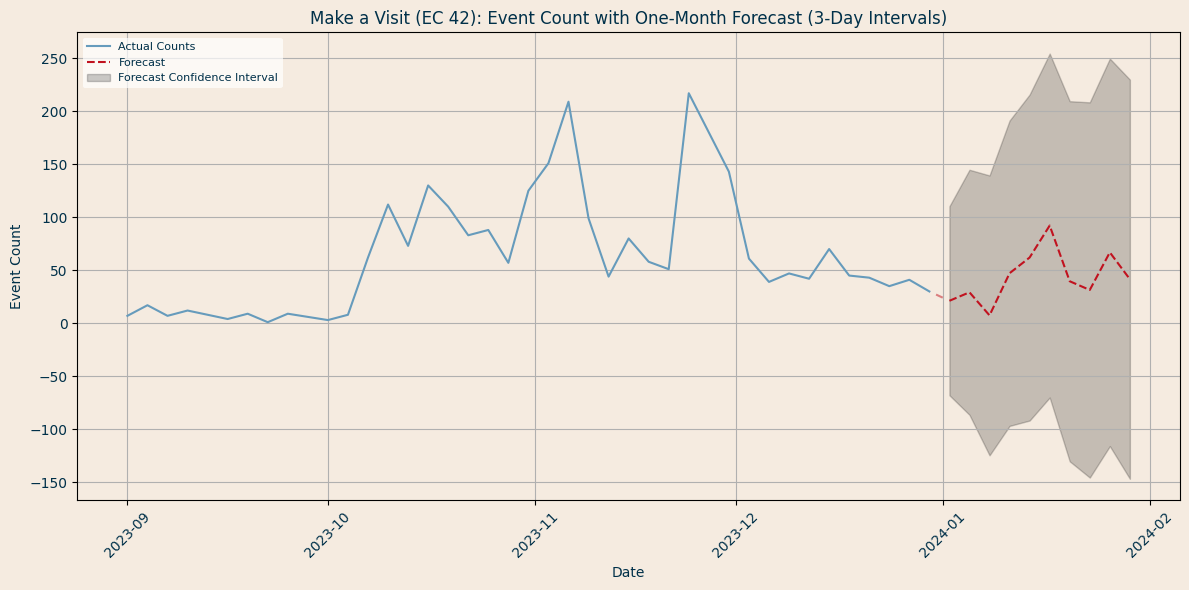

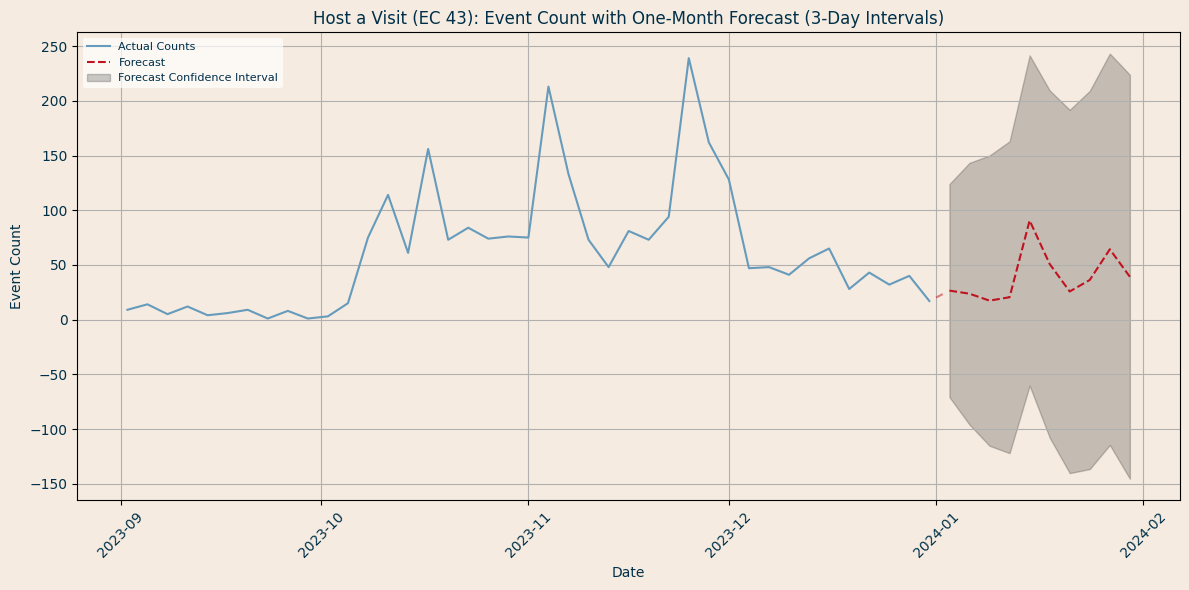

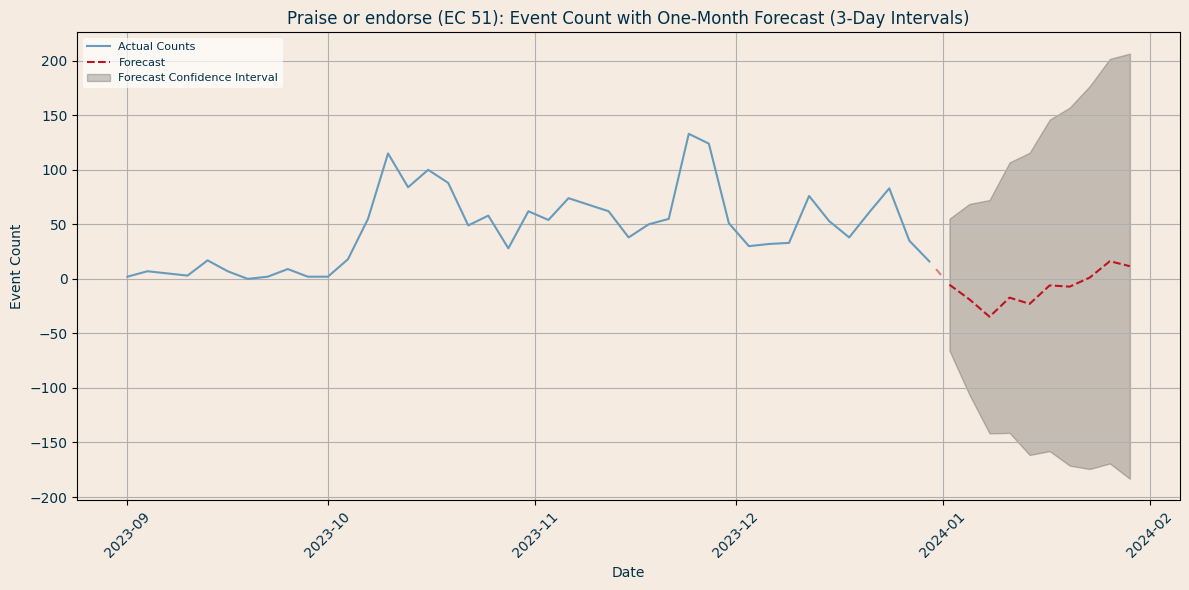

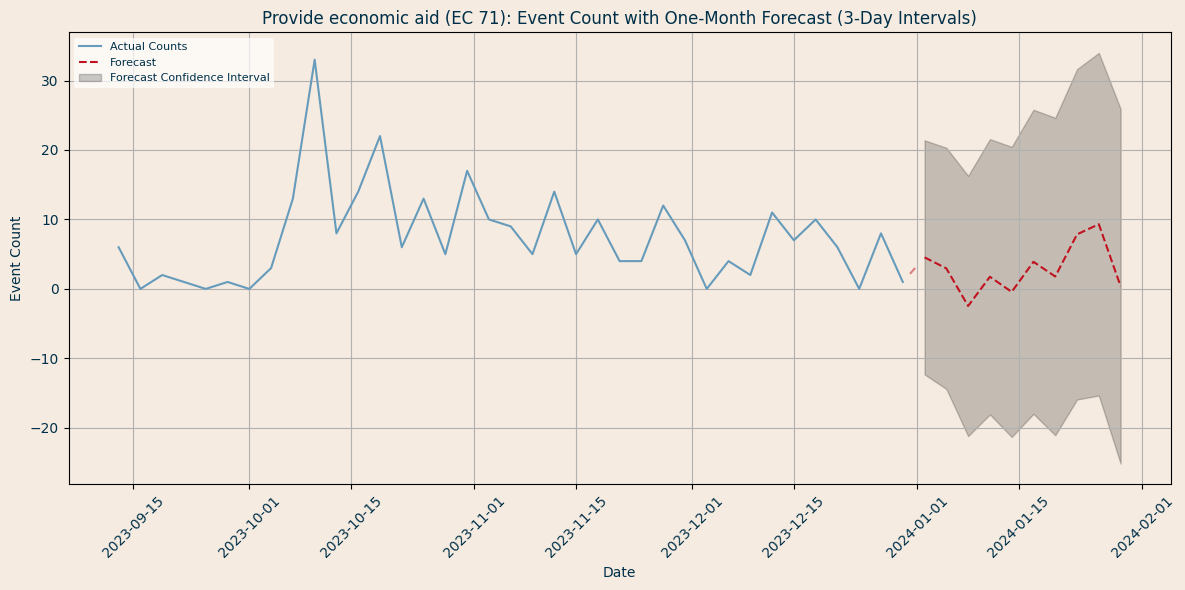

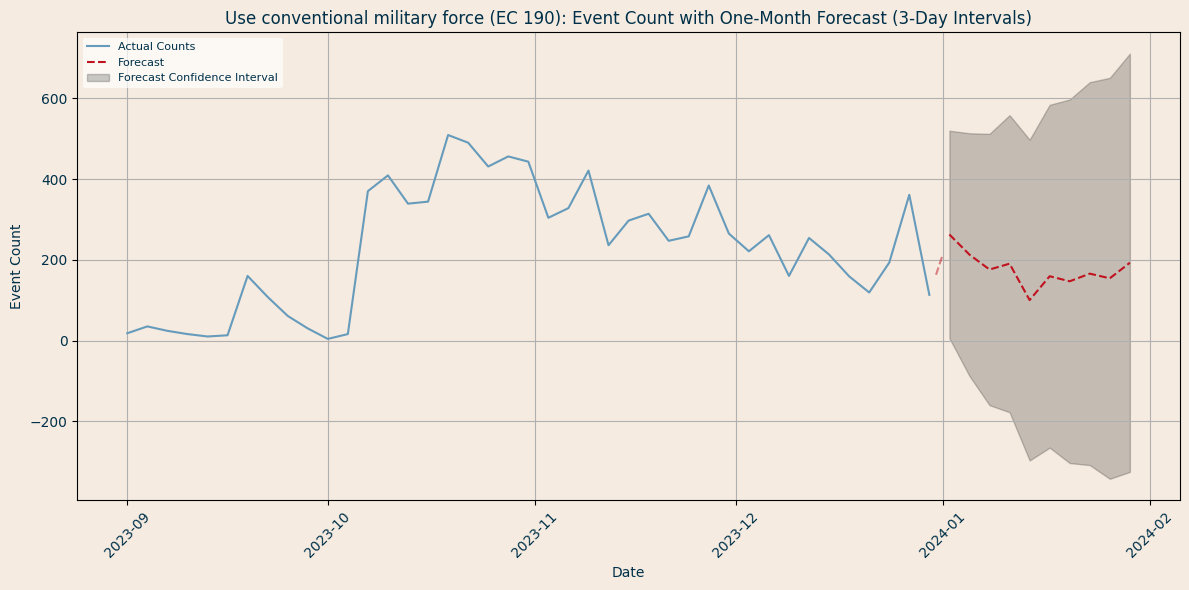

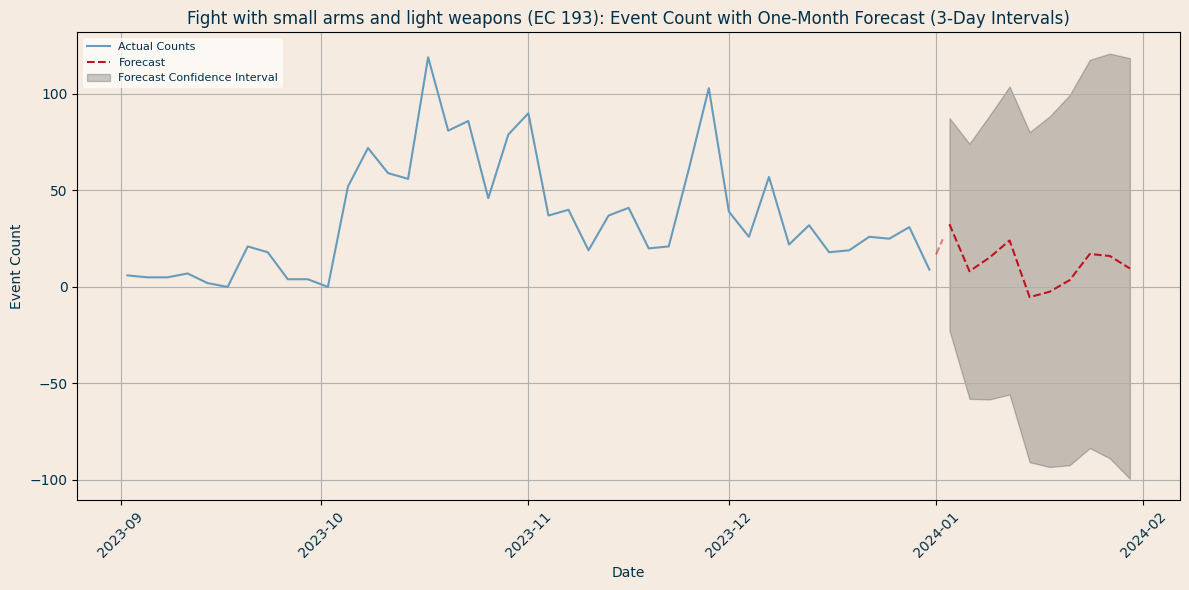

In [0]:
# Function to check stationarity
# Uses the Augmented Dickey-Fuller (ADF) test to check if a time series is stationary. 
# A time series is said to be stationary if its statistical properties such as mean, variance, and autocorrelation are constant over time. Specifically, stationarity means:
# # Mean: The average value of the series does not change over time.
# # Variance: The variability of the series is constant over time.
# # Autocorrelation: The relationship between values in the series is consistent over time.

# What is ADF statistic: A negative number; the more negative it is, the stronger the rejection of the null hypothesis (i.e., the more likely the series is stationary).
# p-value: A measure of the probability that the observed data could occur under the null hypothesis. A low p-value (typically ≤ 0.05) indicates strong evidence against the null hypothesis.

#ARIMA (AutoRegressive Integrated Moving Average) and SARIMA (Seasonal ARIMA), assume that the underlying time series is stationary. Non-stationary data can lead to unreliable and biased model parameters.

# Function to check stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

# Event codes, date range. event desc
event_codes = [42, 43, 51, 71, 190, 193]
start_date = '2023-09-01'
end_date = '2023-12-31'

# event codes dictionary
event_descriptions = {
    42: "Make a Visit",
    43: "Host a Visit",
    51: "Praise or endorse",
    71: "Provide economic aid",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons"
}

# Loop to generate plots
for event_code in event_codes:
    # Filter based on event code and date range
    filtered_data = df3[(df3['EventCode'] == event_code) &
                        (df3['SQLDATE'] >= start_date) &
                        (df3['SQLDATE'] <= end_date)]

    filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])

    # Aggregate data by date
    daily_counts = filtered_data.groupby('SQLDATE').size().reset_index(name='count')

    if daily_counts.empty:
        print(f"No data for EventCode {event_code} in the specified date range.")
        continue

    # Aggregate counts in 3-day intervals
    daily_counts.set_index('SQLDATE', inplace=True)
    interval_counts = daily_counts['count'].resample('3D').sum().reset_index()

    # Check stationarity
    print(f"Event Code {event_code}:")
    check_stationarity(interval_counts['count'])

    # Training data
    train = interval_counts.set_index('SQLDATE')

    # Fit SARIMAX model
    model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    results = model.fit()

    # Forecast
    future_steps = 10  # Projecting for 10 intervals into the future (each interval is 3 days)
    forecast = results.get_forecast(steps=future_steps)
    forecast_ci = forecast.conf_int()

    # Creating future dates for the forecast starting right after the last actual date
    future_dates = pd.date_range(start=train.index[-1] + timedelta(days=3), periods=future_steps, freq='3D')

    # Extract the forecasted mean
    forecast_mean = forecast.predicted_mean
    forecast_mean.index = future_dates

    # Interpolate (for continuous line)
    last_actual = train.iloc[-1]
    interpolated = pd.DataFrame({'count': np.linspace(last_actual['count'], forecast_mean.iloc[0], 4)[1:-1]}, 
                                index=pd.date_range(start=train.index[-1] + timedelta(days=1), periods=2, freq='1D'))

    # Combine actual data, interpolated points, and forecasted data
    combined_data = pd.concat([train, interpolated, forecast_mean], axis=0)

    # Plot the actual data, forecast, interplotated line, confidence interval
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train['count'], color='#669BBC', label='Actual Counts') #actual
    plt.plot(forecast_mean.index, forecast_mean, linestyle='--', color='#C1121F', label='Forecast') # forecast
    plt.plot(interpolated.index, interpolated['count'], linestyle='--', color='#C1121F', alpha=0.5) # interpolation
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.2, label='Forecast Confidence Interval') # confidence internval

    # Add vertical lines and descriptions for special dates
    #for date, desc in zip(special_dates, descriptions):
    #    plt.axvline(pd.to_datetime(date), color='#780000', linestyle='--')
    #    plt.text(pd.to_datetime(date), train['count'].max() * 0.9, desc, rotation=90, verticalalignment='center', horizontalalignment='right', color='#780000', fontsize=8, bbox=dict(facecolor='white', alpha=0.7)) #0.6 to make description within the graph

    #for date, desc in zip(special_dates, descriptions):
     #   plt.axvline(pd.to_datetime(date), color='#780000', linestyle='--')
      #  plt.text(pd.to_datetime(date), train['count'].max(), desc, rotation=90, verticalalignment='center', #horizontalalignment='right', color='#780000', fontsize=8, bbox=dict(facecolor='white', alpha=0.7))

    plt.xlabel('Date', color='#003049')
    plt.ylabel('Event Count', color='#003049')
    title = event_descriptions.get(event_code, f"Event Code {event_code}")
    plt.title(f'{title} (EC {event_code}): Event Count with One-Month Forecast (3-Day Intervals)', color='#003049')
    plt.legend(facecolor='white', framealpha=0.7, edgecolor='none', fontsize=8, loc='upper left', labelcolor='#003049')
    plt.grid(True)
    plt.xticks(rotation=45, color='#003049')
    plt.yticks(color='#003049')
    plt.gca().set_facecolor('#F5EBE0') #background color #FDF0D5
    plt.gcf().set_facecolor('#F5EBE0') #background color
    plt.tight_layout()


/root/.ipykernel/1162/command-2714981194622958-201855035:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found

Event Code 42:
ADF Statistic: -3.178191
p-value: 0.021282
	1%: -3.568
	5%: -2.921
	10%: -2.599
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.47865D+00    |proj g|=  6.01861D-01

At iterate    5    f=  4.12581D+00    |proj g|=  1.95438D-02

At iterate   10    f=  4.12346D+00    |proj g|=  1.18328D-02

At iterate   15    f=  4.09377D+00    |proj g|=  8.79869D-02

At iterate   20    f=  4.03846D+00    |proj g|=  2.55735D-02

At iterate   25    f=  4.03408D+00    |proj g|=  1.83613D-03

At iterate   30    f=  4.03271D+00    |proj g|=  8.54662D-03

At iterate   35    f=  4.03148D+00    |proj g|=  9.30150D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at fina

/root/.ipykernel/1162/command-2714981194622958-201855035:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using z

Event Code 43:
ADF Statistic: -3.560065
p-value: 0.006572
	1%: -3.568
	5%: -2.921
	10%: -2.599
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.28896D+00    |proj g|=  3.34419D-01

At iterate    5    f=  4.18427D+00    |proj g|=  4.45870D-03

At iterate   10    f=  4.16732D+00    |proj g|=  1.70275D-02

At iterate   15    f=  4.15699D+00    |proj g|=  1.39897D-02

At iterate   20    f=  4.10864D+00    |proj g|=  2.18676D-02

At iterate   25    f=  4.10606D+00    |proj g|=  5.46329D-03
  ys=-1.482E-02  -gs= 9.454E-03 BFGS update SKIPPED

At iterate   30    f=  4.06825D+00    |proj g|=  1.11585D-02

At iterate   35    f=  4.06794D+00    |proj g|=  5.12479D-04
  ys=-3.486E-03  -gs= 3.108E-04 BFGS update SKIPPED

At iterate   40    f=  4.06422D+00    |proj g|=  1.72064D-02

At iterate   45    f=  4.06172D+00    |proj g|=  3.19616D-04

           * 

/root/.ipykernel/1162/command-2714981194622958-201855035:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found

...

Event Code 71:
ADF Statistic: 1.519422
p-value: 0.997595
	1%: -3.581
	5%: -2.927
	10%: -2.602
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.18642D+00    |proj g|=  7.56860D-02

At iterate    5    f=  3.17034D+00    |proj g|=  2.10890D-02

At iterate   10    f=  3.16114D+00    |proj g|=  9.27364D-03

At iterate   15    f=  3.15965D+00    |proj g|=  8.67687D-04

At iterate   20    f=  3.15918D+00    |proj g|=  2.48047D-04

At iterate   25    f=  3.15918D+00    |proj g|=  2.55542D-04

At iterate   30    f=  3.15915D+00    |proj g|=  2.67036D-04

At iterate   35    f=  3.15912D+00    |proj g|=  4.50066D-04

At iterate   40    f=  3.15912D+00    |proj g|=  1.32254D-06

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of

/root/.ipykernel/1162/command-2714981194622958-201855035:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using z

Event Code 190:
ADF Statistic: -2.487187
p-value: 0.118623
	1%: -3.593
	5%: -2.932
	10%: -2.604
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.70501D+00    |proj g|=  7.69232D-02

At iterate    5    f=  4.69221D+00    |proj g|=  8.92717D-03

At iterate   10    f=  4.69176D+00    |proj g|=  8.29510D-04

At iterate   15    f=  4.68970D+00    |proj g|=  1.85626D-02

At iterate   20    f=  4.68609D+00    |proj g|=  1.00792D-03

At iterate   25    f=  4.68604D+00    |proj g|=  2.18990D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   

/root/.ipykernel/1162/command-2714981194622958-201855035:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using z

Event Code 193:
ADF Statistic: -3.002222
p-value: 0.034687
	1%: -3.585
	5%: -2.928
	10%: -2.602
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.69103D+00    |proj g|=  1.87531D-01

At iterate    5    f=  3.62434D+00    |proj g|=  8.65646D-03

At iterate   10    f=  3.60810D+00    |proj g|=  2.16345D-02

At iterate   15    f=  3.58925D+00    |proj g|=  9.76972D-03

At iterate   20    f=  3.58787D+00    |proj g|=  7.17258D-04

At iterate   25    f=  3.58773D+00    |proj g|=  3.98359D-04

At iterate   30    f=  3.58771D+00    |proj g|=  6.15403D-04

At iterate   35    f=  3.58770D+00    |proj g|=  1.08628D-04

At iterate   40    f=  3.58770D+00    |proj g|=  1.32402D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number 

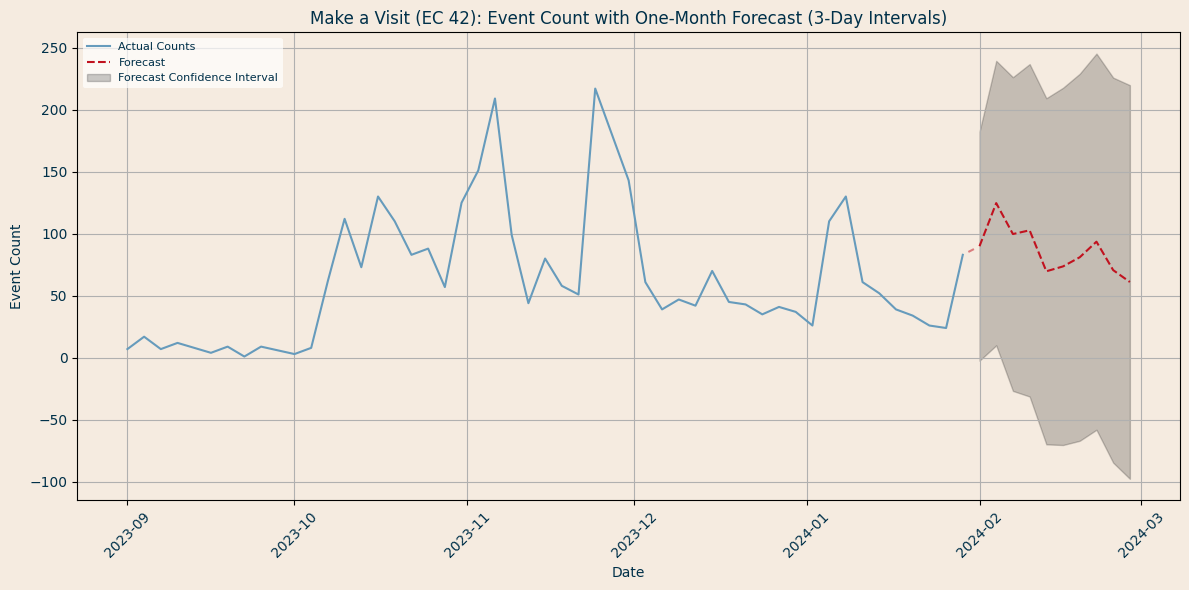

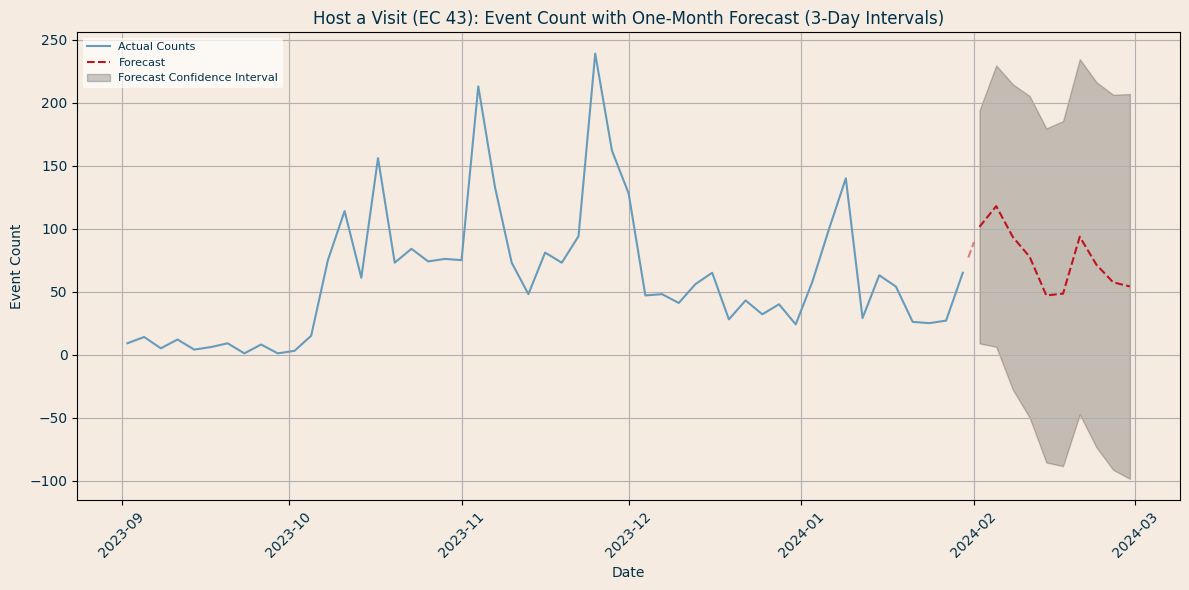

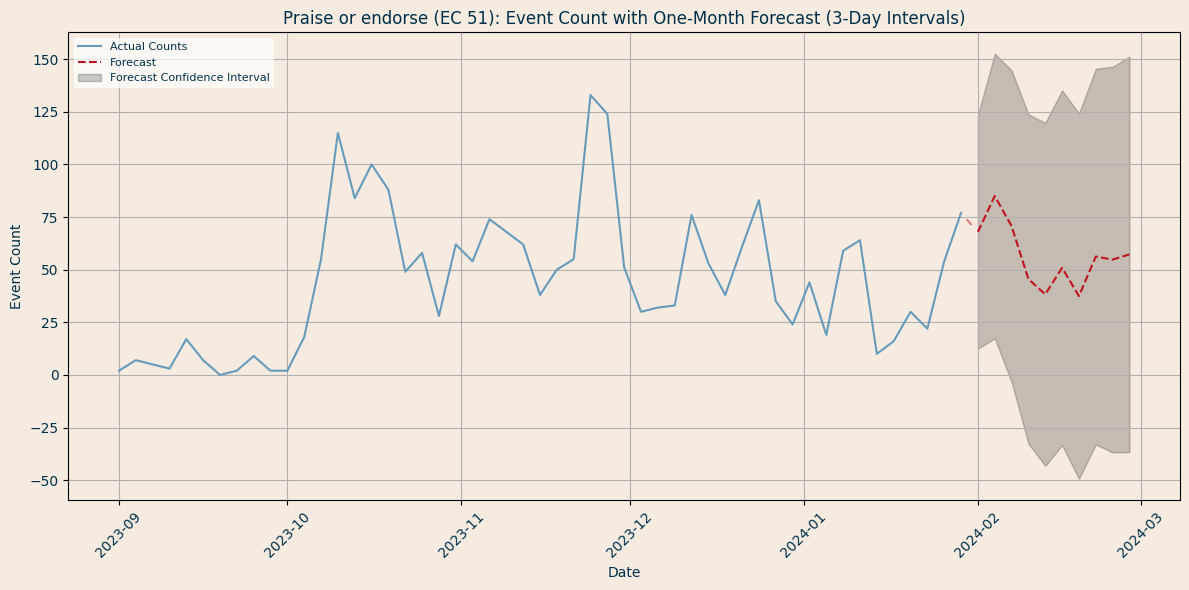

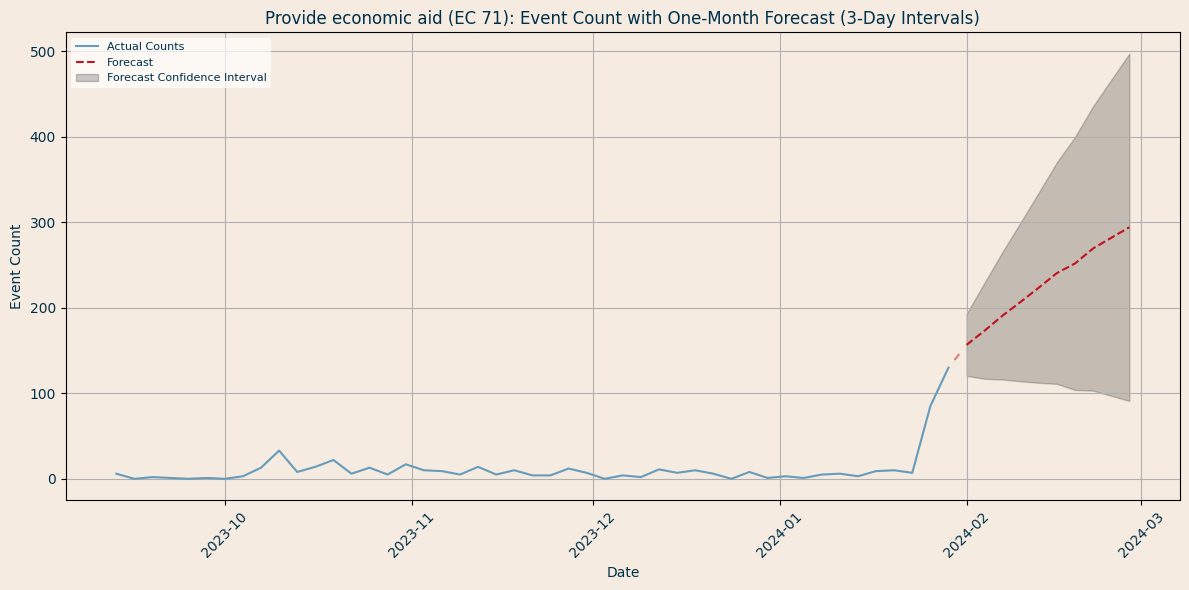

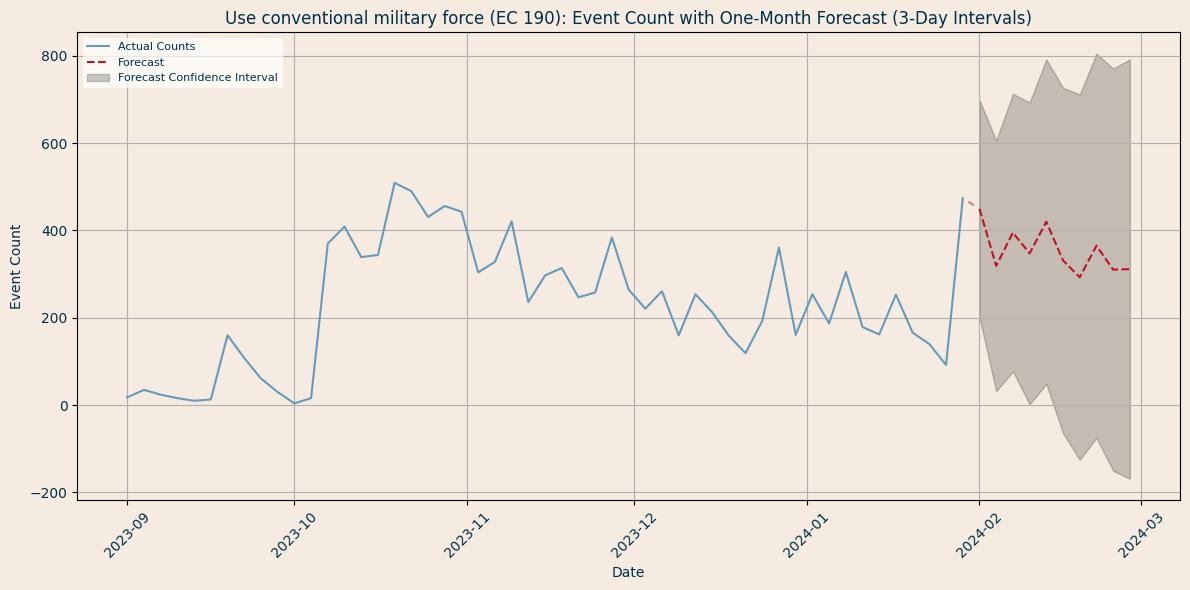

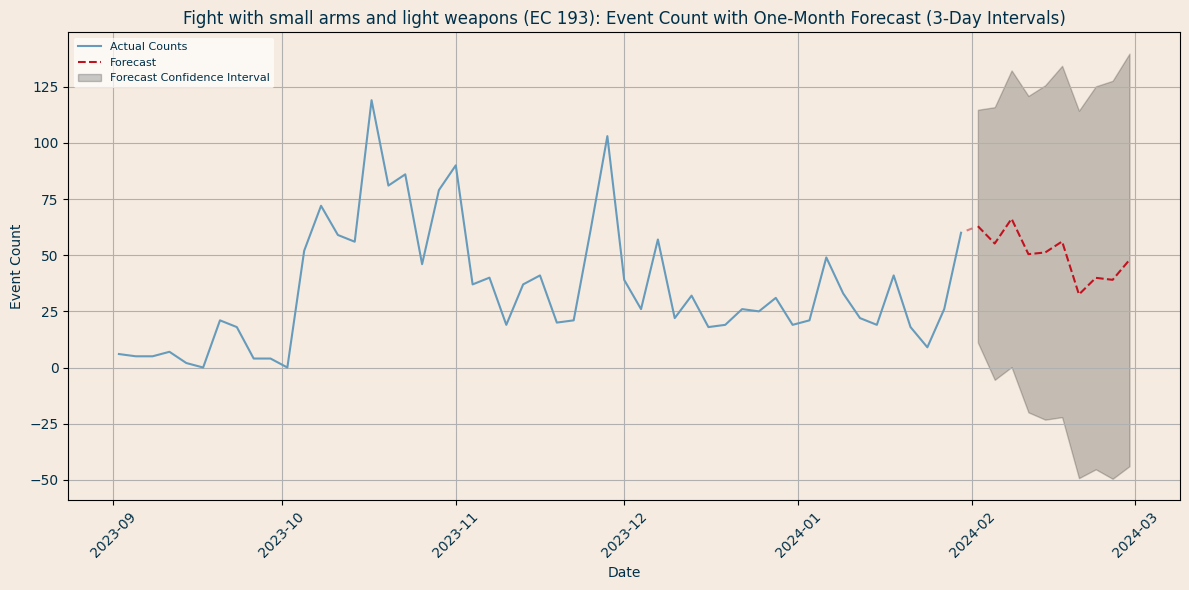

In [0]:

# Function to check stationarity
# Uses the Augmented Dickey-Fuller (ADF) test to check if a time series is stationary. 
# A time series is said to be stationary if its statistical properties such as mean, variance, and autocorrelation are constant over time. Specifically, stationarity means:
# # Mean: The average value of the series does not change over time.
# # Variance: The variability of the series is constant over time.
# # Autocorrelation: The relationship between values in the series is consistent over time.

# What is ADF statistic: A negative number; the more negative it is, the stronger the rejection of the null hypothesis (i.e., the more likely the series is stationary).
# p-value: A measure of the probability that the observed data could occur under the null hypothesis. A low p-value (typically ≤ 0.05) indicates strong evidence against the null hypothesis.

#ARIMA (AutoRegressive Integrated Moving Average) and SARIMA (Seasonal ARIMA), assume that the underlying time series is stationary. Non-stationary data can lead to unreliable and biased model parameters.

# Function to check stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

# Event codes, date range. event desc
event_codes = [42, 43, 51, 71, 190, 193]
start_date = '2023-09-01'
end_date = '2024-01-31'

# event codes dictionary
event_descriptions = {
    42: "Make a Visit",
    43: "Host a Visit",
    51: "Praise or endorse",
    71: "Provide economic aid",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons"
}

# Loop to generate plots
for event_code in event_codes:
    # Filter based on event code and date range
    filtered_data = df3[(df3['EventCode'] == event_code) &
                        (df3['SQLDATE'] >= start_date) &
                        (df3['SQLDATE'] <= end_date)]

    filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])

    # Aggregate data by date
    daily_counts = filtered_data.groupby('SQLDATE').size().reset_index(name='count')

    if daily_counts.empty:
        print(f"No data for EventCode {event_code} in the specified date range.")
        continue

    # Aggregate counts in 3-day intervals
    daily_counts.set_index('SQLDATE', inplace=True)
    interval_counts = daily_counts['count'].resample('3D').sum().reset_index()

    # Check stationarity
    print(f"Event Code {event_code}:")
    check_stationarity(interval_counts['count'])

    # Training data
    train = interval_counts.set_index('SQLDATE')

    # Fit SARIMAX model
    model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    results = model.fit()

    # Forecast
    future_steps = 10  # Projecting for 10 intervals into the future (each interval is 3 days)
    forecast = results.get_forecast(steps=future_steps)
    forecast_ci = forecast.conf_int()

    # Creating future dates for the forecast starting right after the last actual date
    future_dates = pd.date_range(start=train.index[-1] + timedelta(days=3), periods=future_steps, freq='3D')

    # Extract the forecasted mean
    forecast_mean = forecast.predicted_mean
    forecast_mean.index = future_dates

    # Interpolate (for continuous line)
    last_actual = train.iloc[-1]
    interpolated = pd.DataFrame({'count': np.linspace(last_actual['count'], forecast_mean.iloc[0], 4)[1:-1]}, 
                                index=pd.date_range(start=train.index[-1] + timedelta(days=1), periods=2, freq='1D'))

    # Combine actual data, interpolated points, and forecasted data
    combined_data = pd.concat([train, interpolated, forecast_mean], axis=0)

    # Plot the actual data, forecast, interplotated line, confidence interval
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train['count'], color='#669BBC', label='Actual Counts') #actual
    plt.plot(forecast_mean.index, forecast_mean, linestyle='--', color='#C1121F', label='Forecast') # forecast
    plt.plot(interpolated.index, interpolated['count'], linestyle='--', color='#C1121F', alpha=0.5) # interpolation
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.2, label='Forecast Confidence Interval') # confidence internval

    # Add vertical lines and descriptions for special dates
    #for date, desc in zip(special_dates, descriptions):
    #    plt.axvline(pd.to_datetime(date), color='#780000', linestyle='--')
    #    plt.text(pd.to_datetime(date), train['count'].max() * 0.9, desc, rotation=90, verticalalignment='center', horizontalalignment='right', color='#780000', fontsize=8, bbox=dict(facecolor='white', alpha=0.7)) #0.6 to make description within the graph

    #for date, desc in zip(special_dates, descriptions):
     #   plt.axvline(pd.to_datetime(date), color='#780000', linestyle='--')
      #  plt.text(pd.to_datetime(date), train['count'].max(), desc, rotation=90, verticalalignment='center', #horizontalalignment='right', color='#780000', fontsize=8, bbox=dict(facecolor='white', alpha=0.7))

    plt.xlabel('Date', color='#003049')
    plt.ylabel('Event Count', color='#003049')
    title = event_descriptions.get(event_code, f"Event Code {event_code}")
    plt.title(f'{title} (EC {event_code}): Event Count with One-Month Forecast (3-Day Intervals)', color='#003049')
    plt.legend(facecolor='white', framealpha=0.7, edgecolor='none', fontsize=8, loc='upper left', labelcolor='#003049')
    plt.grid(True)
    plt.xticks(rotation=45, color='#003049')
    plt.yticks(color='#003049')
    plt.gca().set_facecolor('#F5EBE0') #background color #FDF0D5
    plt.gcf().set_facecolor('#F5EBE0') #background color
    plt.tight_layout()


# Event Trend Forecast Visualisations
### 1(b) Forecast with only the projection overlayed on actual counts

/root/.ipykernel/1162/command-2714981194622960-3114747875:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters foun

Event Code 42:
ADF Statistic: -2.292351
p-value: 0.174447
	1%: -3.670
	5%: -2.964
	10%: -2.621
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.27946D+00    |proj g|=  5.05084D-02

At iterate    5    f=  3.26906D+00    |proj g|=  4.14117D-02

At iterate   10    f=  3.24557D+00    |proj g|=  2.09478D-02

At iterate   15    f=  3.23845D+00    |proj g|=  2.82663D-03

At iterate   20    f=  3.22012D+00    |proj g|=  4.11821D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5   

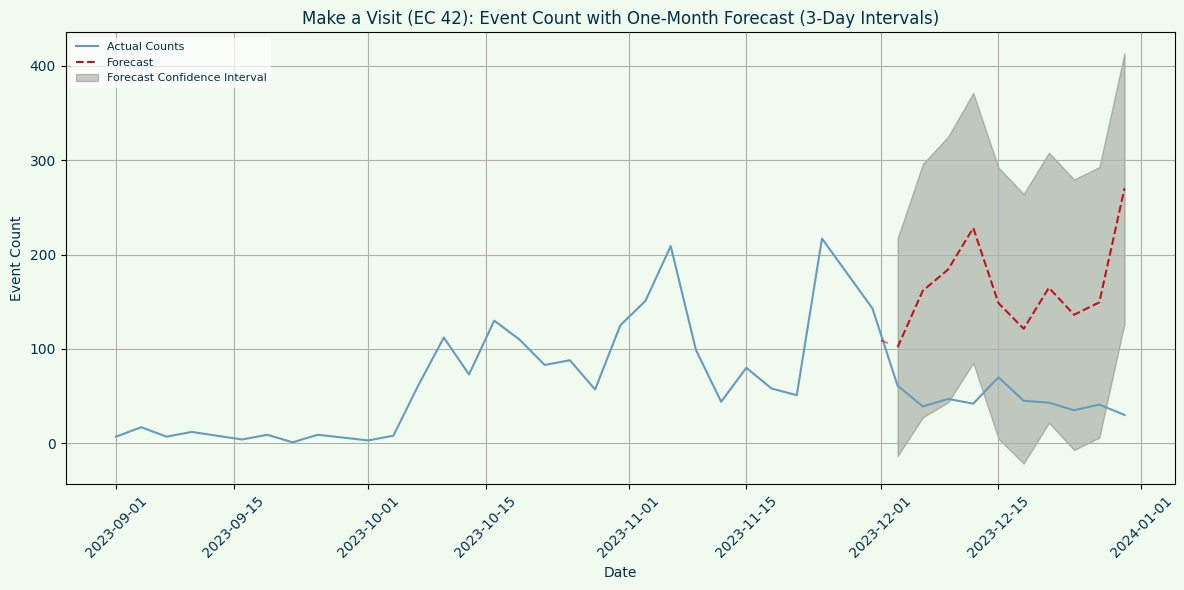

/root/.ipykernel/1162/command-2714981194622960-3114747875:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 43:
ADF Statistic: -2.689412
p-value: 0.075888
	1%: -3.670
	5%: -2.964
	10%: -2.621
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.34284D+00    |proj g|=  6.24956D-02

At iterate    5    f=  3.31991D+00    |proj g|=  3.20475D-03

At iterate   10    f=  3.29890D+00    |proj g|=  2.90805D-02

At iterate   15    f=  3.28664D+00    |proj g|=  2.93158D-04

At iterate   20    f=  3.28663D+00    |proj g|=  1.67493D-03

At iterate   25    f=  3.28657D+00    |proj g|=  1.75137D-03

At iterate   30    f=  3.28652D+00    |proj g|=  1.23946D-03

At iterate   35    f=  3.28649D+00    |proj g|=  9.42727D-04

At iterate   40    f=  3.28647D+00    |proj g|=  1.60242D-03

At iterate   45    f=  3.28646D+00    |proj g|=  5.03543D-04

At iterate   50    f=  3.28645D+00    |proj g|=  2.38772D-04

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-2714981194622960-3114747875:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


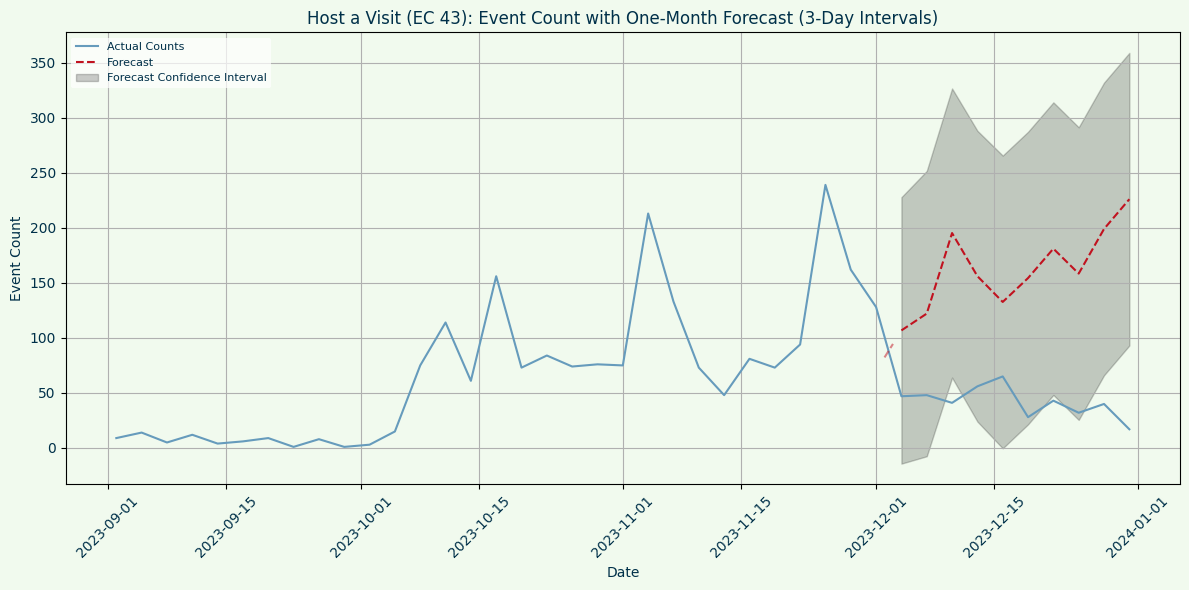

/root/.ipykernel/1162/command-2714981194622960-3114747875:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters foun

Event Code 51:
ADF Statistic: -2.254892
p-value: 0.186929
	1%: -3.670
	5%: -2.964
	10%: -2.621
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.03396D+00    |proj g|=  1.65214D-01

At iterate    5    f=  2.99385D+00    |proj g|=  1.83908D-02

At iterate   10    f=  2.97414D+00    |proj g|=  1.75050D-02

At iterate   15    f=  2.96052D+00    |proj g|=  3.38560D-02

At iterate   20    f=  2.93646D+00    |proj g|=  1.14156D-02

At iterate   25    f=  2.93403D+00    |proj g|=  2.49097D-05

At iterate   30    f=  2.93403D+00    |proj g|=  5.04111D-04

At iterate   35    f=  2.93403D+00    |proj g|=  7.25238D-04

At iterate   40    f=  2.93402D+00    |proj g|=  4.31854D-04

At iterate   45    f=  2.93401D+00    |proj g|=  3.79872D-04

At iterate   50    f=  2.93401D+00    |proj g|=  1.17753D-04

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-2714981194622960-3114747875:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


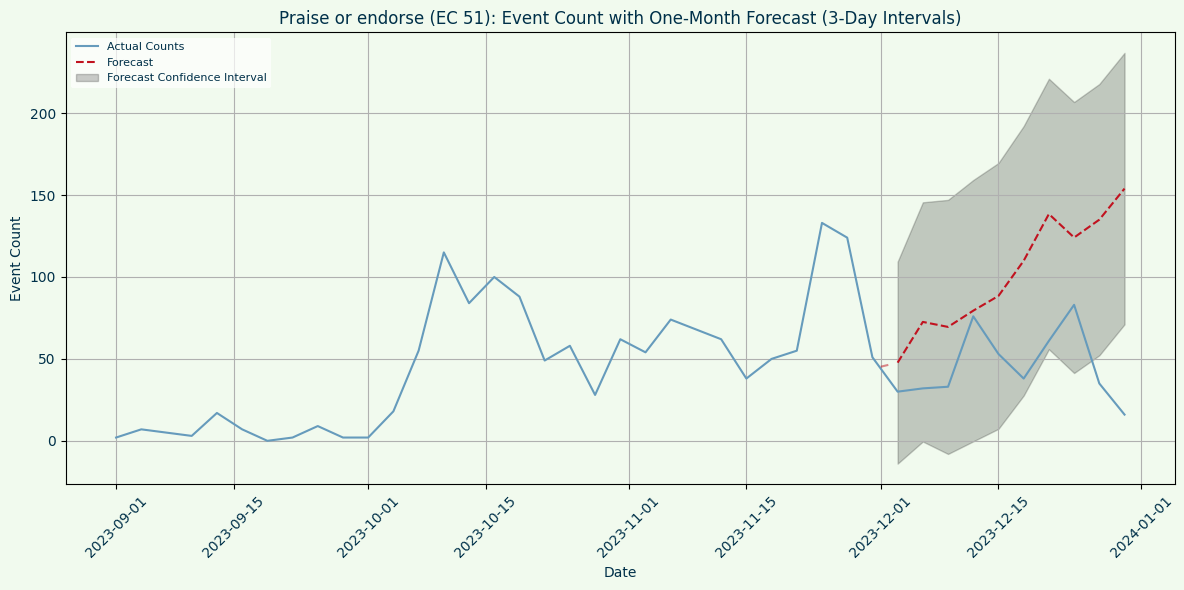

/root/.ipykernel/1162/command-2714981194622960-3114747875:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 71:
ADF Statistic: -1.931964
p-value: 0.317177
	1%: -3.738
	5%: -2.992
	10%: -2.636
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.01151D+00    |proj g|=  3.01826D-02

At iterate    5    f=  1.98222D+00    |proj g|=  3.54362D-02

At iterate   10    f=  1.97388D+00    |proj g|=  2.52732D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     13     16      1     0     0   1.325D-05   1.974D+00
  F =   1.9738553454419037     

CONVERGENCE: REL_REDUCTION_OF_F_<=_F

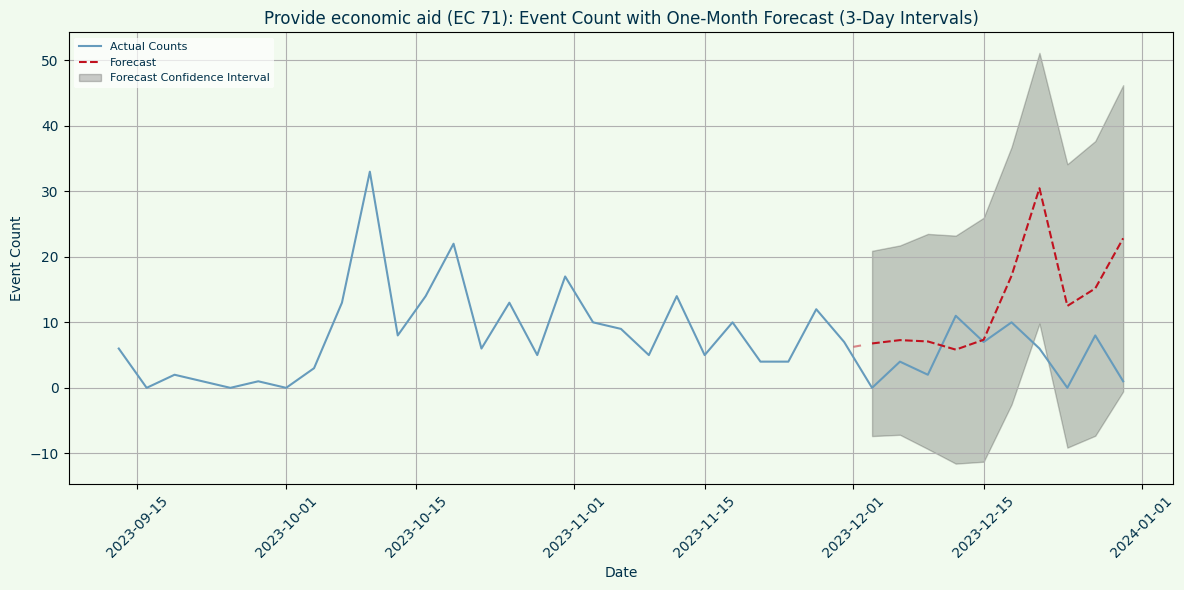

/root/.ipykernel/1162/command-2714981194622960-3114747875:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 190:
ADF Statistic: -1.881509
p-value: 0.340809
	1%: -3.670
	5%: -2.964
	10%: -2.621
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.76076D+00    |proj g|=  3.76527D-02

At iterate    5    f=  3.74296D+00    |proj g|=  2.49363D-03

At iterate   10    f=  3.74274D+00    |proj g|=  3.57824D-03

At iterate   15    f=  3.73980D+00    |proj g|=  1.66100D-02

At iterate   20    f=  3.71097D+00    |proj g|=  2.08690D-02

At iterate   25    f=  3.70947D+00    |proj g|=  1.78540D-03

At iterate   30    f=  3.70936D+00    |proj g|=  3.20637D-03

At iterate   35    f=  3.70931D+00    |proj g|=  7.04484D-04

At iterate   40    f=  3.70929D+00    |proj g|=  8.40934D-04

At iterate   45    f=  3.70928D+00    |proj g|=  6.03670D-04

At iterate   50    f=  3.70927D+00    |proj g|=  1.34968D-04

           * * *

Tit   = total number of iterations
T

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-2714981194622960-3114747875:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


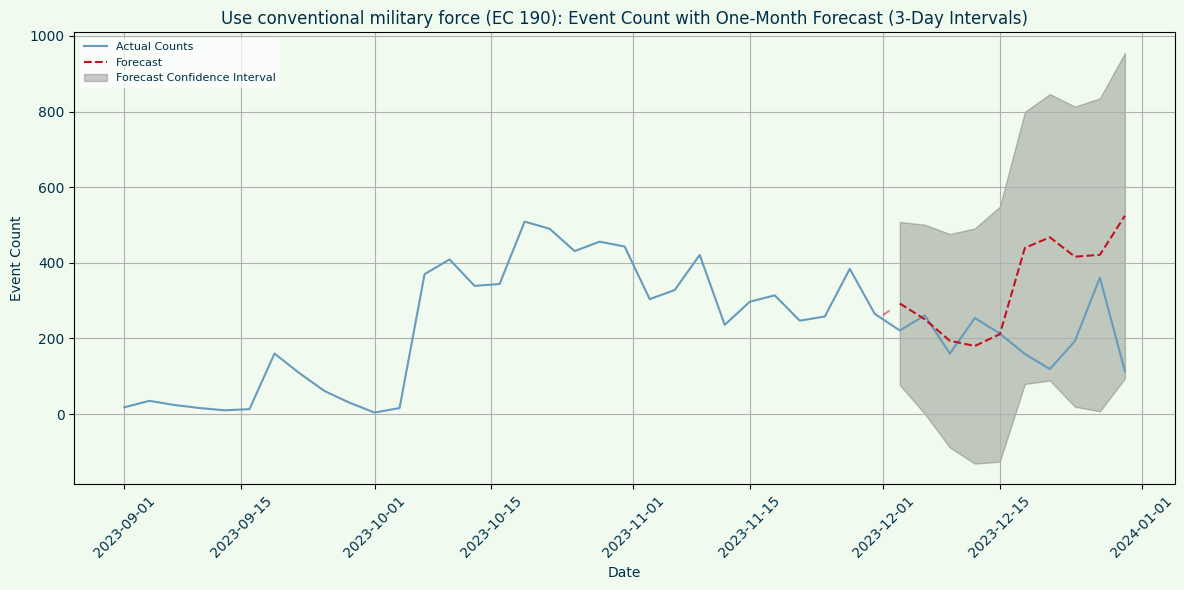

/root/.ipykernel/1162/command-2714981194622960-3114747875:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 193:
ADF Statistic: -2.715352
p-value: 0.071419
	1%: -3.670
	5%: -2.964
	10%: -2.621
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.97257D+00    |proj g|=  4.57043D-02

At iterate    5    f=  2.96097D+00    |proj g|=  6.93962D-03

At iterate   10    f=  2.95978D+00    |proj g|=  1.06752D-02

At iterate   15    f=  2.95653D+00    |proj g|=  2.73617D-04

At iterate   20    f=  2.95653D+00    |proj g|=  9.98688D-05

At iterate   25    f=  2.95653D+00    |proj g|=  1.95902D-04

At iterate   30    f=  2.95652D+00    |proj g|=  4.82886D-04

At iterate   35    f=  2.95652D+00    |proj g|=  2.79188D-04

At iterate   40    f=  2.95652D+00    |proj g|=  8.62995D-05

At iterate   45    f=  2.95652D+00    |proj g|=  2.35818D-04

At iterate   50    f=  2.95652D+00    |proj g|=  1.12381D-04

           * * *

Tit   = total number of iterations
T

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-2714981194622960-3114747875:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


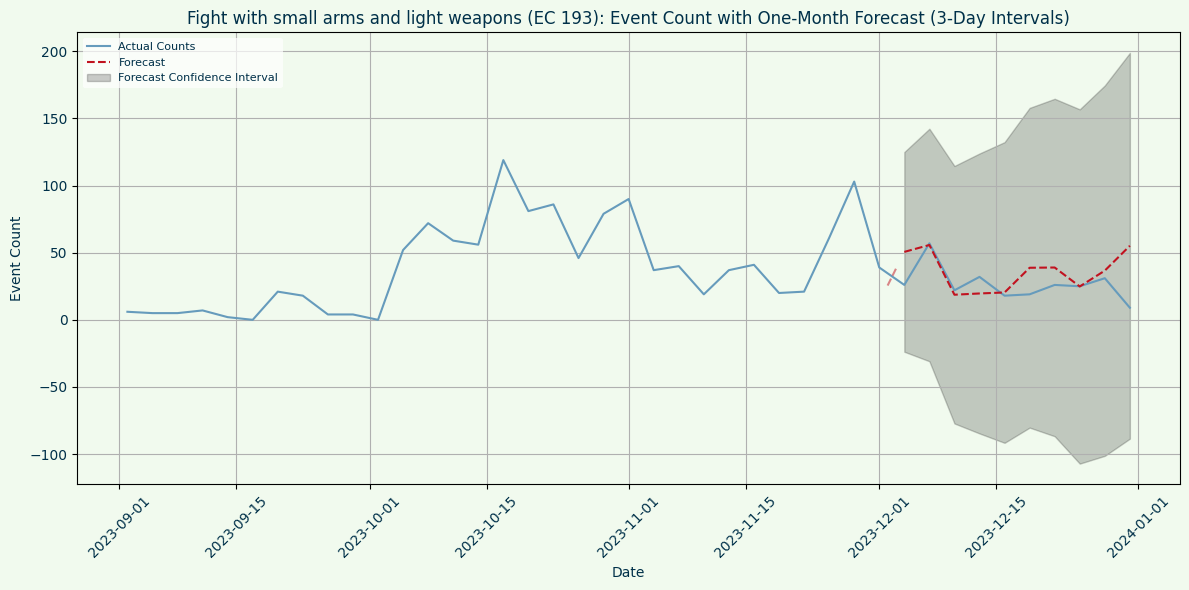

In [0]:
# Event codes, date range. event desc
event_codes = [42, 43, 51, 71, 190, 193]
start_date = '2023-09-01'
end_date = '2023-12-01'

# event codes dictionary
event_descriptions = {
    42: "Make a Visit",
    43: "Host a Visit",
    51: "Praise or endorse",
    71: "Provide economic aid",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons"
}

# Loop to generate plots
for event_code in event_codes:
    # Filter based on event code and date range
    filtered_data = df3[(df3['EventCode'] == event_code) &
                        (df3['SQLDATE'] >= start_date) &
                        (df3['SQLDATE'] <= end_date)]
    
    filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])

    # Aggregate data by date
    daily_counts = filtered_data.groupby('SQLDATE').size().reset_index(name='count')

    if daily_counts.empty:
        print(f"No data for EventCode {event_code} in the specified date range.")
        continue

    # Aggregate counts in 3-day intervals
    daily_counts.set_index('SQLDATE', inplace=True)
    interval_counts = daily_counts['count'].resample('3D').sum().reset_index()

    # Check stationarity
    print(f"Event Code {event_code}:")
    check_stationarity(interval_counts['count'])

    # Training
    train = interval_counts.set_index('SQLDATE')

    # Fit SARIMAX model
    model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    results = model.fit()

    # Forecast
    future_steps = 10  # Projecting for 10 intervals into the future (each interval is 3 days)
    forecast = results.get_forecast(steps=future_steps)
    forecast_ci = forecast.conf_int()

    # Creating future dates for the forecast starting right after the last actual date
    future_dates = pd.date_range(start=train.index[-1] + timedelta(days=3), periods=future_steps, freq='3D')

    # Extract the forecasted mean
    forecast_mean = forecast.predicted_mean
    forecast_mean.index = future_dates

    # Interpolate to avoid the gap
    last_actual = train.iloc[-1]
    interpolated = pd.DataFrame({'count': np.linspace(last_actual['count'], forecast_mean.iloc[0], 4)[1:-1]}, 
                                index=pd.date_range(start=train.index[-1] + timedelta(days=1), periods=2, freq='1D'))

    # Combine actual data, interpolated points, and forecasted data
    combined_forecast = pd.concat([train, interpolated, forecast_mean], axis=0)

    # Actual data until 31 Dec 2023
    actual_data = df3[(df3['EventCode'] == event_code) & 
                      (df3['SQLDATE'] >= start_date) & 
                      (df3['SQLDATE'] <= '2023-12-31')]

    actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])
    actual_daily_counts = actual_data.groupby('SQLDATE').size().reset_index(name='count')
    actual_daily_counts.set_index('SQLDATE', inplace=True)
    actual_interval_counts = actual_daily_counts['count'].resample('3D').sum().reset_index()

    # Plot the actual data until 30 July 2022
    plt.figure(figsize=(12, 6))
    plt.plot(actual_interval_counts['SQLDATE'], actual_interval_counts['count'], color='#669BBC', label='Actual Counts')
    plt.plot(forecast_mean.index, forecast_mean, linestyle='--', color='#C1121F', label='Forecast') # forecast
    plt.plot(interpolated.index, interpolated['count'], linestyle='--', color='#C1121F', alpha=0.5) # interpolation
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.2, label='Forecast Confidence Interval') # confidence interval

    # Add vertical lines and descriptions for special dates
    #for date, desc in zip(special_dates, descriptions):
    #    plt.axvline(pd.to_datetime(date), color='#780000', linestyle='--')
    #    plt.text(pd.to_datetime(date), actual_interval_counts['count'].max() * 0.9, desc, rotation=90, verticalalignment='center', horizontalalignment='right', color='#780000', fontsize=8, bbox=dict(facecolor='white', alpha=0.7)) #0.6 + alignment right to have clear descriptions

    plt.xlabel('Date', color='#003049')
    plt.ylabel('Event Count', color='#003049')
    title = event_descriptions.get(event_code, f"Event Code {event_code}")
    plt.title(f'{title} (EC {event_code}): Event Count with One-Month Forecast (3-Day Intervals)', color='#003049')
    plt.legend(facecolor='white', framealpha=0.7, edgecolor='none', fontsize=8, loc='upper left', labelcolor='#003049')
    plt.grid(True)
    plt.xticks(rotation=45, color='#003049')
    plt.yticks(color='#003049')
    plt.gca().set_facecolor('#F1FAEE') #background color 
    plt.gcf().set_facecolor('#F1FAEE') #background color
    plt.tight_layout()

    # Display the plot
    plt.show()


/root/.ipykernel/1162/command-1848653201928490-3604682753:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters foun

Event Code 42:
ADF Statistic: -2.673672
p-value: 0.078706
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.89972D+00    |proj g|=  2.83622D-01

At iterate    5    f=  3.81794D+00    |proj g|=  4.16985D-03

At iterate   10    f=  3.78968D+00    |proj g|=  8.92368D-02

At iterate   15    f=  3.73061D+00    |proj g|=  2.85582D-02

At iterate   20    f=  3.72157D+00    |proj g|=  1.84902D-02

At iterate   25    f=  3.71570D+00    |proj g|=  5.30974D-04

At iterate   30    f=  3.71395D+00    |proj g|=  1.85532D-02

At iterate   35    f=  3.71250D+00    |proj g|=  3.09187D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at fina

/root/.ipykernel/1162/command-1848653201928490-3604682753:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


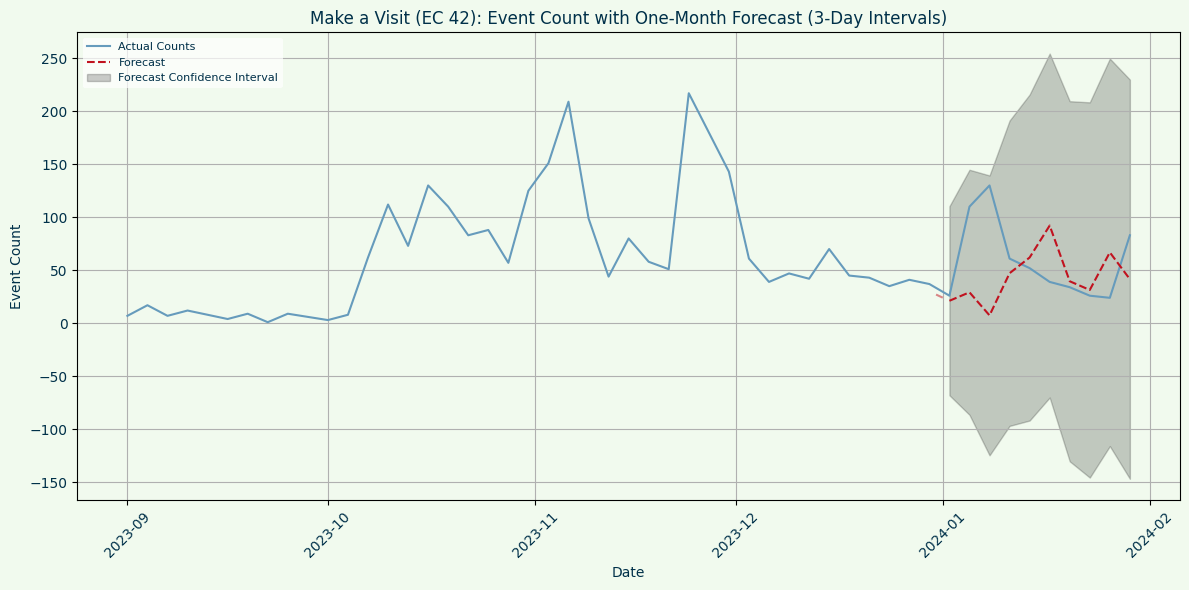

/root/.ipykernel/1162/command-1848653201928490-3604682753:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 43:
ADF Statistic: -2.936530
p-value: 0.041262
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.95910D+00    |proj g|=  2.89928D-01

At iterate    5    f=  3.87541D+00    |proj g|=  4.73802D-03

At iterate   10    f=  3.87196D+00    |proj g|=  1.88082D-02

At iterate   15    f=  3.82990D+00    |proj g|=  6.95989D-03

At iterate   20    f=  3.81699D+00    |proj g|=  1.07813D-02

At iterate   25    f=  3.80152D+00    |proj g|=  8.22735D-03

At iterate   30    f=  3.79744D+00    |proj g|=  9.98812D-03

At iterate   35    f=  3.78479D+00    |proj g|=  2.06304D-02

At iterate   40    f=  3.78339D+00    |proj g|=  4.90117D-02

At iterate   45    f=  3.77322D+00    |proj g|=  3.44751D-03

At iterate   50    f=  3.77319D+00    |proj g|=  5.81539D-06

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928490-3604682753:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


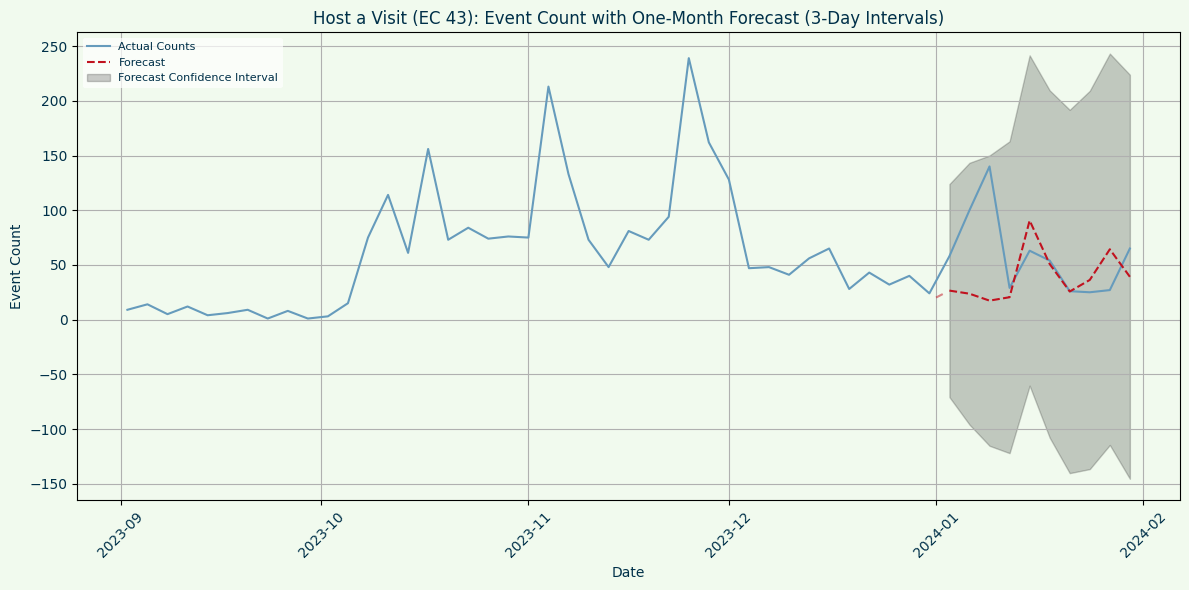

/root/.ipykernel/1162/command-1848653201928490-3604682753:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters foun

Event Code 51:
ADF Statistic: -2.868210
p-value: 0.049172
	1%: -3.610
	5%: -2.939
	10%: -2.608
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.53798D+00    |proj g|=  2.98166D-01

At iterate    5    f=  3.45835D+00    |proj g|=  5.79019D-03

At iterate   10    f=  3.45202D+00    |proj g|=  1.03848D-02

At iterate   15    f=  3.43880D+00    |proj g|=  1.18606D-02

At iterate   20    f=  3.42510D+00    |proj g|=  3.75094D-02

At iterate   25    f=  3.41867D+00    |proj g|=  8.13045D-03

At iterate   30    f=  3.41758D+00    |proj g|=  1.96092D-03

At iterate   35    f=  3.41720D+00    |proj g|=  6.17601D-04

At iterate   40    f=  3.41720D+00    |proj g|=  1.11257D-04

At iterate   45    f=  3.41718D+00    |proj g|=  7.65133D-05

At iterate   50    f=  3.41718D+00    |proj g|=  2.22128D-04

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928490-3604682753:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


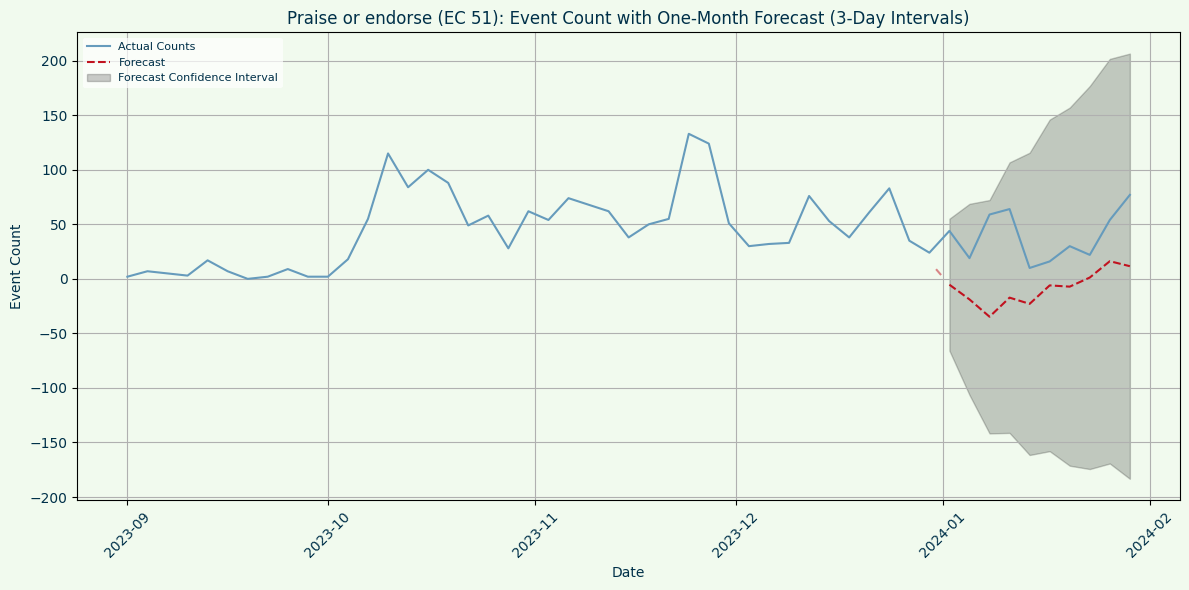

/root/.ipykernel/1162/command-1848653201928490-3604682753:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 71:
ADF Statistic: -2.245659
p-value: 0.190093
	1%: -3.639
	5%: -2.951
	10%: -2.614
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.39158D+00    |proj g|=  1.06783D-01

At iterate    5    f=  2.37059D+00    |proj g|=  3.57389D-02

At iterate   10    f=  2.36445D+00    |proj g|=  5.25106D-04

At iterate   15    f=  2.36424D+00    |proj g|=  6.46178D-03

At iterate   20    f=  2.36388D+00    |proj g|=  1.16061D-03

At iterate   25    f=  2.36378D+00    |proj g|=  3.53618D-04

At iterate   30    f=  2.36374D+00    |proj g|=  1.36104D-04

At iterate   35    f=  2.36373D+00    |proj g|=  4.26115D-04

At iterate   40    f=  2.36373D+00    |proj g|=  2.56197D-04

At iterate   45    f=  2.36372D+00    |proj g|=  4.90435D-05

At iterate   50    f=  2.36372D+00    |proj g|=  4.11070D-05

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928490-3604682753:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


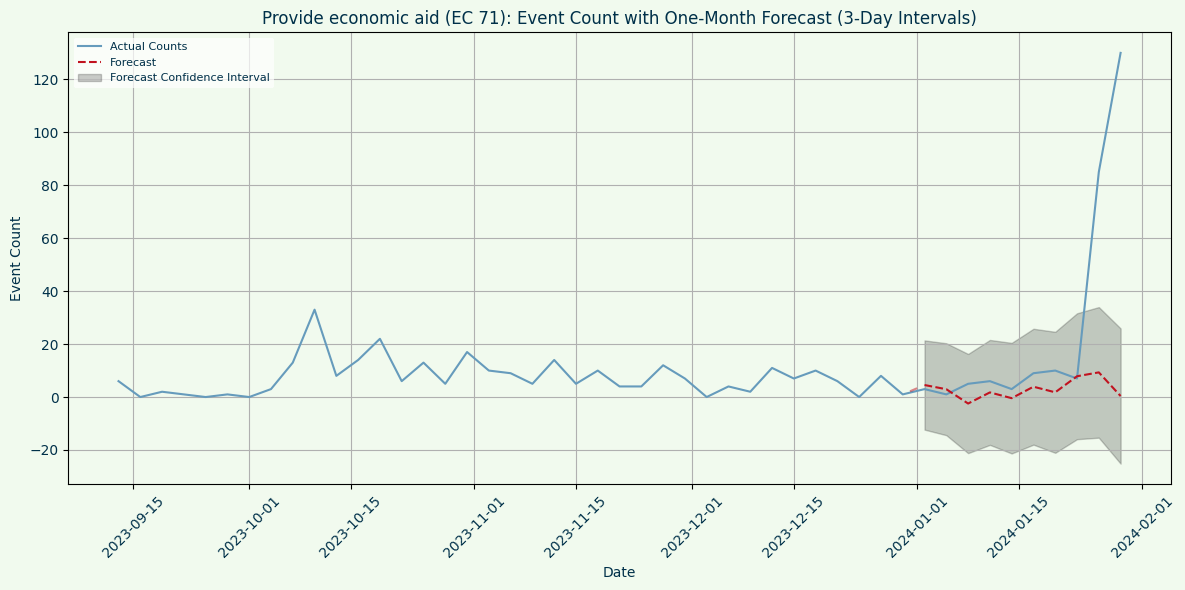

/root/.ipykernel/1162/command-1848653201928490-3604682753:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 190:
ADF Statistic: -2.365347
p-value: 0.151757
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.35375D+00    |proj g|=  6.65824D-02

At iterate    5    f=  4.33829D+00    |proj g|=  4.87849D-03

At iterate   10    f=  4.33646D+00    |proj g|=  2.32005D-03

At iterate   15    f=  4.33637D+00    |proj g|=  2.34025D-03

At iterate   20    f=  4.33105D+00    |proj g|=  3.50909D-02

At iterate   25    f=  4.32602D+00    |proj g|=  4.58740D-03

At iterate   30    f=  4.32500D+00    |proj g|=  1.47653D-03

At iterate   35    f=  4.32485D+00    |proj g|=  5.46064D-04

At iterate   40    f=  4.32482D+00    |proj g|=  1.48332D-04

At iterate   45    f=  4.32481D+00    |proj g|=  1.17179D-04

At iterate   50    f=  4.32481D+00    |proj g|=  9.90764D-05

           * * *

Tit   = total number of iterations
T

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928490-3604682753:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


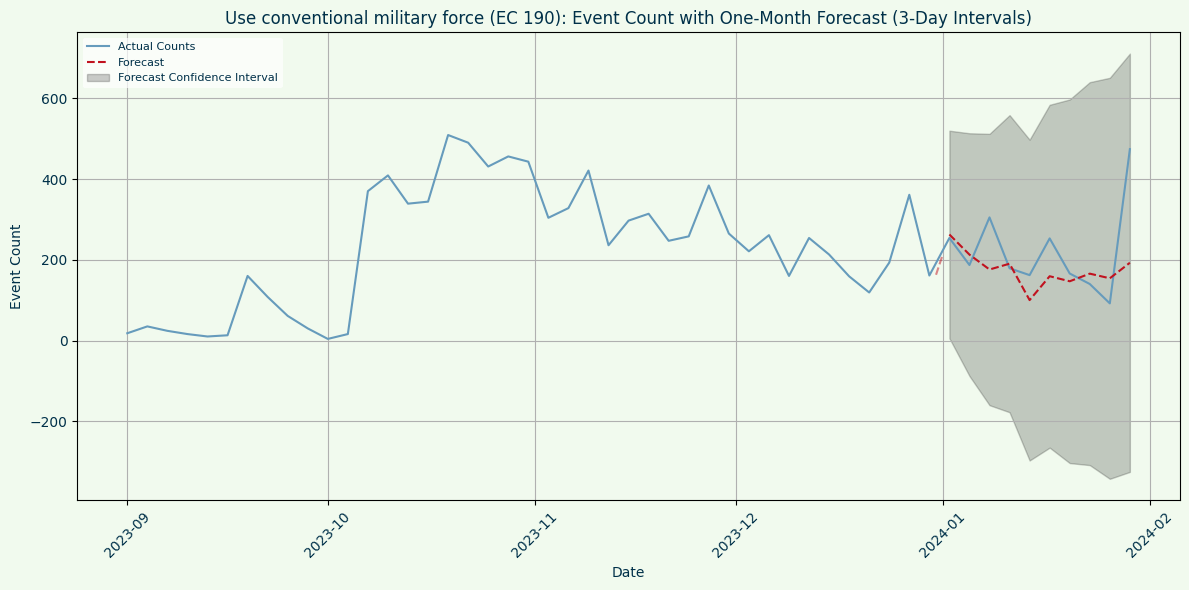

/root/.ipykernel/1162/command-1848653201928490-3604682753:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters f

Event Code 193:
ADF Statistic: -2.968582
p-value: 0.037934
	1%: -3.606
	5%: -2.937
	10%: -2.607
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.43615D+00    |proj g|=  2.17420D-01

At iterate    5    f=  3.36906D+00    |proj g|=  4.04954D-03

At iterate   10    f=  3.35896D+00    |proj g|=  1.65464D-02

At iterate   15    f=  3.34910D+00    |proj g|=  1.30491D-03

At iterate   20    f=  3.34631D+00    |proj g|=  2.08972D-02

At iterate   25    f=  3.33136D+00    |proj g|=  3.33740D-02

At iterate   30    f=  3.32881D+00    |proj g|=  2.95801D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projecte

/root/.ipykernel/1162/command-1848653201928490-3604682753:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


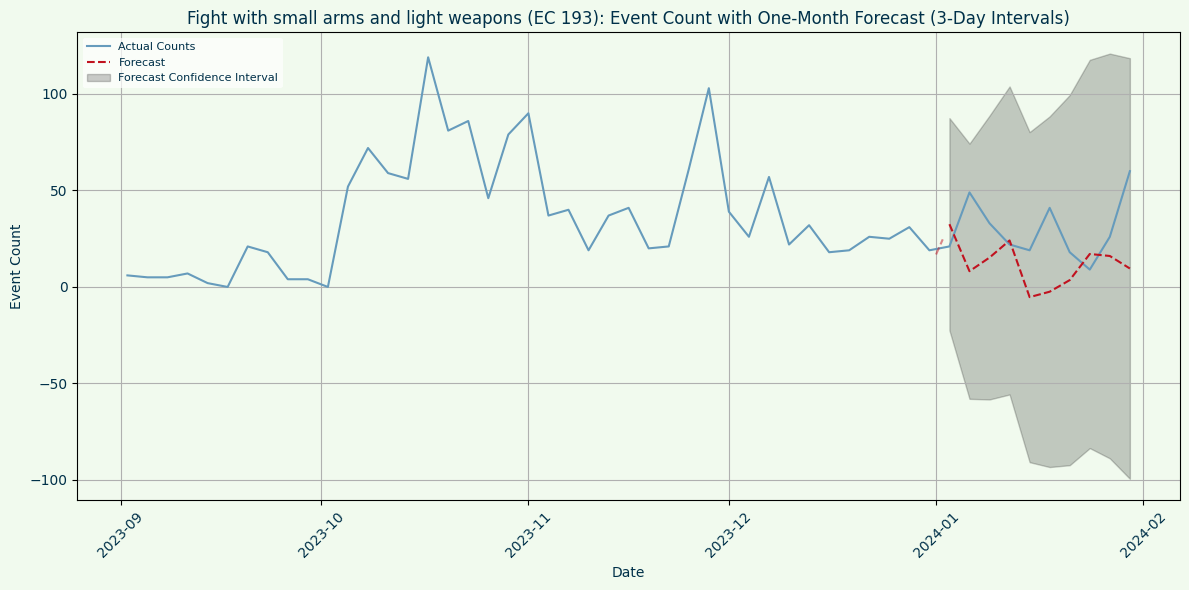

In [0]:
# Event codes, date range. event desc
event_codes = [42, 43, 51, 71, 190, 193]
start_date = '2023-09-01'
end_date = '2023-12-31'

# event codes dictionary
event_descriptions = {
    42: "Make a Visit",
    43: "Host a Visit",
    51: "Praise or endorse",
    71: "Provide economic aid",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons"
}

# Loop to generate plots
for event_code in event_codes:
    # Filter based on event code and date range
    filtered_data = df3[(df3['EventCode'] == event_code) &
                        (df3['SQLDATE'] >= start_date) &
                        (df3['SQLDATE'] <= end_date)]
    
    filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])

    # Aggregate data by date
    daily_counts = filtered_data.groupby('SQLDATE').size().reset_index(name='count')

    if daily_counts.empty:
        print(f"No data for EventCode {event_code} in the specified date range.")
        continue

    # Aggregate counts in 3-day intervals
    daily_counts.set_index('SQLDATE', inplace=True)
    interval_counts = daily_counts['count'].resample('3D').sum().reset_index()

    # Check stationarity
    print(f"Event Code {event_code}:")
    check_stationarity(interval_counts['count'])

    # Training
    train = interval_counts.set_index('SQLDATE')

    # Fit SARIMAX model
    model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    results = model.fit()

    # Forecast
    future_steps = 10  # Projecting for 10 intervals into the future (each interval is 3 days)
    forecast = results.get_forecast(steps=future_steps)
    forecast_ci = forecast.conf_int()

    # Creating future dates for the forecast starting right after the last actual date
    future_dates = pd.date_range(start=train.index[-1] + timedelta(days=3), periods=future_steps, freq='3D')

    # Extract the forecasted mean
    forecast_mean = forecast.predicted_mean
    forecast_mean.index = future_dates

    # Interpolate to avoid the gap
    last_actual = train.iloc[-1]
    interpolated = pd.DataFrame({'count': np.linspace(last_actual['count'], forecast_mean.iloc[0], 4)[1:-1]}, 
                                index=pd.date_range(start=train.index[-1] + timedelta(days=1), periods=2, freq='1D'))

    # Combine actual data, interpolated points, and forecasted data
    combined_forecast = pd.concat([train, interpolated, forecast_mean], axis=0)

    # Actual data until 31 Dec 2023
    actual_data = df3[(df3['EventCode'] == event_code) & 
                      (df3['SQLDATE'] >= start_date) & 
                      (df3['SQLDATE'] <= '2024-01-31')]

    actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])
    actual_daily_counts = actual_data.groupby('SQLDATE').size().reset_index(name='count')
    actual_daily_counts.set_index('SQLDATE', inplace=True)
    actual_interval_counts = actual_daily_counts['count'].resample('3D').sum().reset_index()

    # Plot the actual data until 30 July 2022
    plt.figure(figsize=(12, 6))
    plt.plot(actual_interval_counts['SQLDATE'], actual_interval_counts['count'], color='#669BBC', label='Actual Counts')
    plt.plot(forecast_mean.index, forecast_mean, linestyle='--', color='#C1121F', label='Forecast') # forecast
    plt.plot(interpolated.index, interpolated['count'], linestyle='--', color='#C1121F', alpha=0.5) # interpolation
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.2, label='Forecast Confidence Interval') # confidence interval

    # Add vertical lines and descriptions for special dates
    #for date, desc in zip(special_dates, descriptions):
    #    plt.axvline(pd.to_datetime(date), color='#780000', linestyle='--')
    #    plt.text(pd.to_datetime(date), actual_interval_counts['count'].max() * 0.9, desc, rotation=90, verticalalignment='center', horizontalalignment='right', color='#780000', fontsize=8, bbox=dict(facecolor='white', alpha=0.7)) #0.6 + alignment right to have clear descriptions

    plt.xlabel('Date', color='#003049')
    plt.ylabel('Event Count', color='#003049')
    title = event_descriptions.get(event_code, f"Event Code {event_code}")
    plt.title(f'{title} (EC {event_code}): Event Count with One-Month Forecast (3-Day Intervals)', color='#003049')
    plt.legend(facecolor='white', framealpha=0.7, edgecolor='none', fontsize=8, loc='upper left', labelcolor='#003049')
    plt.grid(True)
    plt.xticks(rotation=45, color='#003049')
    plt.yticks(color='#003049')
    plt.gca().set_facecolor('#F1FAEE') #background color 
    plt.gcf().set_facecolor('#F1FAEE') #background color
    plt.tight_layout()

    # Display the plot
    plt.show()


/root/.ipykernel/1162/command-1848653201928491-3598416523:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters foun

Event Code 42:
ADF Statistic: -4.000806
p-value: 0.001406
	1%: -3.504
	5%: -2.894
	10%: -2.584
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.53759D+00    |proj g|=  2.02282D-01

At iterate    5    f=  4.47328D+00    |proj g|=  7.25688D-03

At iterate   10    f=  4.44592D+00    |proj g|=  2.65426D-02

At iterate   15    f=  4.38263D+00    |proj g|=  2.20127D-02

At iterate   20    f=  4.36156D+00    |proj g|=  3.95230D-02

At iterate   25    f=  4.35723D+00    |proj g|=  4.24182D-03

At iterate   30    f=  4.35671D+00    |proj g|=  9.80431D-04

At iterate   35    f=  4.35666D+00    |proj g|=  4.56901D-04

At iterate   40    f=  4.35664D+00    |proj g|=  2.85978D-04

At iterate   45    f=  4.34799D+00    |proj g|=  1.94998D-02

At iterate   50    f=  4.34729D+00    |proj g|=  6.51745D-06

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928491-3598416523:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


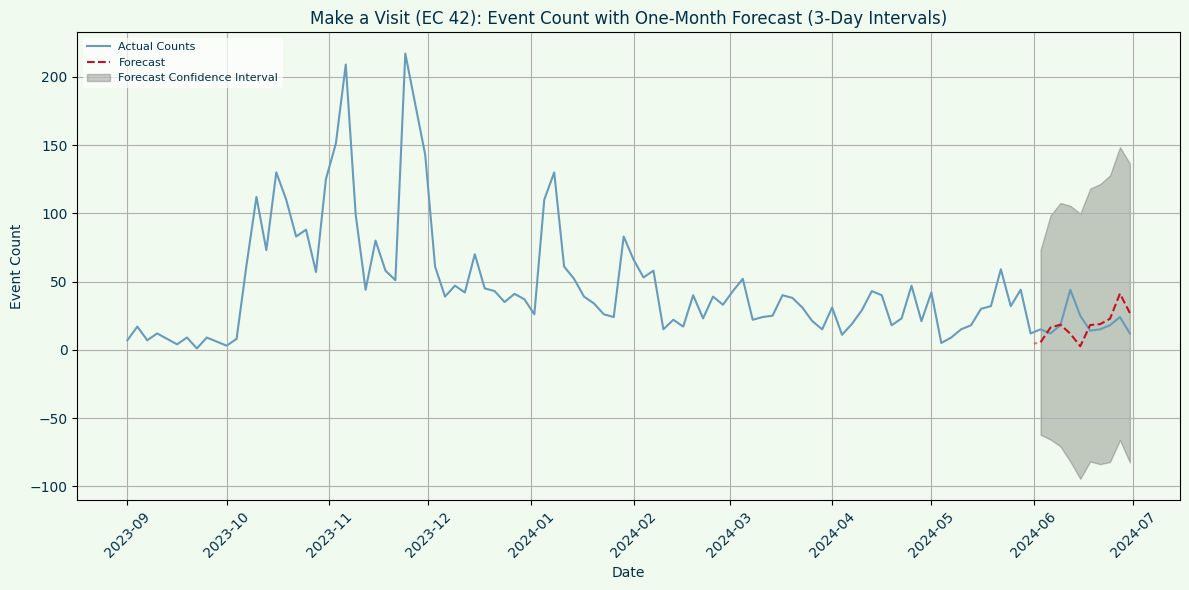

/root/.ipykernel/1162/command-1848653201928491-3598416523:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


Event Code 43:
ADF Statistic: -4.560204
p-value: 0.000153
	1%: -3.505
	5%: -2.894
	10%: -2.584
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.57573D+00    |proj g|=  1.55504D-01

At iterate    5    f=  4.53272D+00    |proj g|=  1.58837D-02

At iterate   10    f=  4.50884D+00    |proj g|=  2.46869D-02

At iterate   15    f=  4.47383D+00    |proj g|=  6.61147D-02

At iterate   20    f=  4.44553D+00    |proj g|=  4.26042D-03

At iterate   25    f=  4.44460D+00    |proj g|=  1.92836D-03
  ys=-1.657E-02  -gs= 5.290E-03 BFGS update SKIPPED

At iterate   30    f=  4.39391D+00    |proj g|=  2.37148D-02

At iterate   35    f=  4.39270D+00    |proj g|=  4.58122D-04

At iterate   40    f=  4.38945D+00    |proj g|=  4.83764D-02

At iterate   45    f=  4.37674D+00    |proj g|=  4.55385D-03

           * * *

Tit   = total number of iterations
Tnf   = tota

/root/.ipykernel/1162/command-1848653201928491-3598416523:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


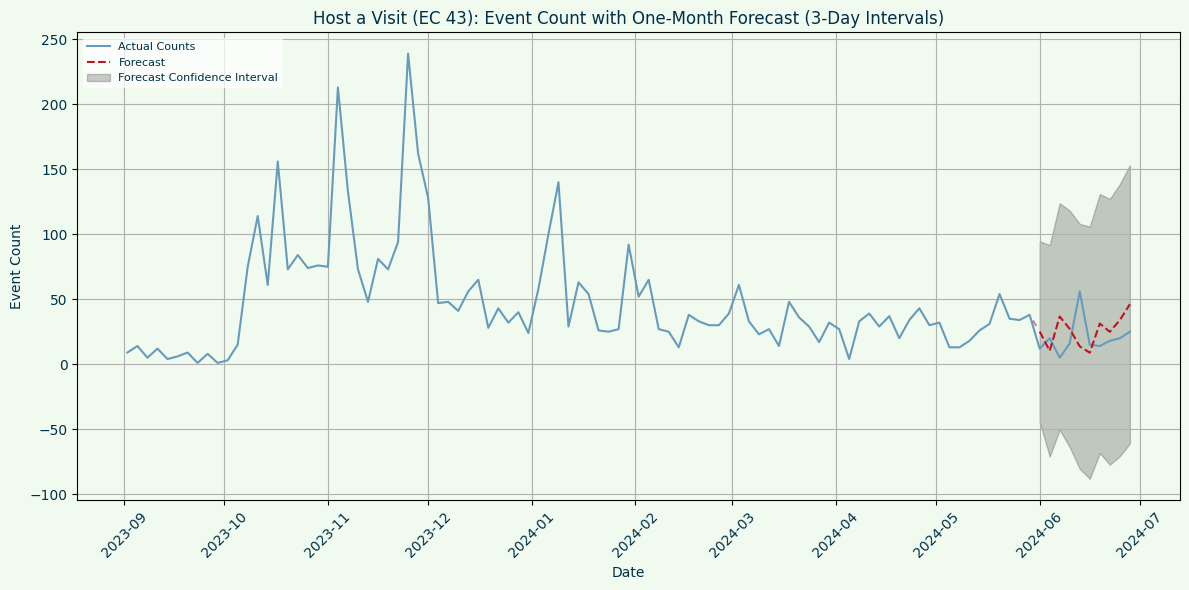

/root/.ipykernel/1162/command-1848653201928491-3598416523:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters foun

Event Code 51:
ADF Statistic: -4.818945
p-value: 0.000050
	1%: -3.504
	5%: -2.894
	10%: -2.584
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.15424D+00    |proj g|=  2.29671D-01

At iterate    5    f=  4.08409D+00    |proj g|=  9.85041D-02

At iterate   10    f=  4.04231D+00    |proj g|=  1.61368D-02

At iterate   15    f=  4.01474D+00    |proj g|=  1.34513D-02

At iterate   20    f=  4.00260D+00    |proj g|=  1.65198D-02

At iterate   25    f=  4.00220D+00    |proj g|=  2.80209D-03

At iterate   30    f=  4.00195D+00    |proj g|=  8.08271D-04

At iterate   35    f=  4.00190D+00    |proj g|=  2.68489D-04

At iterate   40    f=  4.00190D+00    |proj g|=  1.38288D-04

At iterate   45    f=  4.00190D+00    |proj g|=  2.79289D-05

At iterate   50    f=  4.00190D+00    |proj g|=  2.98694D-06

           * * *

Tit   = total number of iterations
Tn

/databricks/python/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/.ipykernel/1162/command-1848653201928491-3598416523:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


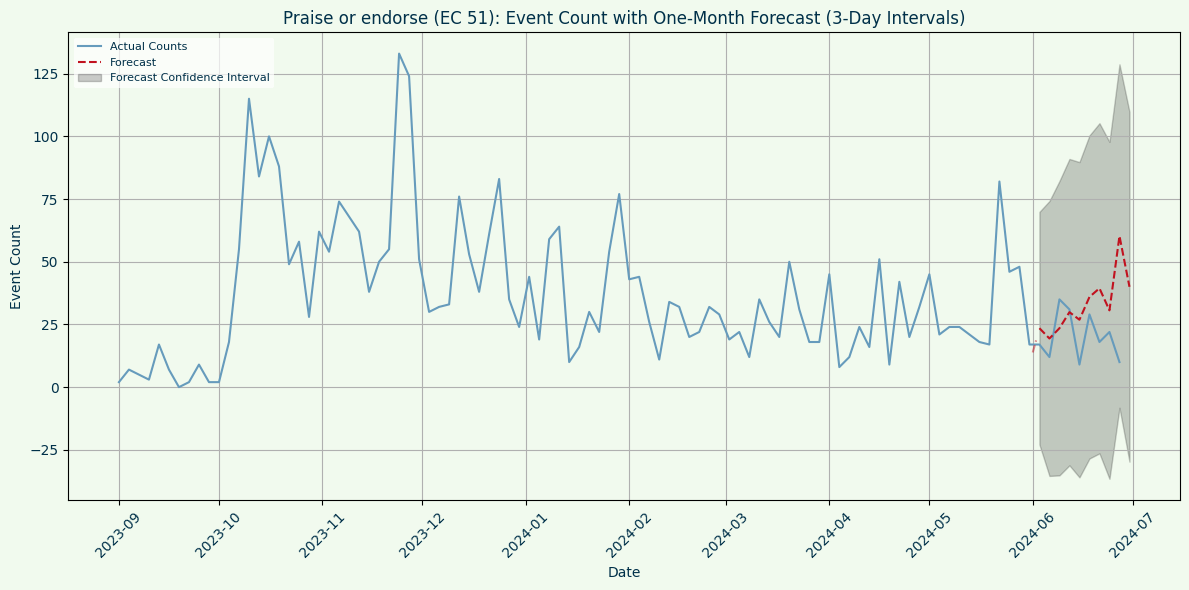

/root/.ipykernel/1162/command-1848653201928491-3598416523:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


Event Code 71:
ADF Statistic: -3.671664
p-value: 0.004530
	1%: -3.511
	5%: -2.897
	10%: -2.585
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.83246D+00    |proj g|=  9.42818D-02

At iterate    5    f=  3.77943D+00    |proj g|=  1.75292D-02

At iterate   10    f=  3.67648D+00    |proj g|=  3.64876D-02

At iterate   15    f=  3.67462D+00    |proj g|=  9.01572D-03

At iterate   20    f=  3.67359D+00    |proj g|=  6.85030D-03

At iterate   25    f=  3.67161D+00    |proj g|=  1.72231D-02

At iterate   30    f=  3.67060D+00    |proj g|=  1.27690D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected

/root/.ipykernel/1162/command-1848653201928491-3598416523:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


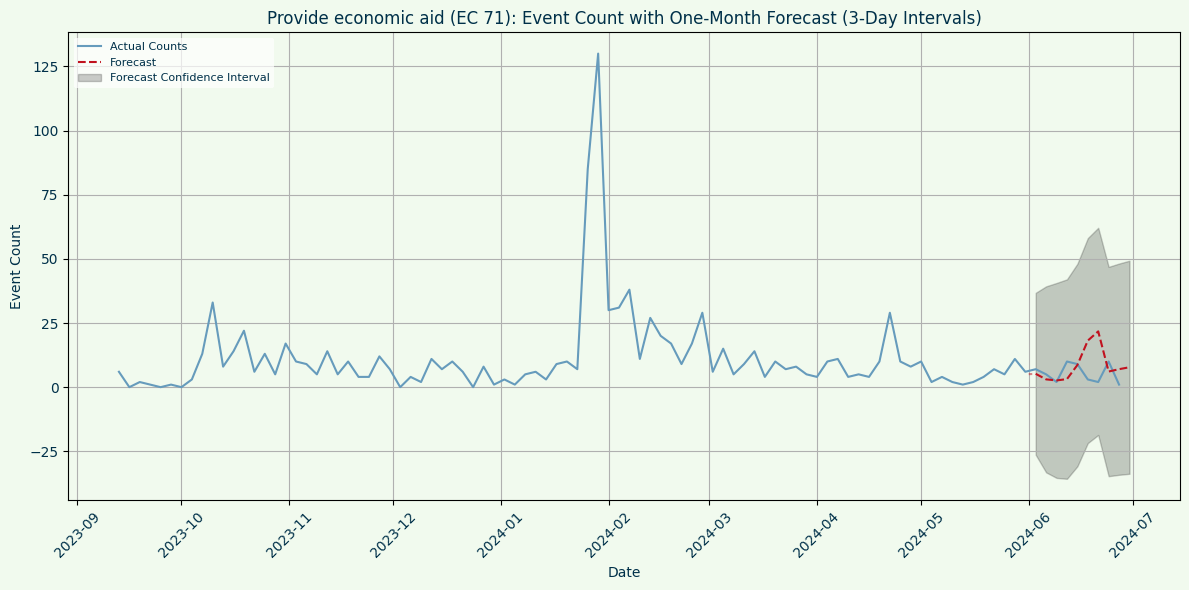

/root/.ipykernel/1162/command-1848653201928491-3598416523:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


Event Code 190:
ADF Statistic: -2.401095
p-value: 0.141428
	1%: -3.506
	5%: -2.895
	10%: -2.584
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.32488D+00    |proj g|=  8.99781D-02

At iterate    5    f=  5.29455D+00    |proj g|=  1.58274D-02

At iterate   10    f=  5.29376D+00    |proj g|=  5.86403D-03

At iterate   15    f=  5.26395D+00    |proj g|=  7.62059D-02

At iterate   20    f=  5.24298D+00    |proj g|=  1.58322D-03

At iterate   25    f=  5.24296D+00    |proj g|=  5.77848D-04

At iterate   30    f=  5.24292D+00    |proj g|=  1.23523D-03

At iterate   35    f=  5.24291D+00    |proj g|=  3.58940D-04

At iterate   40    f=  5.24290D+00    |proj g|=  1.39006D-04

At iterate   45    f=  5.24290D+00    |proj g|=  2.60218D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total numb

/root/.ipykernel/1162/command-1848653201928491-3598416523:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


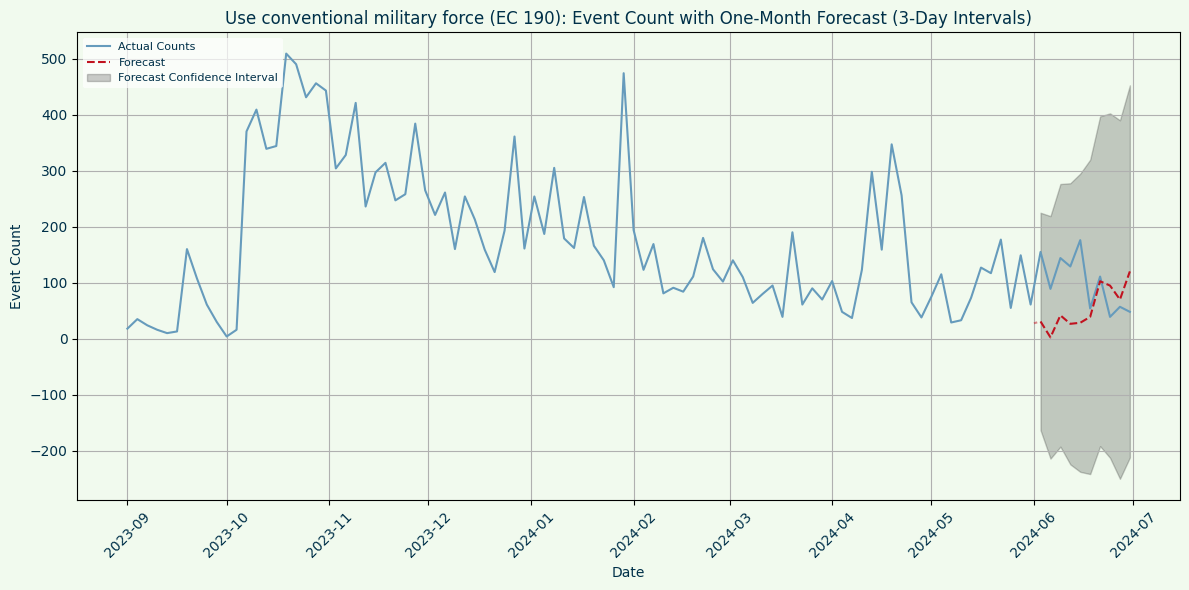

/root/.ipykernel/1162/command-1848653201928491-3598416523:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


Event Code 193:
ADF Statistic: -2.742645
p-value: 0.066945
	1%: -3.515
	5%: -2.898
	10%: -2.586
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.04884D+00    |proj g|=  3.67992D-02

At iterate    5    f=  4.01837D+00    |proj g|=  1.07448D-02

At iterate   10    f=  3.97138D+00    |proj g|=  9.84365D-02

At iterate   15    f=  3.95987D+00    |proj g|=  7.65126D-04

At iterate   20    f=  3.95987D+00    |proj g|=  4.13258D-04

At iterate   25    f=  3.95983D+00    |proj g|=  3.60399D-03

At iterate   30    f=  3.95979D+00    |proj g|=  9.01012D-04

At iterate   35    f=  3.95978D+00    |proj g|=  2.69730D-04

At iterate   40    f=  3.95978D+00    |proj g|=  5.21395D-05

At iterate   45    f=  3.95978D+00    |proj g|=  2.23003D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total numb

/root/.ipykernel/1162/command-1848653201928491-3598416523:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


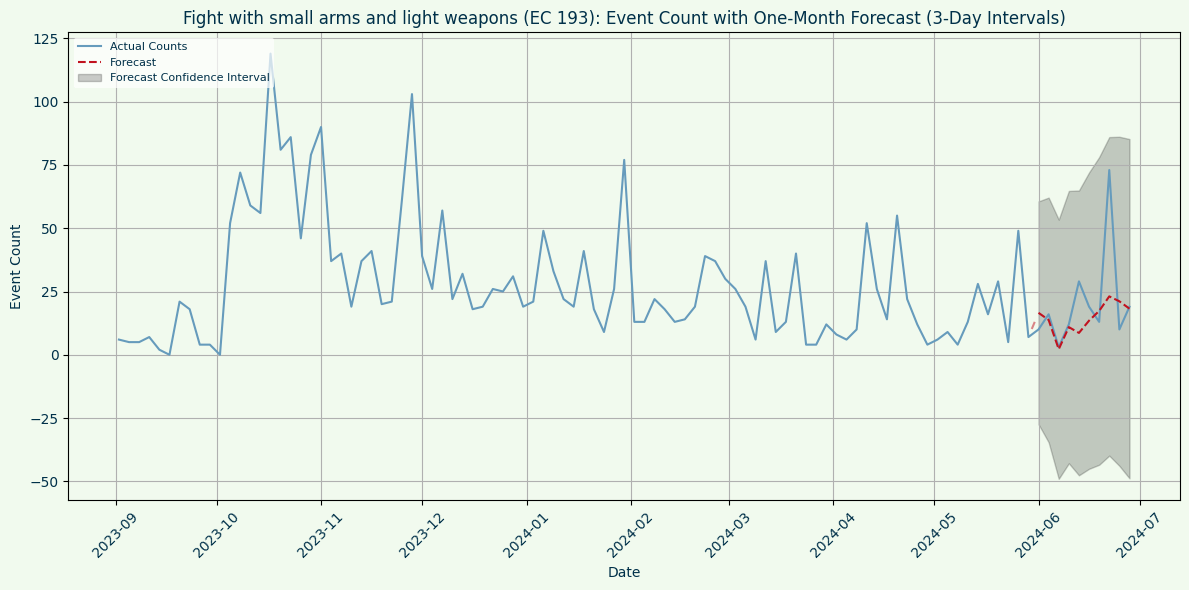

In [0]:
# Event codes, date range. event desc
event_codes = [42, 43, 51, 71, 190, 193]
start_date = '2023-09-01'
end_date = '2024-05-31'

# event codes dictionary
event_descriptions = {
    42: "Make a Visit",
    43: "Host a Visit",
    51: "Praise or endorse",
    71: "Provide economic aid",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons"
}

# Loop to generate plots
for event_code in event_codes:
    # Filter based on event code and date range
    filtered_data = df3[(df3['EventCode'] == event_code) &
                        (df3['SQLDATE'] >= start_date) &
                        (df3['SQLDATE'] <= end_date)]
    
    filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])

    # Aggregate data by date
    daily_counts = filtered_data.groupby('SQLDATE').size().reset_index(name='count')

    if daily_counts.empty:
        print(f"No data for EventCode {event_code} in the specified date range.")
        continue

    # Aggregate counts in 3-day intervals
    daily_counts.set_index('SQLDATE', inplace=True)
    interval_counts = daily_counts['count'].resample('3D').sum().reset_index()

    # Check stationarity
    print(f"Event Code {event_code}:")
    check_stationarity(interval_counts['count'])

    # Training
    train = interval_counts.set_index('SQLDATE')

    # Fit SARIMAX model
    model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    results = model.fit()

    # Forecast
    future_steps = 10  # Projecting for 10 intervals into the future (each interval is 3 days)
    forecast = results.get_forecast(steps=future_steps)
    forecast_ci = forecast.conf_int()

    # Creating future dates for the forecast starting right after the last actual date
    future_dates = pd.date_range(start=train.index[-1] + timedelta(days=3), periods=future_steps, freq='3D')

    # Extract the forecasted mean
    forecast_mean = forecast.predicted_mean
    forecast_mean.index = future_dates

    # Interpolate to avoid the gap
    last_actual = train.iloc[-1]
    interpolated = pd.DataFrame({'count': np.linspace(last_actual['count'], forecast_mean.iloc[0], 4)[1:-1]}, 
                                index=pd.date_range(start=train.index[-1] + timedelta(days=1), periods=2, freq='1D'))

    # Combine actual data, interpolated points, and forecasted data
    combined_forecast = pd.concat([train, interpolated, forecast_mean], axis=0)

    # Actual data until 31 Dec 2023
    actual_data = df3[(df3['EventCode'] == event_code) & 
                      (df3['SQLDATE'] >= start_date) & 
                      (df3['SQLDATE'] <= '2024-06-30')]

    actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])
    actual_daily_counts = actual_data.groupby('SQLDATE').size().reset_index(name='count')
    actual_daily_counts.set_index('SQLDATE', inplace=True)
    actual_interval_counts = actual_daily_counts['count'].resample('3D').sum().reset_index()

    # Plot the actual data until 30 July 2022
    plt.figure(figsize=(12, 6))
    plt.plot(actual_interval_counts['SQLDATE'], actual_interval_counts['count'], color='#669BBC', label='Actual Counts')
    plt.plot(forecast_mean.index, forecast_mean, linestyle='--', color='#C1121F', label='Forecast') # forecast
    plt.plot(interpolated.index, interpolated['count'], linestyle='--', color='#C1121F', alpha=0.5) # interpolation
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.2, label='Forecast Confidence Interval') # confidence interval

    # Add vertical lines and descriptions for special dates
    #for date, desc in zip(special_dates, descriptions):
    #    plt.axvline(pd.to_datetime(date), color='#780000', linestyle='--')
    #    plt.text(pd.to_datetime(date), actual_interval_counts['count'].max() * 0.9, desc, rotation=90, verticalalignment='center', horizontalalignment='right', color='#780000', fontsize=8, bbox=dict(facecolor='white', alpha=0.7)) #0.6 + alignment right to have clear descriptions

    plt.xlabel('Date', color='#003049')
    plt.ylabel('Event Count', color='#003049')
    title = event_descriptions.get(event_code, f"Event Code {event_code}")
    plt.title(f'{title} (EC {event_code}): Event Count with One-Month Forecast (3-Day Intervals)', color='#003049')
    plt.legend(facecolor='white', framealpha=0.7, edgecolor='none', fontsize=8, loc='upper left', labelcolor='#003049')
    plt.grid(True)
    plt.xticks(rotation=45, color='#003049')
    plt.yticks(color='#003049')
    plt.gca().set_facecolor('#F1FAEE') #background color 
    plt.gcf().set_facecolor('#F1FAEE') #background color
    plt.tight_layout()

    # Display the plot
    plt.show()


SAME FORECASTING AS DF3 - FOR DF2 (GAZAFULL.CSV)

Preparing Data for Actor and Mapping Visualisations

In [0]:
# Filter by IsRootEvent == 1
df4 = df3[df3['IsRootEvent'] == 1]
root_values = df4["IsRootEvent"].unique() #verify that df4 has only root event 1
print(root_values)

# Create a new column "ImportanceScore" using "NumMentions", "NumArticles", "NumSources" Average
df4['ImportanceScore'] = df4[['NumMentions', 'NumArticles', 'NumSources']].mean(axis=1)
df4.info()

[1]
<class 'pandas.core.frame.DataFrame'>
Int64Index: 28439 entries, 1 to 87168
Data columns (total 59 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GLOBALEVENTID          28439 non-null  int64  
 1   SQLDATE                28439 non-null  object 
 2   Actor1Code             27759 non-null  object 
 3   Actor1Name             27759 non-null  object 
 4   Actor1CountryCode      23011 non-null  object 
 5   Actor1KnownGroupCode   690 non-null    object 
 6   Actor1EthnicCode       17 non-null     object 
 7   Actor1Religion1Code    282 non-null    object 
 8   Actor1Religion2Code    27 non-null     object 
 9   Actor1Type1Code        9679 non-null   object 
 10  Actor1Type2Code        962 non-null    object 
 11  Actor1Type3Code        20 non-null     object 
 12  Actor2Code             26496 non-null  object 
 13  Actor2Name             26496 non-null  object 
 14  Actor2CountryCode      21535 non-null  object 
 15

/root/.ipykernel/1467/command-3199079478707784-4133484981:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['ImportanceScore'] = df4[['NumMentions', 'NumArticles', 'NumSources']].mean(axis=1)


In [0]:
# select only Dec data

# Convert the Date column to datetime
df4['SQLDATE'] = pd.to_datetime(df4['SQLDATE'], format='%Y-%m-%d')

# Filter the data for Jan 2024
df5 = df4[(df4['SQLDATE'].dt.year == 2024) & (df4['SQLDATE'].dt.month == 1)]

df5.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3501 entries, 45581 to 61657
Data columns (total 59 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   GLOBALEVENTID          3501 non-null   int64         
 1   SQLDATE                3501 non-null   datetime64[ns]
 2   Actor1Code             3399 non-null   object        
 3   Actor1Name             3399 non-null   object        
 4   Actor1CountryCode      2894 non-null   object        
 5   Actor1KnownGroupCode   61 non-null     object        
 6   Actor1EthnicCode       3 non-null      object        
 7   Actor1Religion1Code    20 non-null     object        
 8   Actor1Religion2Code    0 non-null      object        
 9   Actor1Type1Code        1140 non-null   object        
 10  Actor1Type2Code        67 non-null     object        
 11  Actor1Type3Code        3 non-null      object        
 12  Actor2Code             3264 non-null   object        
 13

/root/.ipykernel/1467/command-3199079478707785-3399864058:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['SQLDATE'] = pd.to_datetime(df4['SQLDATE'], format='%Y-%m-%d')


### Visualising Actors
1. Top 5 Actors According to QuadClass


/root/.ipykernel/1162/command-2714981194622968-1633226593:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['SQLDATE'] = pd.to_datetime(df5['SQLDATE'], format='%Y-%m-%d')


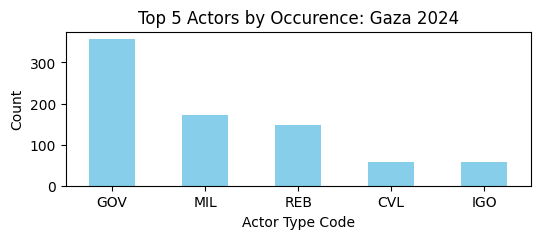

In [0]:
# Identify Top 5 Actors in Actor1Type1Code column and plot a barchart
# Count occurrences of each actor code
df5['SQLDATE'] = pd.to_datetime(df5['SQLDATE'], format='%Y-%m-%d')
actor_counts = df5['Actor1Type1Code'].value_counts()
top_5_actors = actor_counts.head(5)

# Plot
plt.figure(figsize=(6, 2))
top_5_actors.plot(kind='bar', color='skyblue')
plt.title('Top 5 Actors by Occurence: Gaza 2024')
plt.xlabel('Actor Type Code')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [0]:
top_5_actors

GOV    357
MIL    172
REB    147
CVL     57
IGO     57
Name: Actor1Type1Code, dtype: int64

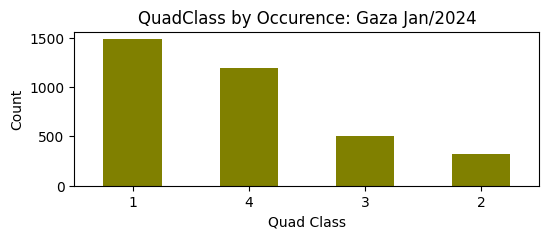

In [0]:
# Identify QuadClass counts plot a barchart
# Count occurrences of each actor code
QuadClass_counts = df5['QuadClass'].value_counts()

# Plot
plt.figure(figsize=(6, 2))
QuadClass_counts.plot(kind='bar', color='olive')
plt.title('QuadClass by Occurence: Gaza Jan/2024')
plt.xlabel('Quad Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [0]:
QuadClass_counts

1    1485
4    1193
3     506
2     317
Name: QuadClass, dtype: int64

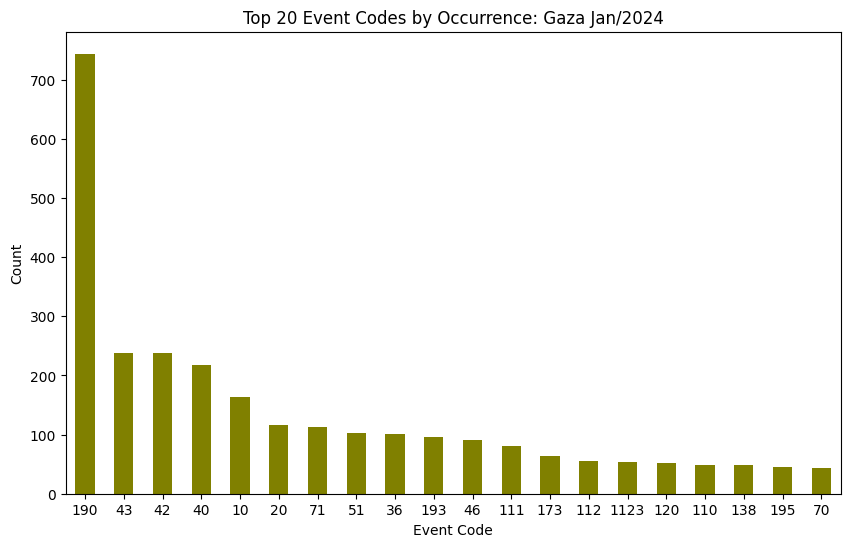

In [0]:
# Plot the top 20 event codes

event_counts = df5['EventCode'].value_counts()
top_20_event_counts = event_counts.head(20)

# Plot
plt.figure(figsize=(10, 6))
top_20_event_counts.plot(kind='bar', color='olive')
plt.title('Top 20 Event Codes by Occurrence: Gaza Jan/2024')
plt.xlabel('Event Code')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 190 Use conventional military force

Create Bar Graph of Top 5 Actors and Proportion of QuadCalss for 4 Months: December 2023, and January, March, June 2024

/root/.ipykernel/1467/command-103233508698214-1197630327:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['SQLDATE'] = pd.to_datetime(df4['SQLDATE'], format='%Y-%m-%d')


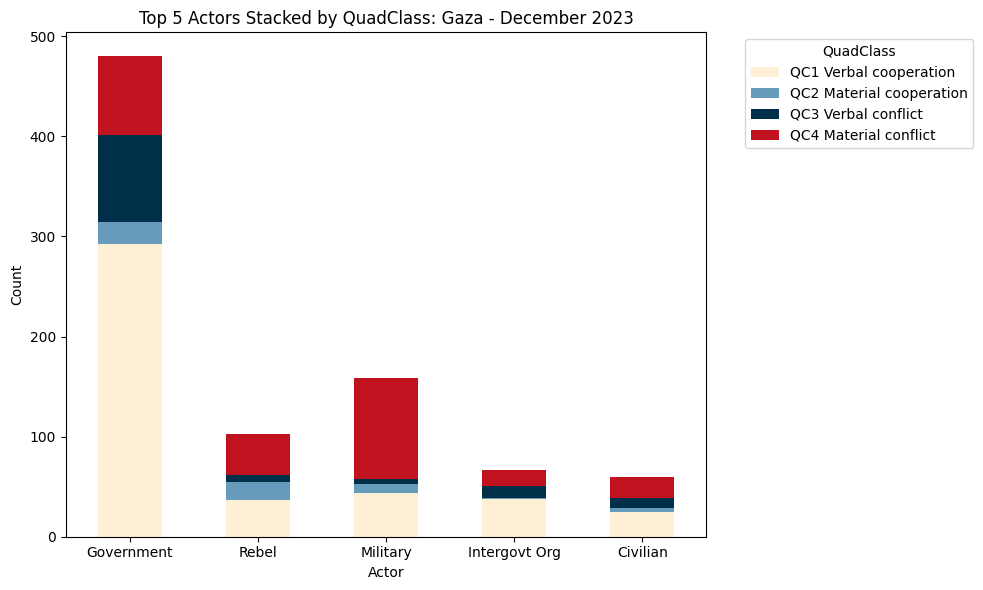

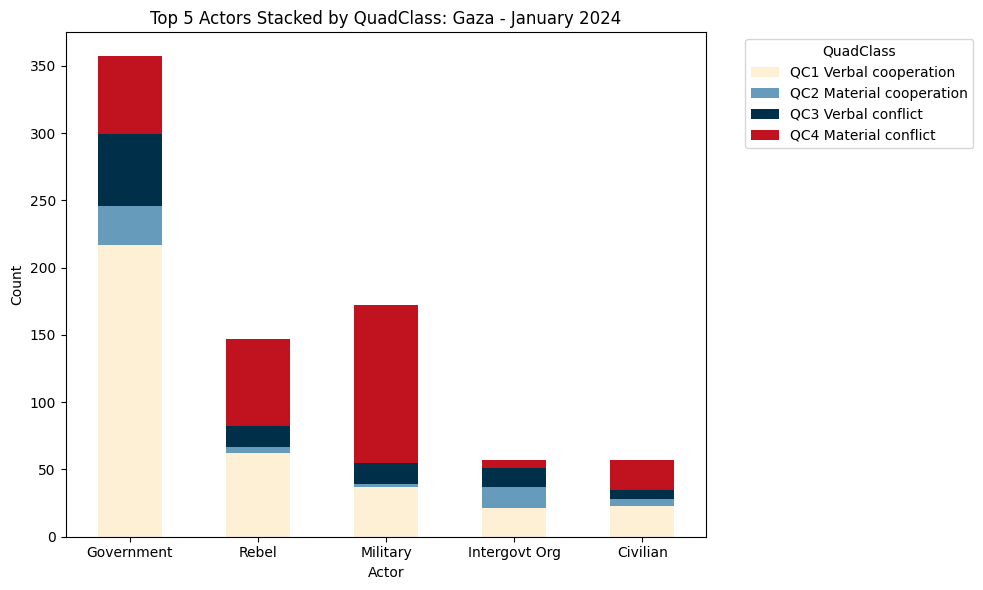

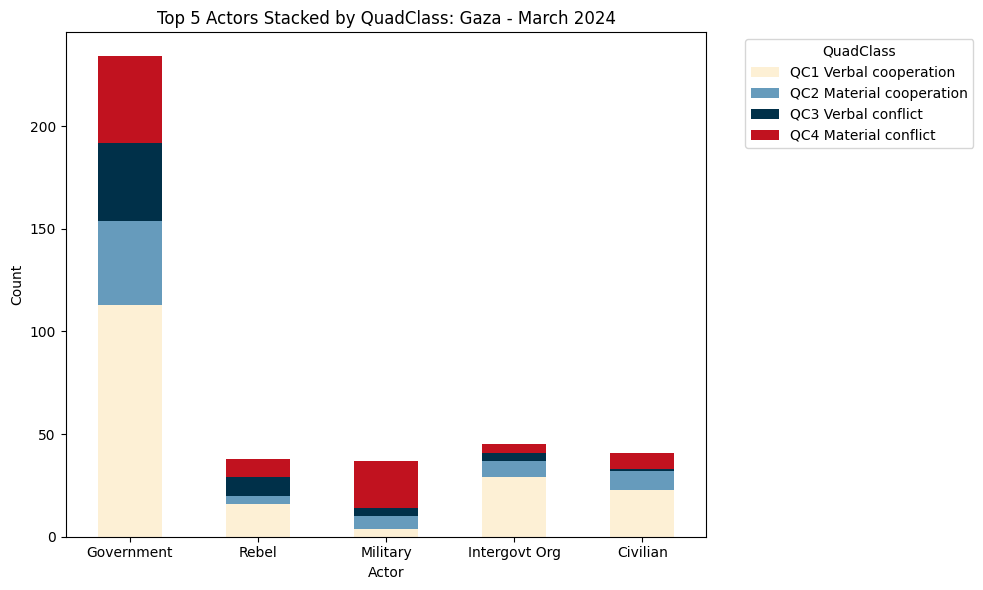

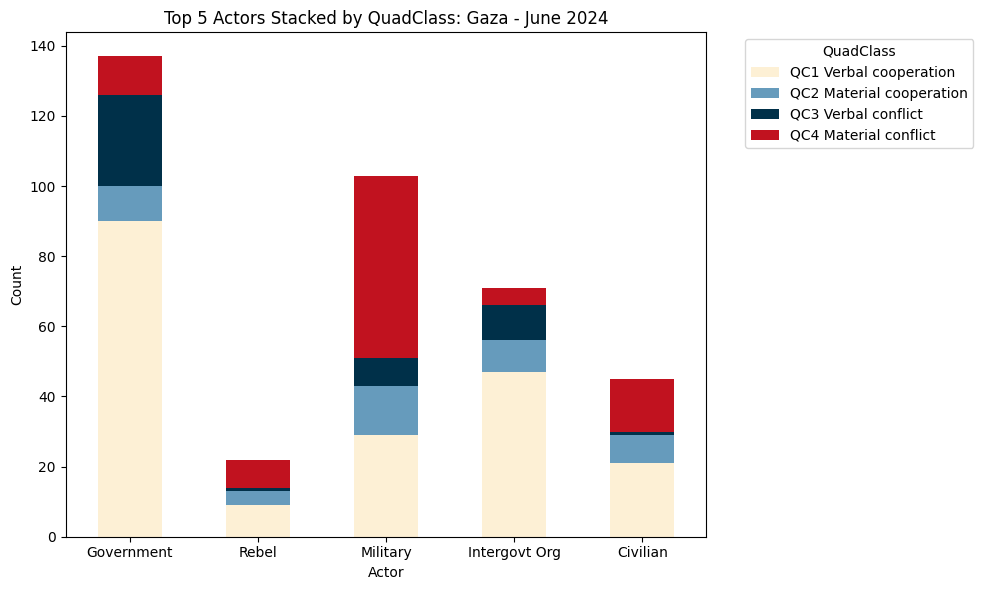

In [0]:
# Convert the Date column to datetime
df4['SQLDATE'] = pd.to_datetime(df4['SQLDATE'], format='%Y-%m-%d')

# Define the months you want to visualize
months = ['2023-10', '2023-12', '2024-01', '2024-03', '2024-06']

# Define the top 5 actors and their corresponding labels
top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']
labels = ['Government', 'Rebel', 'Military', 'Intergovt Org', 'Civilian']

for month in months:
    # Extract year and month
    year, month_num = map(int, month.split('-'))
    
    # Get month name
    month_name = calendar.month_name[month_num]
    
    # Filter the data for the current month
    filtered_df = df4[(df4['SQLDATE'].dt.year == year) & (df4['SQLDATE'].dt.month == month_num)]
    
    # Filter the data to include only the top 5 actors
    filtered_df = filtered_df[filtered_df['Actor1Type1Code'].isin(top_5_actors)]
    
    # Group by Actor1Type1Code and QuadClass and count occurrences
    grouped = filtered_df.groupby(['Actor1Type1Code', 'QuadClass']).size().unstack(fill_value=0)
    grouped = grouped.loc[top_5_actors]

    # Plot
    ax = grouped.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#fdf0d5', '#669bbc', '#003049', '#c1121f'])
    ax.set_xticklabels(labels)
    
    # Set title, labels, and legend
    plt.title(f'Top 5 Actors Stacked by QuadClass: Gaza - {month_name} {year}')
    plt.xlabel('Actor')
    plt.ylabel('Count')
    
    # Custom legend labels
    quad_class_labels = ['QC1 Verbal cooperation', 'QC2 Material cooperation', 'QC3 Verbal conflict', 'QC4 Material conflict']
    ax.legend(quad_class_labels, title='QuadClass', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


/root/.ipykernel/1467/command-103233508698216-2327698668:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['SQLDATE'] = pd.to_datetime(df4['SQLDATE'], format='%Y-%m-%d')


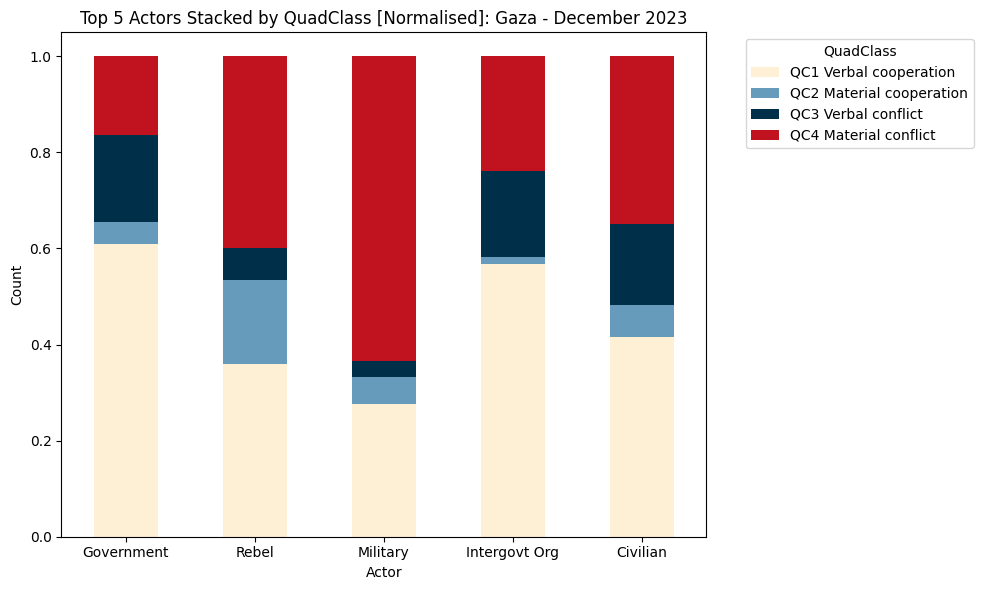

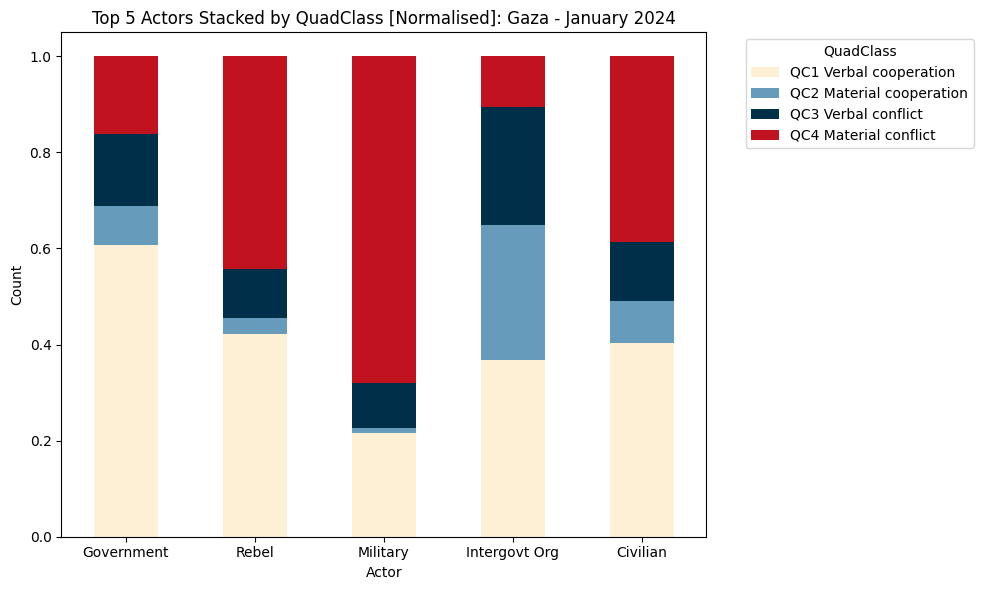

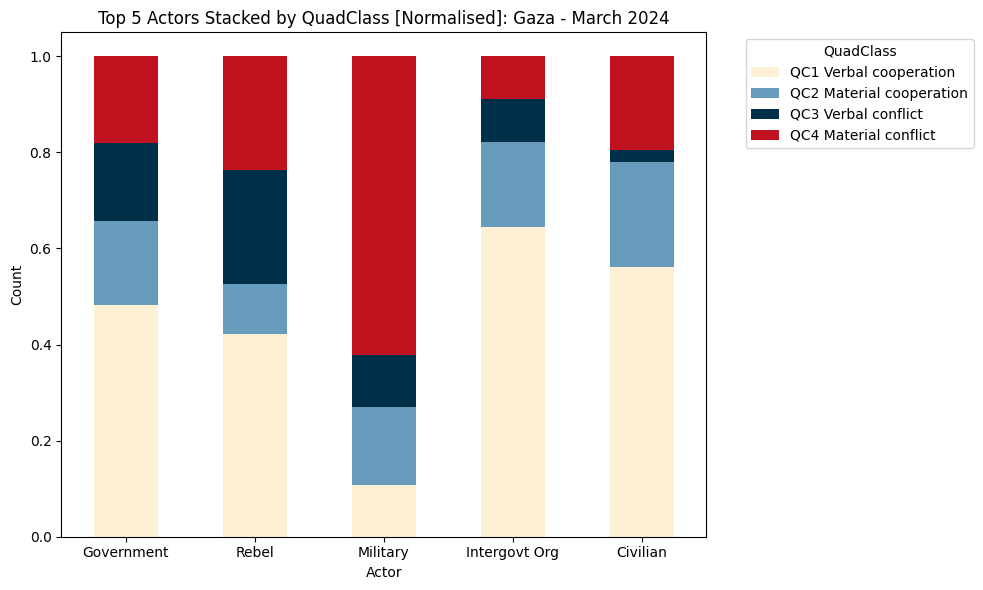

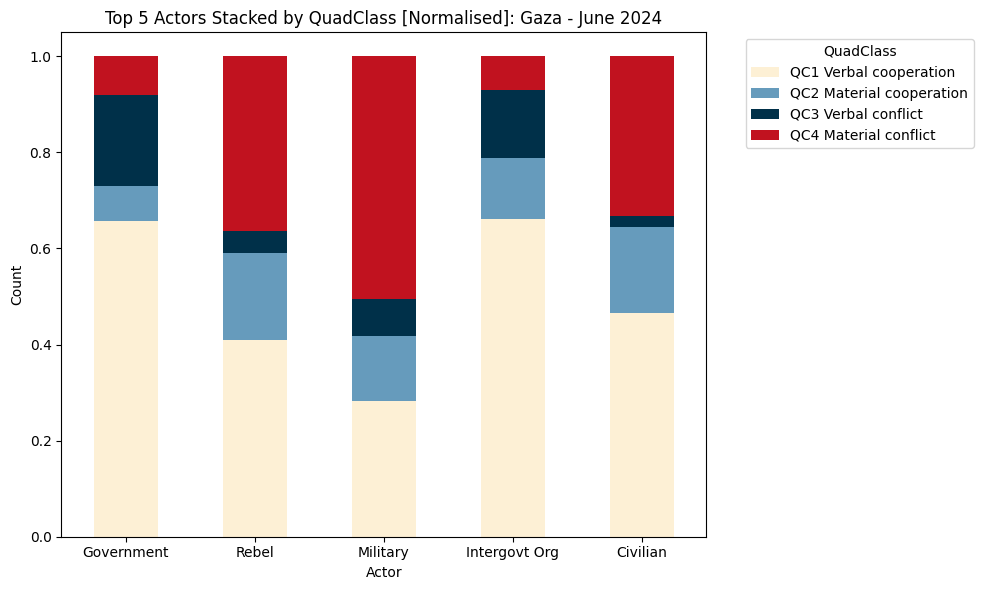

In [0]:
# Convert the Date column to datetime
df4['SQLDATE'] = pd.to_datetime(df4['SQLDATE'], format='%Y-%m-%d')

# Define the months you want to visualize
months = ['2023-12', '2024-01', '2024-03', '2024-06']

# Define the top 5 actors and their corresponding labels
top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']
labels = ['Government', 'Rebel', 'Military', 'Intergovt Org', 'Civilian']

for month in months:
    # Extract year and month
    year, month_num = map(int, month.split('-'))
    
    # Get month name
    month_name = calendar.month_name[month_num]
    
    # Filter the data for the current month
    filtered_df = df4[(df4['SQLDATE'].dt.year == year) & (df4['SQLDATE'].dt.month == month_num)]
    
    # Filter the data to include only the top 5 actors
    filtered_df = filtered_df[filtered_df['Actor1Type1Code'].isin(top_5_actors)]
    
    # Group by Actor1Type1Code and QuadClass and count occurrences
    grouped = filtered_df.groupby(['Actor1Type1Code', 'QuadClass']).size().unstack(fill_value=0)
    grouped = grouped.loc[top_5_actors]

    # Normalize values (divide by total count for each actor)
    normalized_grouped = grouped.div(grouped.sum(axis=1), axis=0)

    # Plot
    ax = normalized_grouped.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#fdf0d5', '#669bbc', '#003049', '#c1121f'])
    ax.set_xticklabels(labels)
    
    # Set title, labels, and legend
    plt.title(f'Top 5 Actors Stacked by QuadClass [Normalised]: Gaza - {month_name} {year}')
    plt.xlabel('Actor')
    plt.ylabel('Count')
    
    # Custom legend labels
    quad_class_labels = ['QC1 Verbal cooperation', 'QC2 Material cooperation', 'QC3 Verbal conflict', 'QC4 Material conflict']
    ax.legend(quad_class_labels, title='QuadClass', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


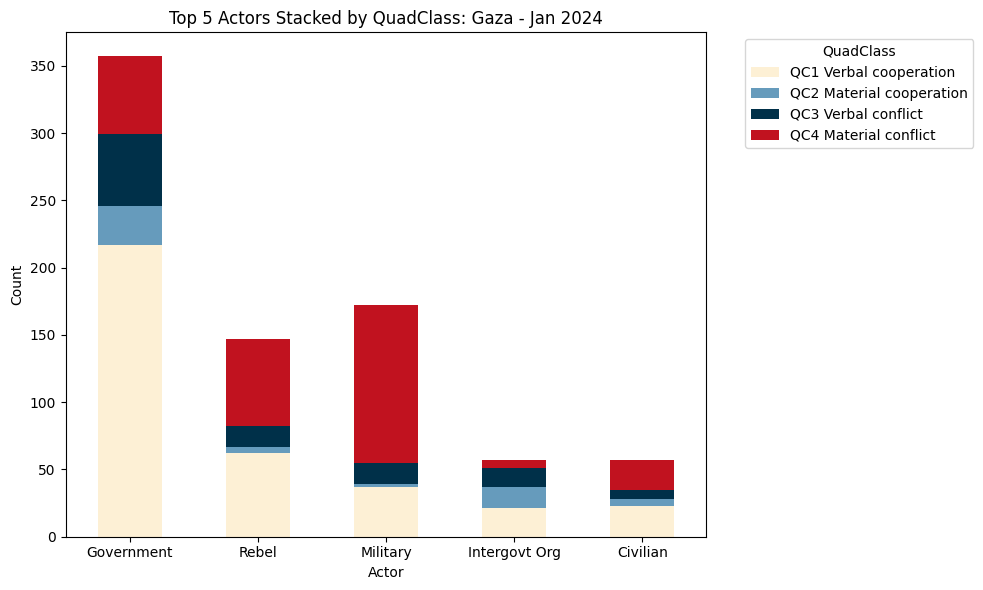

In [0]:

top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']
labels = ['Government', 'Rebel', 'Military', 'Intergovt Org', 'Civilian']

filtered_df = df5[df5['Actor1Type1Code'].isin(top_5_actors)]

# Group by Actor1Type1Code and QuadClass and count occurrences
grouped = filtered_df.groupby(['Actor1Type1Code', 'QuadClass']).size().unstack(fill_value=0)
grouped = grouped.loc[top_5_actors]

# Plot
ax = grouped.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#fdf0d5', '#669bbc', '#003049', '#c1121f'])
ax.set_xticklabels(labels)

plt.title('Top 5 Actors Stacked by QuadClass: Gaza - Jan 2024')
plt.xlabel('Actor')
plt.ylabel('Count')

# Custom legend labels
quad_class_labels = ['QC1 Verbal cooperation', 'QC2 Material cooperation', 'QC3 Verbal conflict', 'QC4 Material conflict']
ax.legend(quad_class_labels, title='QuadClass', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

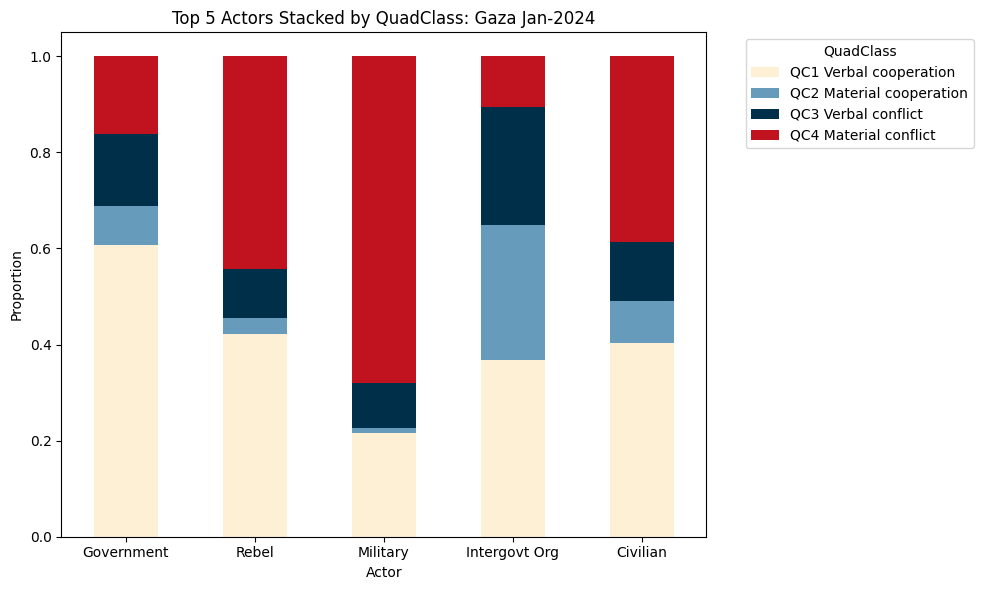

In [0]:
# normalize values [divide by total count for each actor]
normalized_grouped = grouped.div(grouped.sum(axis=1), axis=0)

# Plot
ax = normalized_grouped.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#fdf0d5', '#669bbc', '#003049', '#c1121f'])
ax.set_xticklabels(labels)

plt.title('Top 5 Actors Stacked by QuadClass: Gaza Jan-2024')
plt.xlabel('Actor')
plt.ylabel('Proportion')

# Custom legend labels
quad_class_labels = ['QC1 Verbal cooperation', 'QC2 Material cooperation', 'QC3 Verbal conflict', 'QC4 Material conflict']
ax.legend(quad_class_labels, title='QuadClass', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Visualisation of Top 5 Actors based on Event Base Code

/root/.ipykernel/14098/command-2714981194622976-3220697811:13: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]


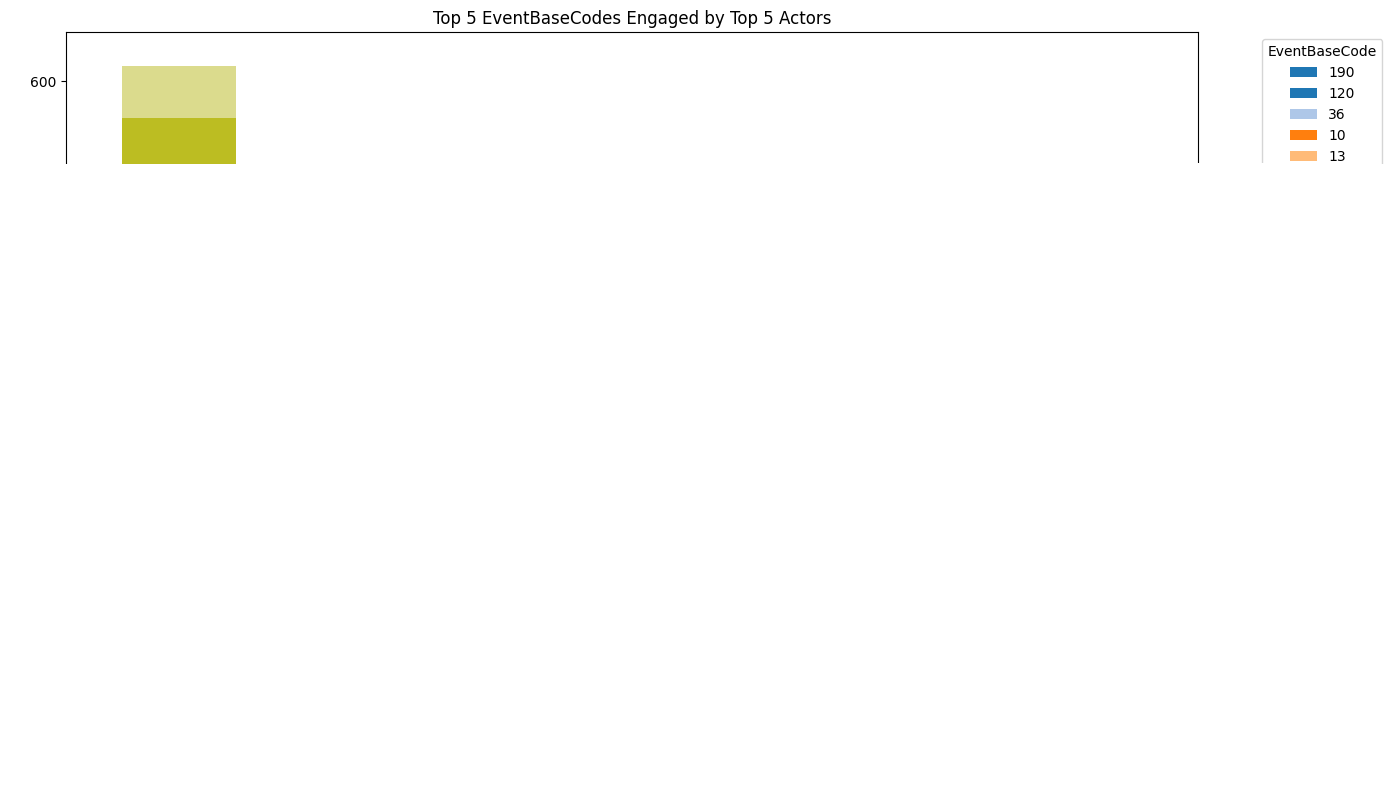

In [0]:
top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']

# Step 2: Filter the DataFrame for top 5 actors
filtered_df = df5[df5['Actor1Type1Code'].isin(top_5_actors)]

# Step 3: Count occurrences of each EventBaseCode for each Actor
event_counts = filtered_df.groupby(['Actor1Type1Code', 'EventCode']).size().unstack(fill_value=0)

# Step 4: Identify the top 5 EventBaseCodes for each actor
top_event_codes = event_counts.apply(lambda x: x.nlargest(5).index.tolist(), axis=1)

# Create a list of tuples for easier plotting
actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]

# Filter the original dataframe for these top events
filtered_events_df = filtered_df[filtered_df.apply(lambda x: (x['Actor1Type1Code'], x['EventBaseCode']) in actor_event_pairs, axis=1)]

# Count occurrences again for the filtered dataframe
final_event_counts = filtered_events_df.groupby(['Actor1Type1Code', 'EventBaseCode']).size().unstack(fill_value=0)

# Ensure we only have the top event codes for each actor
final_event_counts = final_event_counts.loc[top_5_actors, [event for sublist in top_event_codes for event in sublist if event in final_event_counts.columns]].fillna(0)

# Plotting
final_event_counts.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

plt.title('Top 5 EventBaseCodes Engaged by Top 5 Actors')
plt.xlabel('Actor Type Code')
plt.ylabel('Count')
plt.legend(title='EventBaseCode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/root/.ipykernel/1955/command-2469931752870581-975474763:14: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]


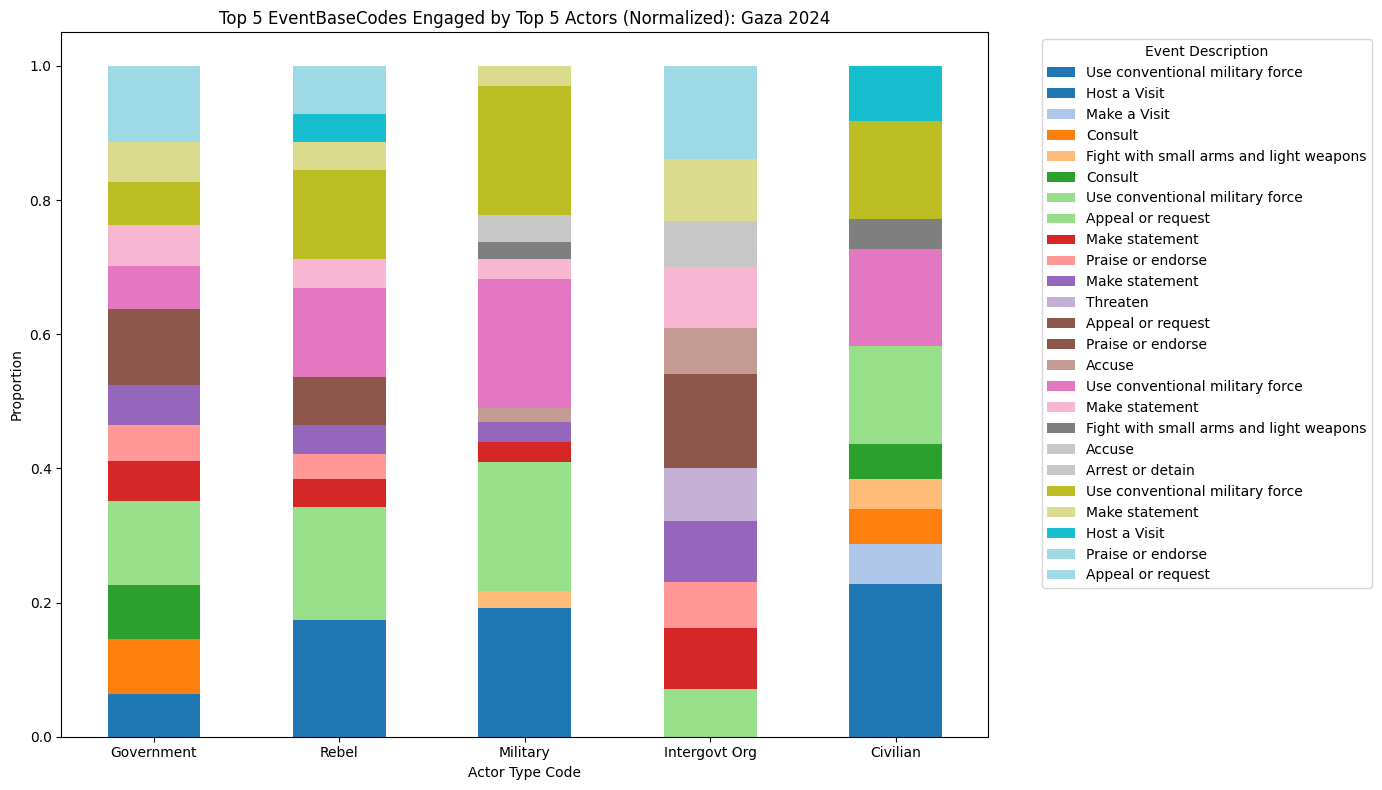

In [0]:
top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']
labels = ['Government', 'Rebel', 'Military', 'Intergovt Org', 'Civilian']

# Step 2: Filter the DataFrame for top 5 actors
filtered_df = df3[df3['Actor1Type1Code'].isin(top_5_actors)]

# Step 3: Count occurrences of each EventBaseCode for each Actor
event_counts = filtered_df.groupby(['Actor1Type1Code', 'EventBaseCode']).size().unstack(fill_value=0)

# Step 4: Identify the top 5 EventBaseCodes for each actor
top_event_codes = event_counts.apply(lambda x: x.nlargest(5).index.tolist(), axis=1)

# Create a list of tuples for easier plotting
actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]

# Filter the original dataframe for these top events
filtered_events_df = filtered_df[filtered_df.apply(lambda x: (x['Actor1Type1Code'], x['EventBaseCode']) in actor_event_pairs, axis=1)]

# Count occurrences again for the filtered dataframe
final_event_counts = filtered_events_df.groupby(['Actor1Type1Code', 'EventBaseCode']).size().unstack(fill_value=0)

# Ensure we only have the top event codes for each actor
final_event_counts = final_event_counts.loc[top_5_actors, [event for sublist in top_event_codes for event in sublist]].fillna(0)

# Normalize the values by dividing by the total count for each actor
normalized_final_event_counts = final_event_counts.div(final_event_counts.sum(axis=1), axis=0)

# Plotting
ax = normalized_final_event_counts.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
ax.set_xticklabels(labels)

plt.title('Top 5 EventBaseCodes Engaged by Top 5 Actors (Normalized): Gaza 2024')
plt.xlabel('Actor Type Code')
plt.ylabel('Proportion')

# Custom legend labels using event_descriptions dictionary
event_descriptions = {
    10: "Make statement",
    12: "Make pessimistic comment",
    20: "Appeal or request",
    36: "Express intent to meet/negotiate", #LK
    40: "Consult",
    42: "Make a Visit",
    43: "Host a Visit",
    46: "Engage in Negotiation",
    51: "Praise or endorse",
    57: "Sign formal agreement", #LK
    60: "Engage in material cooperation", #lk
    71: "Provide economic aid", #lk
    80: "Yield", #lk
    83: "Accede to requests/demands for political reform",
    100: "Demand",
    110: "Disapprove",
    112: "Accuse",
    120: "Reject",
    130: "Threaten",
    141: "Demonstrate or rally",
    145: "Protest violently, riot",
    172: "Impose administrative sanctions",
    173: "Arrest or detain",
    175: "Use tactics of violent repression",
    180: "Use conventional violence",
    182: "Physically assault",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons",
    332: "Express intent to provide military aid",
    1723: "Impose curfew"
}

# Create a list of custom labels for the legend
custom_labels = [event_descriptions[event] for event in final_event_counts.columns]

# Update the legend with custom labels
ax.legend(custom_labels, title='Event Description', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/root/.ipykernel/1152/command-1563568658144559-4009503753:17: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]


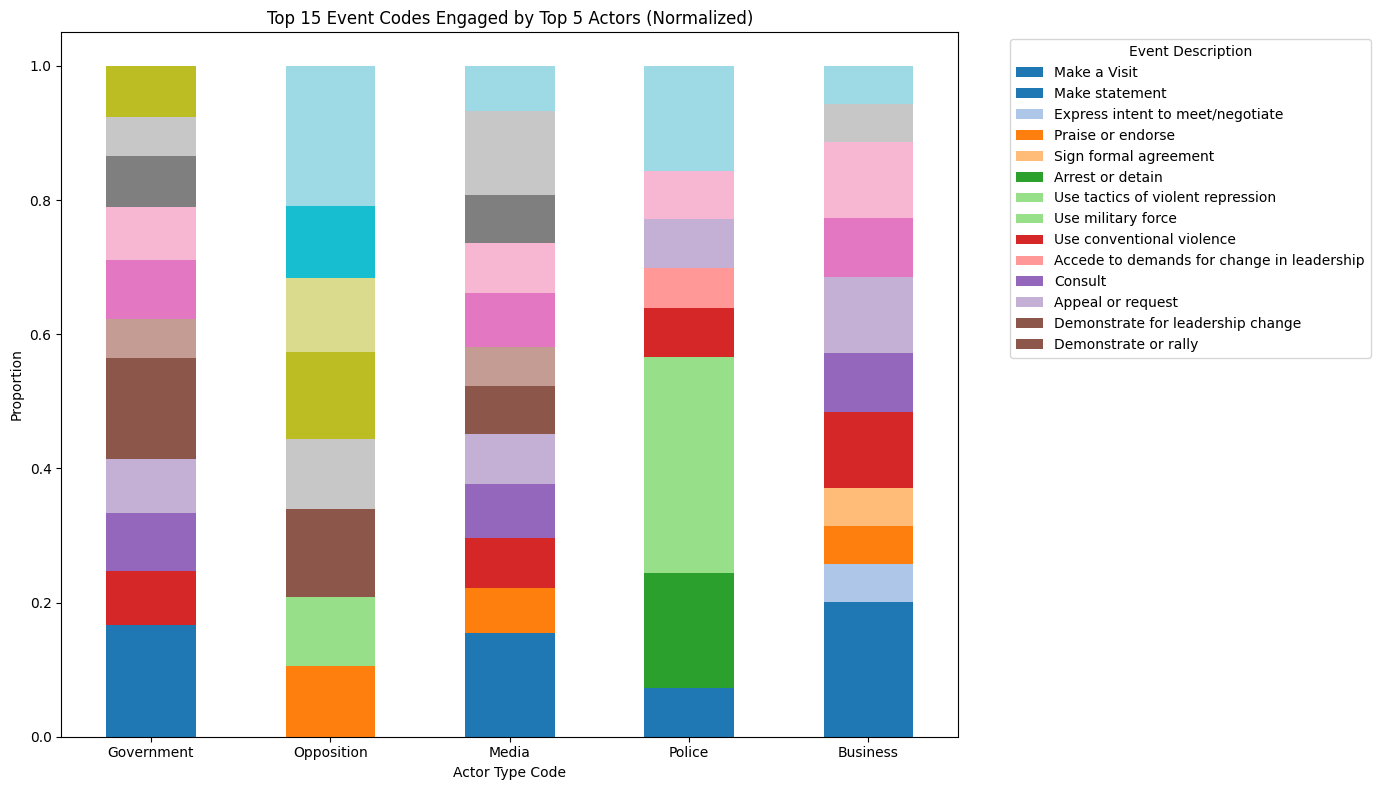

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

top_5_actors = ['GOV', 'OPP', 'MED', 'COP', 'BUS']
labels = ['Government', 'Opposition', 'Media', 'Police', 'Business']

# Step 2: Filter the DataFrame for top 5 actors
filtered_df = df5[df5['Actor1Type1Code'].isin(top_5_actors)]

# Step 3: Count occurrences of each EventCode for each Actor
event_counts = filtered_df.groupby(['Actor1Type1Code', 'EventCode']).size().unstack(fill_value=0)

# Top 15 EventCodes for each actor
top_event_codes = event_counts.apply(lambda x: x.nlargest(5).index.tolist(), axis=1)

# Create a list of tuples for easier plotting
actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]

# Filter the original dataframe for these top events
filtered_events_df = filtered_df[filtered_df.apply(lambda x: (x['Actor1Type1Code'], x['EventCode']) in actor_event_pairs, axis=1)]

# Count occurrences again for the filtered dataframe
final_event_counts = filtered_events_df.groupby(['Actor1Type1Code', 'EventCode']).size().unstack(fill_value=0)

# Ensure we only have the top event codes for each actor
final_event_counts = final_event_counts.loc[top_5_actors, [event for sublist in top_event_codes for event in sublist if event in final_event_counts.columns]].fillna(0)

# Normalize the values by dividing by the total count for each actor
normalized_final_event_counts = final_event_counts.div(final_event_counts.sum(axis=1), axis=0)

# Plotting
ax = normalized_final_event_counts.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
ax.set_xticklabels(labels)

plt.title('Top 15 Event Codes Engaged by Top 5 Actors (Normalized)')
plt.xlabel('Actor Type Code')
plt.ylabel('Proportion')

# Custom legend labels using event_descriptions dictionary
event_descriptions = {
    10: "Make statement",
    20: "Appeal or request",
    36: "Express intent to meet/negotiate",
    40: "Consult",
    42: "Make a Visit",
    51: "Praise or endorse",
    57: "Sign formal agreement",
    83: "Accede to requests/demands for political reform",
    141: "Demonstrate or rally",
    145: "Protest violently, riot",
    172: "Impose administrative sanctions",
    173: "Arrest or detain",
    175: "Use tactics of violent repression",
    180: "Use conventional violence",
    190: "Use military force",
    831: "Accede to demands for change in leadership",
    1411: "Demonstrate for leadership change"
}

# Create a list of custom labels for the legend, ensuring uniqueness
custom_labels = []
for event in final_event_counts.columns:
    desc = event_descriptions.get(event, f"Event Code {event}")
    if desc not in custom_labels:
        custom_labels.append(desc)

# Update the legend with custom labels
ax.legend(custom_labels, title='Event Description', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/root/.ipykernel/1642/command-1563568658144560-2367780569:17: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]


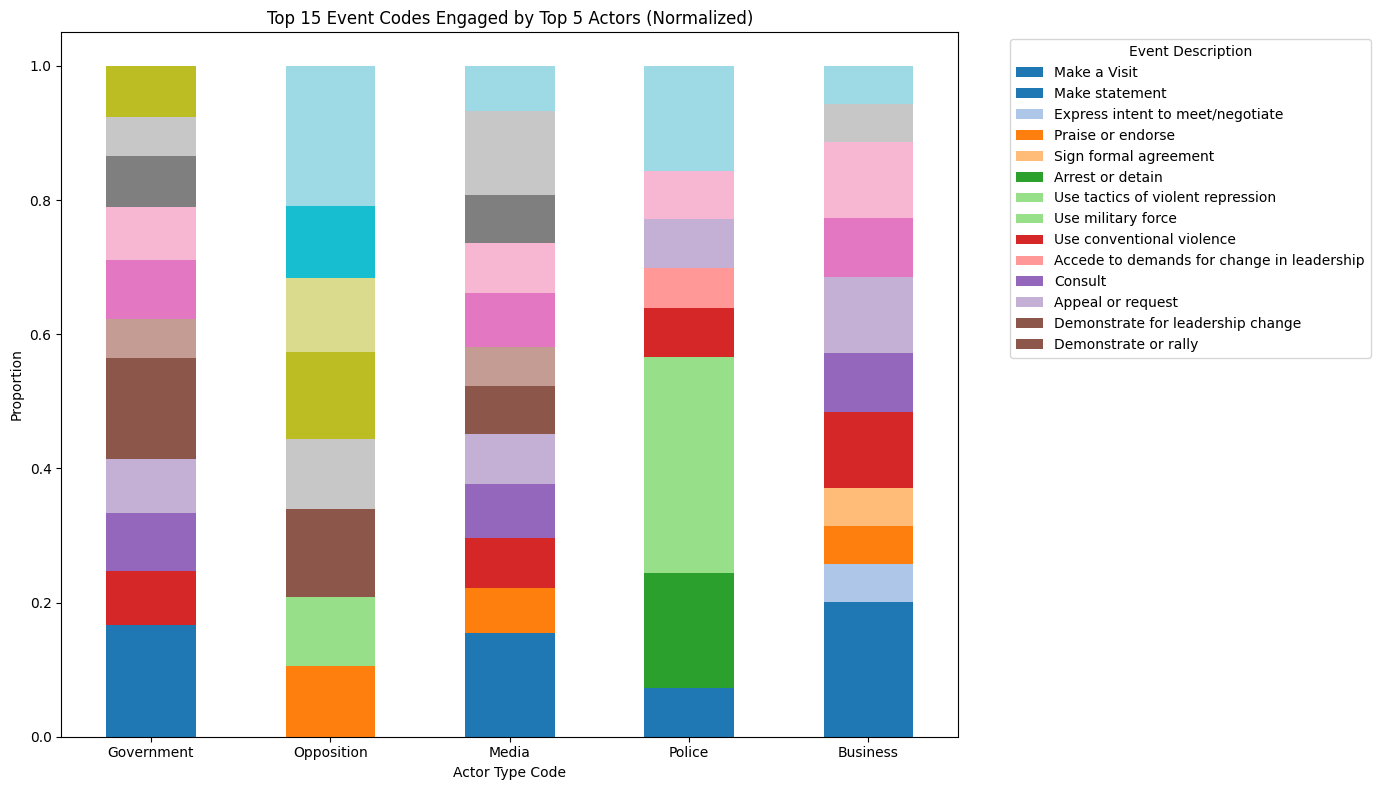

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

top_5_actors = ['GOV', 'OPP', 'MED', 'COP', 'BUS']
labels = ['Government', 'Opposition', 'Media', 'Police', 'Business']

# Step 1: Filter the DataFrame for top 5 actors
filtered_df = df5[df5['Actor1Type1Code'].isin(top_5_actors)]

# Step 2: Count occurrences of each EventCode for each Actor
event_counts = filtered_df.groupby(['Actor1Type1Code', 'EventCode']).size().unstack(fill_value=0)

# Step 3: Identify top 15 EventCodes for each actor
top_event_codes = event_counts.apply(lambda x: x.nlargest(5).index.tolist(), axis=1)

# Create a list of tuples for easier plotting
actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]

# Filter the original dataframe for these top events
filtered_events_df = filtered_df[filtered_df.apply(lambda x: (x['Actor1Type1Code'], x['EventCode']) in actor_event_pairs, axis=1)]

# Count occurrences again for the filtered dataframe
final_event_counts = filtered_events_df.groupby(['Actor1Type1Code', 'EventCode']).size().unstack(fill_value=0)

# Ensure we only have the top event codes for each actor
final_event_counts = final_event_counts.loc[top_5_actors, [event for sublist in top_event_codes for event in sublist if event in final_event_counts.columns]].fillna(0)

# Normalize the values by dividing by the total count for each actor
normalized_final_event_counts = final_event_counts.div(final_event_counts.sum(axis=1), axis=0)

# Plotting
ax = normalized_final_event_counts.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
ax.set_xticklabels(labels)

plt.title('Top 15 Event Codes Engaged by Top 5 Actors (Normalized)')
plt.xlabel('Actor Type Code')
plt.ylabel('Proportion')

# Custom legend labels using event_descriptions dictionary
event_descriptions = {
    10: "Make statement",
    20: "Appeal or request",
    36: "Express intent to meet/negotiate",
    40: "Consult",
    42: "Make a Visit",
    51: "Praise or endorse",
    57: "Sign formal agreement",
    83: "Accede to requests/demands for political reform",
    141: "Demonstrate or rally",
    145: "Protest violently, riot",
    172: "Impose administrative sanctions",
    173: "Arrest or detain",
    175: "Use tactics of violent repression",
    180: "Use conventional violence",
    190: "Use military force",
    831: "Accede to demands for change in leadership",
    1411: "Demonstrate for leadership change"
}

# Create a list of custom labels for the legend, ensuring uniqueness
custom_labels = []
for event in final_event_counts.columns:
    desc = event_descriptions.get(event, f"Event Code {event}")
    if desc not in custom_labels:
        custom_labels.append(desc)

# Update the legend with custom labels
ax.legend(custom_labels, title='Event Description', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/root/.ipykernel/1467/command-3199079478707799-10346499:14: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]


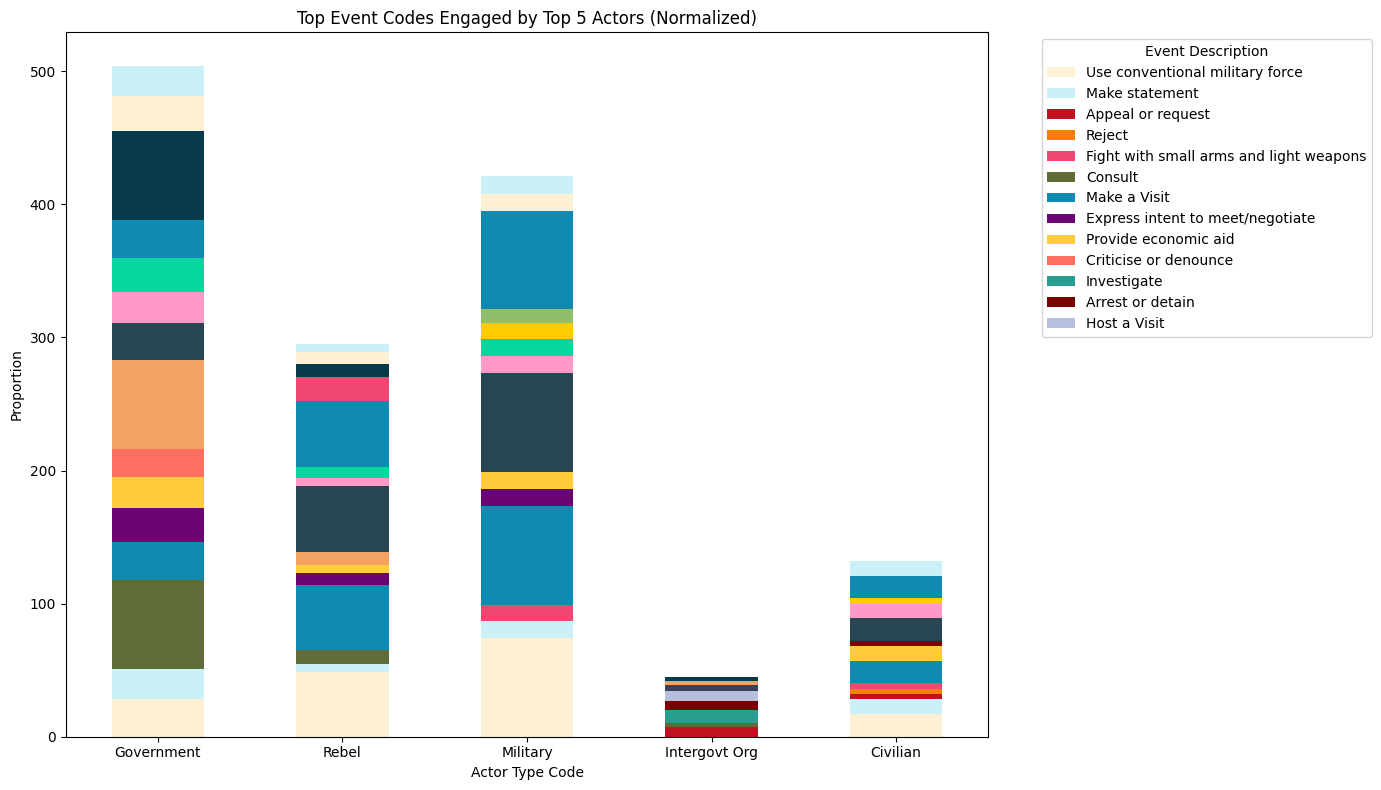

In [0]:
top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']
labels = ['Government', 'Rebel', 'Military', 'Intergovt Org', 'Civilian']

# Step 2: Filter the DataFrame for top 5 actors
filtered_df = df5[df5['Actor1Type1Code'].isin(top_5_actors)]

# Step 3: Count occurrences of each EventCode for each Actor
event_counts = filtered_df.groupby(['Actor1Type1Code', 'EventCode']).size().unstack(fill_value=0)

# Top 15 EventCodes for each actor
top_event_codes = event_counts.apply(lambda x: x.nlargest(5).index.tolist(), axis=1)

# Create a list of tuples for easier plotting
actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]

# Filter the original dataframe for these top events
filtered_events_df = filtered_df[filtered_df.apply(lambda x: (x['Actor1Type1Code'], x['EventCode']) in actor_event_pairs, axis=1)]

# Count occurrences again for the filtered dataframe
final_event_counts = filtered_events_df.groupby(['Actor1Type1Code', 'EventCode']).size().unstack(fill_value=0)

# Ensure we only have the top event codes for each actor
final_event_counts = final_event_counts.loc[top_5_actors, [event for sublist in top_event_codes for event in sublist if event in final_event_counts.columns]].fillna(0)

# Normalize the values by dividing by the total count for each actor
#normalized_final_event_counts = final_event_counts.div(final_event_counts.sum(axis=1), axis=0)

# Plotting
ax = final_event_counts.plot(kind='bar', stacked=True, figsize=(14, 8), 
                                        color=['#fdf0d5', '#CAF0F8', '#c1121f', '#f77f00', '#ef476f', '#606C38', '#118ab2', '#6a0572', '#ffcd3c', '#ff6f61', '#2a9d8f', '#780000', '#B8BEDD', '#3d405b', '#f4a261', '#264653', '#ff99c8', '#06d6a0', '#ffcc00', '#90be6d', '#118ab2', '#ef476f', '#073b4c']
                                       )
ax.set_xticklabels(labels)

plt.title('Top Event Codes Engaged by Top 5 Actors (Normalized)')
plt.xlabel('Actor Type Code')
plt.ylabel('Proportion')

# Custom legend labels using event_descriptions dictionary
event_descriptions = {
    10: "Make statement",
    12: "Make pessimistic comment",
    20: "Appeal or request",
    36: "Express intent to meet/negotiate", #LK
    40: "Consult",
    42: "Make a Visit",
    43: "Host a Visit",
    46: "Engage in Negotiation",
    51: "Praise or endorse",
    57: "Sign formal agreement", #LK
    60: "Engage in material cooperation", #lk
    71: "Provide economic aid", #lk
    80: "Yield", #lk
    83: "Accede to requests/demands for political reform",
    90: "Investigate",
    100: "Demand",
    110: "Disapprove",
    111: "Criticise or denounce",
    112: "Accuse",
    120: "Reject",
    130: "Threaten",
    141: "Demonstrate or rally",
    145: "Protest violently, riot",
    172: "Impose administrative sanctions",
    173: "Arrest or detain",
    175: "Use tactics of violent repression",
    180: "Use conventional violence",
    182: "Physically assault",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons",
    332: "Express intent to provide military aid",
    1723: "Impose curfew"
}

# Create a list of custom labels for the legend, ensuring uniqueness
custom_labels = []
for event in final_event_counts.columns:
    desc = event_descriptions.get(event, f"Event Code {event}")
    if desc not in custom_labels:
        custom_labels.append(desc)

# Update the legend with custom labels
ax.legend(custom_labels, title='Event Description', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/root/.ipykernel/1467/command-3309788604878817-1148512558:14: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]


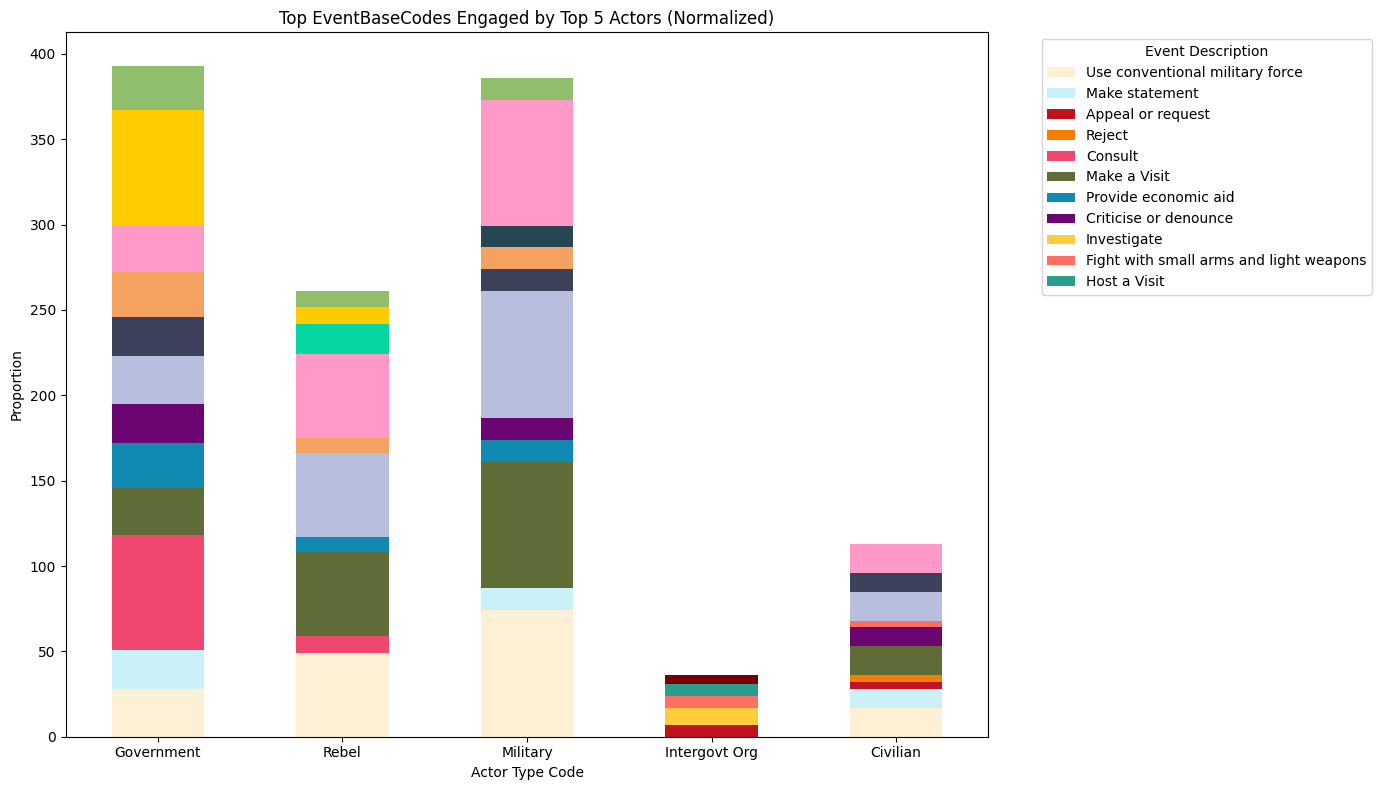

In [0]:
top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']
labels = ['Government', 'Rebel', 'Military', 'Intergovt Org', 'Civilian']

# Step 2: Filter the DataFrame for top 5 actors
filtered_df = df5[df5['Actor1Type1Code'].isin(top_5_actors)]

# Step 3: Count occurrences of each EventBaseCode for each Actor
event_counts = filtered_df.groupby(['Actor1Type1Code', 'EventBaseCode']).size().unstack(fill_value=0)

# Top 15 EventBaseCode for each actor
top_event_codes = event_counts.apply(lambda x: x.nlargest(4).index.tolist(), axis=1)

# Create a list of tuples for easier plotting
actor_event_pairs = [(actor, event) for actor, events in top_event_codes.iteritems() for event in events]

# Filter the original dataframe for these top events
filtered_events_df = filtered_df[filtered_df.apply(lambda x: (x['Actor1Type1Code'], x['EventBaseCode']) in actor_event_pairs, axis=1)]

# Count occurrences again for the filtered dataframe
final_event_counts = filtered_events_df.groupby(['Actor1Type1Code', 'EventBaseCode']).size().unstack(fill_value=0)

# Ensure we only have the top event codes for each actor
final_event_counts = final_event_counts.loc[top_5_actors, [event for sublist in top_event_codes for event in sublist if event in final_event_counts.columns]].fillna(0)

# Normalize the values by dividing by the total count for each actor
#normalized_final_event_counts = final_event_counts.div(final_event_counts.sum(axis=1), axis=0)

# Plotting
ax = final_event_counts.plot(kind='bar', stacked=True, figsize=(14, 8), 
                                        color=['#fdf0d5', '#CAF0F8', '#c1121f', '#f77f00', '#ef476f', '#606C38', '#118ab2', '#6a0572', '#ffcd3c', '#ff6f61', '#2a9d8f', '#780000', '#B8BEDD', '#3d405b', '#f4a261', '#264653', '#ff99c8', '#06d6a0', '#ffcc00', '#90be6d', '#118ab2', '#ef476f', '#073b4c']
                                       )
ax.set_xticklabels(labels)

plt.title('Top EventBaseCodes Engaged by Top 5 Actors (Normalized)')
plt.xlabel('Actor Type Code')
plt.ylabel('Proportion')

# Custom legend labels using event_descriptions dictionary
event_descriptions = {
    10: "Make statement",
    12: "Make pessimistic comment",
    20: "Appeal or request",
    36: "Express intent to meet/negotiate", #LK
    40: "Consult",
    42: "Make a Visit",
    43: "Host a Visit",
    46: "Engage in Negotiation",
    51: "Praise or endorse",
    57: "Sign formal agreement", #LK
    60: "Engage in material cooperation", #lk
    71: "Provide economic aid", #lk
    80: "Yield", #lk
    83: "Accede to requests/demands for political reform",
    90: "Investigate",
    100: "Demand",
    110: "Disapprove",
    111: "Criticise or denounce",
    112: "Accuse",
    120: "Reject",
    130: "Threaten",
    141: "Demonstrate or rally",
    145: "Protest violently, riot",
    172: "Impose administrative sanctions",
    173: "Arrest or detain",
    175: "Use tactics of violent repression",
    180: "Use conventional violence",
    182: "Physically assault",
    190: "Use conventional military force",
    193: "Fight with small arms and light weapons",
    332: "Express intent to provide military aid",
    1723: "Impose curfew"
}

# Create a list of custom labels for the legend, ensuring uniqueness
custom_labels = []
for event in final_event_counts.columns:
    desc = event_descriptions.get(event, f"Event Code {event}")
    if desc not in custom_labels:
        custom_labels.append(desc)

# Update the legend with custom labels
ax.legend(custom_labels, title='Event Description', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Visualising Events on Map

In [0]:
#using geopandas to plot events based on type in Palestine

# Define latitude and longitude ranges for Sri Lanka
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Convert latitude and longitude to float
df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)

#creating a new column geometry using point with long and lat
geometry = [Point(xy) for xy in zip(df5['ActionGeo_Long'], df5['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df5, geometry=geometry)
# gdf.head(4)

# Read the shapefile for Palestine
ps = gpd.read_file("pse_shpfile.shp")

#https://gis.stackexchange.com/questions/404196/create-a-column-geometry-of-points-with-longitude-and-latitude-data-given-in-a
#https://anitagraser.com/2019/01/23/from-csv-to-geodataframe-in-two-lines/
#https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html

/root/.ipykernel/1162/command-2714981194622985-2165925241:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
/root/.ipykernel/1162/command-2714981194622985-2165925241:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)


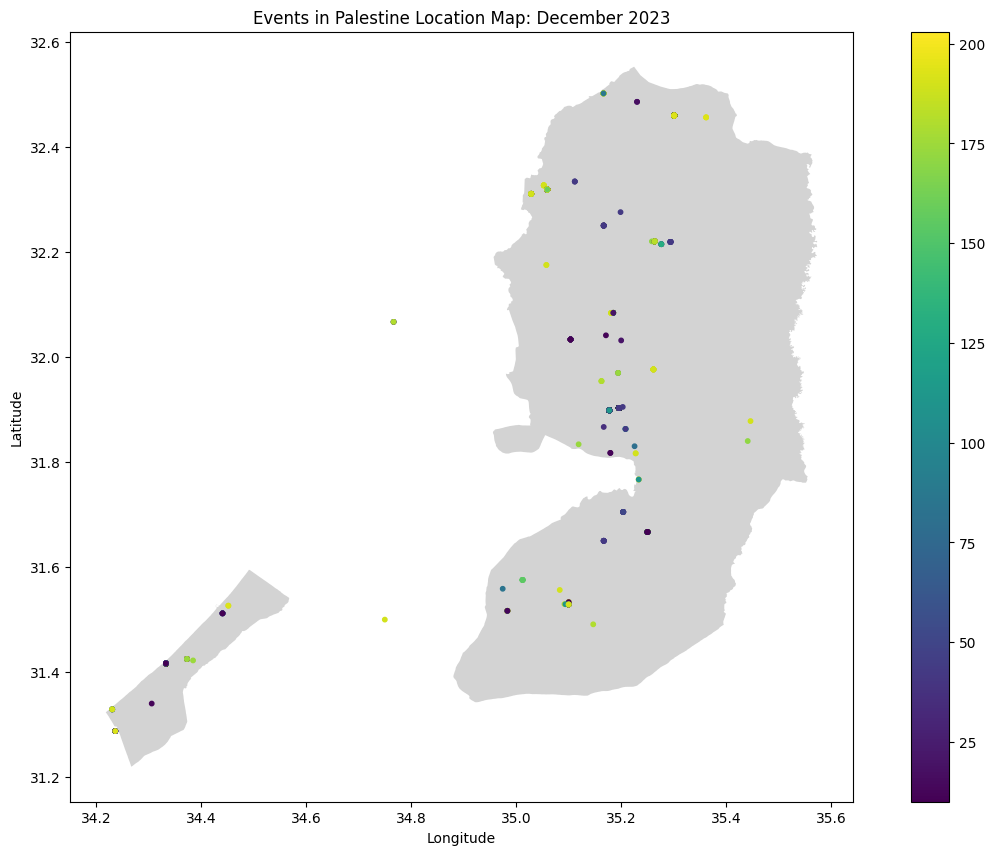

In [0]:
# MAP 1: map events by EVENTBASECODE then by CONFLICT-SPECIFIC ones over a period of ONE MONTH
# What event types happen where, and how important are they? 

# Create geometry column using points from longitude and latitude
#geometry = [Point(xy) for xy in zip(df3['ActionGeo_Long'], df3['ActionGeo_Lat'])]
#gdf = gpd.GeoDataFrame(df3, geometry=geometry)

# Read the shapefile for Palestine
ps = gpd.read_file("pse_shpfile.shp")

# Filter all events within the latitude and longitude ranges of Sri Lanka
ps_news = gdf[
    (gdf["ActionGeo_Lat"] >= min_lat) & (gdf["ActionGeo_Lat"] <= max_lat) &
    (gdf["ActionGeo_Long"] >= min_lon) & (gdf["ActionGeo_Long"] <= max_lon)
]

# Visualize events on the shapefile
fig, ax = plt.subplots(figsize=(15, 10))
ps.plot(ax=ax, color='lightgrey')
ps_news.plot(ax=ax, markersize=10, column='EventBaseCode', legend=True)
plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.title('Events in Palestine Location Map: December 2023')
plt.show()


/root/.ipykernel/1162/command-2714981194622987-48161846:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_event_codes))
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c0146f62-dc6b-4e71-aea0-2231a1cf623f/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


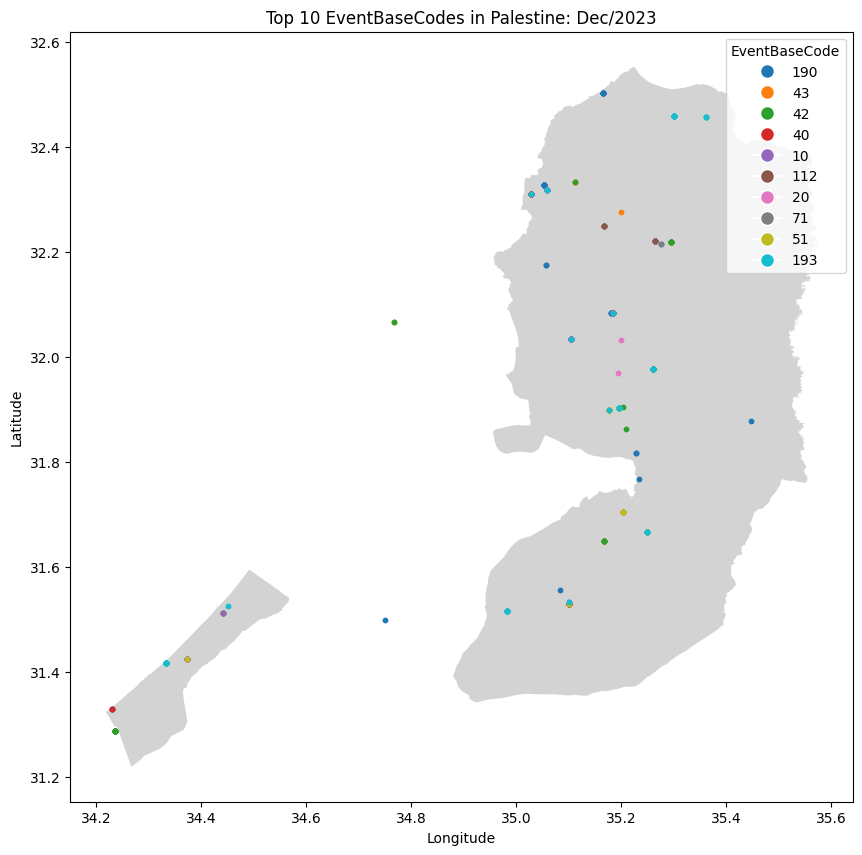

In [0]:
#df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
#df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)

# new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df5['ActionGeo_Long'], df5['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df5, geometry=geometry)

# Read the shapefile for Palestine
ps = gpd.read_file("pse_shpfile.shp")

# latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Filter all events within the latitude and longitude ranges of Sri Lanka
ps_news = gdf[
    (gdf["ActionGeo_Lat"] >= min_lat) & (gdf["ActionGeo_Lat"] <= max_lat) &
    (gdf["ActionGeo_Long"] >= min_lon) & (gdf["ActionGeo_Long"] <= max_lon)
]

# Get the top 10 event codes
top_event_codes = ps_news['EventBaseCode'].value_counts().head(10).index
top_events = ps_news[ps_news['EventBaseCode'].isin(top_event_codes)]

# colors - top 10 event codes
unique_event_codes = top_event_codes
colors = plt.cm.get_cmap('tab10', len(unique_event_codes))

# dictionary to map event codes to colors
color_mapping = {code: colors(i) for i, code in enumerate(unique_event_codes)}

# Add a color column to the GeoDataFrame
top_events['color'] = top_events['EventBaseCode'].map(color_mapping)

# Visualize the top 10 event codes on the shapefile
fig, ax = plt.subplots(figsize=(15, 10))
ps.plot(ax=ax, color='lightgrey')
for code in unique_event_codes:
    subset = top_events[top_events['EventBaseCode'] == code]
    subset.plot(ax=ax, markersize=10, color=color_mapping[code], label=code)

# Add legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_mapping[code], markersize=10, label=code) for code in unique_event_codes]
ax.legend(handles=handles, title="EventBaseCode")

plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.title('Top 10 EventBaseCodes in Palestine: Dec/2023')
plt.show()


In [0]:
# can the size of the plotted dot for each event reflect the importance score? Larger size for greater importance score

importance_score_values = df5['ImportanceScore'].value_counts()
importance_score_values

1.666667     1315
1.000000     1015
3.000000      393
4.333333      194
2.333333      169
5.666667       97
7.000000       80
3.666667       64
5.000000       39
2.000000       35
3.333333       31
6.000000       11
4.000000        8
4.666667        8
9.000000        7
6.666667        5
1.333333        5
8.666667        4
6.333333        4
10.000000       3
8.333333        3
2.666667        3
9.333333        2
7.666667        2
9.666667        2
11.333333       2
15.000000       2
17.000000       1
7.333333        1
13.666667       1
Name: ImportanceScore, dtype: int64

Top 10 EventBaseCodes in Palestine Location Map


/root/.ipykernel/1162/command-2714981194622990-980889165:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
/root/.ipykernel/1162/command-2714981194622990-980889165:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)
/root/.ipykernel/1162/command-2714981194622990-980889165:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releas

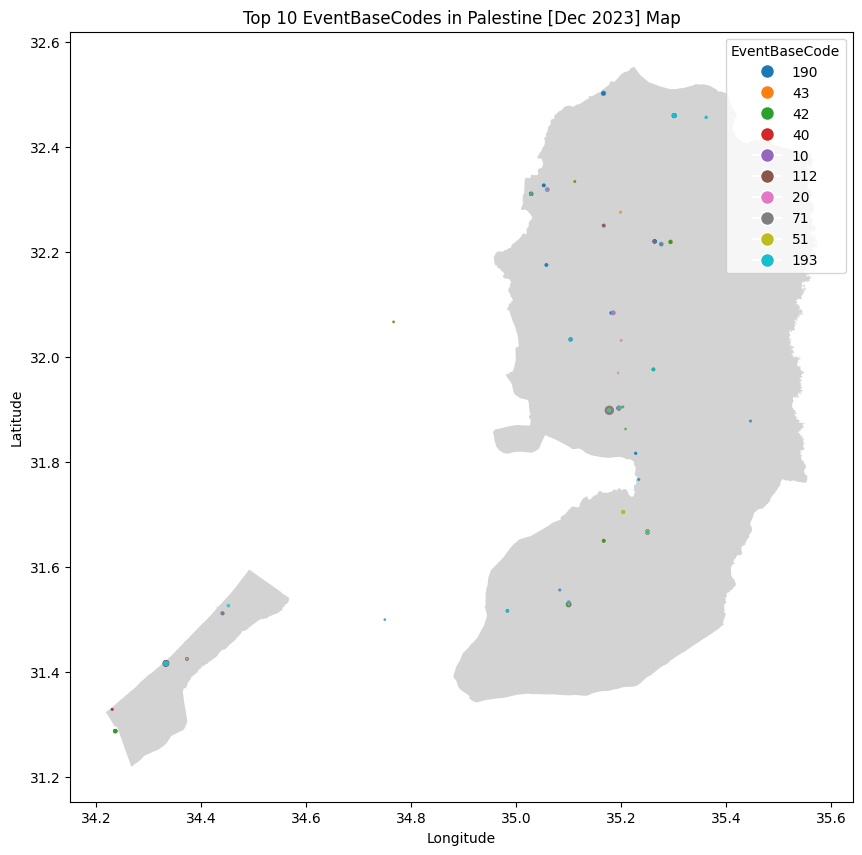

In [0]:
# Convert latitude and longitude to float
df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)

# Create a new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df5['ActionGeo_Long'], df5['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df5, geometry=geometry)

# Read the shapefile for Palestine
ps = gpd.read_file("pse_shpfile.shp")

# latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Filter all events within the latitude and longitude ranges of Sri Lanka
ps_news = gdf[
    (gdf["ActionGeo_Lat"] >= min_lat) & (gdf["ActionGeo_Lat"] <= max_lat) &
    (gdf["ActionGeo_Long"] >= min_lon) & (gdf["ActionGeo_Long"] <= max_lon)
]

# Get the top 10 event codes
top_event_codes = ps_news['EventBaseCode'].value_counts().head(10).index
top_events = ps_news[ps_news['EventBaseCode'].isin(top_event_codes)]

# Use the raw importance scores for the dot sizes
sizes = top_events['ImportanceScore']

# Assign colors to the top 10 event codes
unique_event_codes = top_event_codes
colors = plt.cm.get_cmap('tab10', len(unique_event_codes))

# Create a dictionary to map event codes to colors
color_mapping = {code: colors(i) for i, code in enumerate(unique_event_codes)}

# Add a color column to the GeoDataFrame
top_events['color'] = top_events['EventBaseCode'].map(color_mapping)

# Visualize the top 10 event codes on the shapefile with variable dot sizes
fig, ax = plt.subplots(figsize=(15, 10))
ps.plot(ax=ax, color='lightgrey')

for code in unique_event_codes:
    subset = top_events[top_events['EventBaseCode'] == code]
    subset_sizes = sizes[top_events['EventBaseCode'] == code]
    subset.plot(ax=ax, markersize=subset_sizes, color=color_mapping[code], label=code, alpha=0.6)

# Add legend
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_mapping[code], markersize=10, label=code) for code in unique_event_codes]
ax.legend(handles=handles, title="EventBaseCode")

plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.title('Top 10 EventBaseCodes in Palestine [Dec 2023] Map')
plt.show()


/root/.ipykernel/1162/command-2714981194622991-473008462:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
/root/.ipykernel/1162/command-2714981194622991-473008462:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)
/root/.ipykernel/1162/command-2714981194622991-473008462:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releas

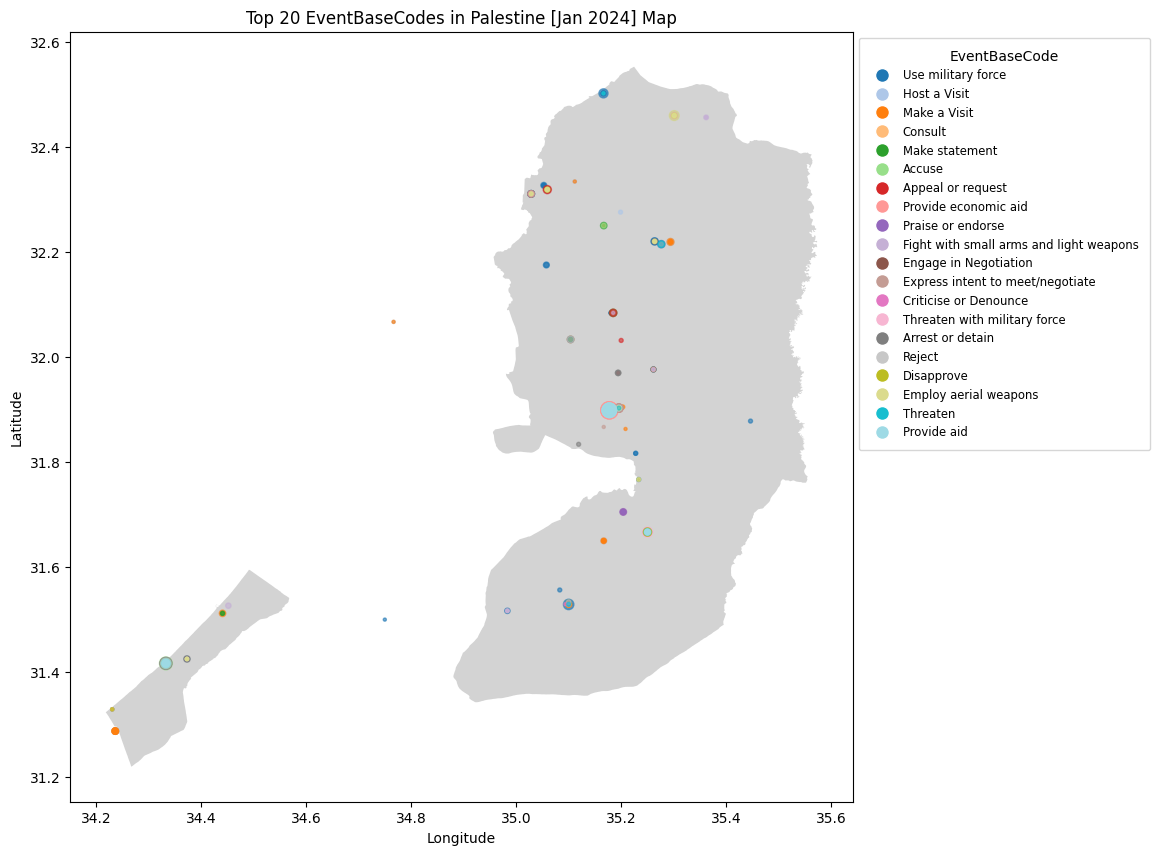

In [0]:
# Convert latitude and longitude to float
df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)

# Create a new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df5['ActionGeo_Long'], df5['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df5, geometry=geometry)

# Read the shapefile for Palestine
ps = gpd.read_file("pse_shpfile.shp")

# latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Filter all events within the latitude and longitude ranges of Sri Lanka
ps_news = gdf[
    (gdf["ActionGeo_Lat"] >= min_lat) & (gdf["ActionGeo_Lat"] <= max_lat) &
    (gdf["ActionGeo_Long"] >= min_lon) & (gdf["ActionGeo_Long"] <= max_lon)
]


# Get the top 20 event codes
top_event_codes = ps_news['EventBaseCode'].value_counts().head(20).index
top_events = ps_news[ps_news['EventBaseCode'].isin(top_event_codes)]

# Use the raw importance scores for the dot sizes
scaling_factor = 5
sizes = top_events['ImportanceScore'] * scaling_factor # make baseline dot size bigger

# Define event descriptions
event_descriptions = {
    10: "Make statement",
    12: "Make pessimistic comment",
    20: "Appeal or request",
    36: "Express intent to meet/negotiate",
    40: "Consult",
    42: "Make a Visit",
    43: "Host a Visit",
    46: "Engage in Negotiation",
    51: "Praise or endorse",
    60: "Engage in material cooperation",
    70: "Provide aid",
    71: "Provide economic aid",
    80: "Yield",
    83: "Accede to requests/demands for political reform",
    84: "Return or Release",
    100: "Demand",
    110: "Disapprove",
    111: "Criticise or Denounce",
    112: "Accuse",
    120: "Reject",
    130: "Threaten",
    138: "Threaten with military force",
    141: "Demonstrate or rally",
    172: "Impose administrative sanctions",
    173: "Arrest or detain",
    180: "Use conventional violence",
    182: "Physically assault",
    190: "Use military force",
    192: "Occupy territory",
    193: "Fight with small arms and light weapons",
    195: "Employ aerial weapons",
    332: "Express intent to provide military aid",
    1723: "Impose curfew"
}

# Assign colors to the top 20 event codes
unique_event_codes = top_event_codes
colors = plt.cm.get_cmap('tab20', len(unique_event_codes))

# Create a dictionary to map event codes to colors
color_mapping = {code: colors(i) for i, code in enumerate(unique_event_codes)}

# Add a color column to the GeoDataFrame
top_events['color'] = top_events['EventBaseCode'].map(color_mapping)

# Visualize the top 20 event codes on the shapefile with variable dot sizes
fig, ax = plt.subplots(figsize=(15, 10))
ps.plot(ax=ax, color='lightgrey')

for code in unique_event_codes:
    subset = top_events[top_events['EventBaseCode'] == code]
    subset_sizes = sizes[top_events['EventBaseCode'] == code]
    subset.plot(ax=ax, markersize=subset_sizes, color=color_mapping[code], label=code, alpha=0.6)

# Add legend
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_mapping[code], markersize=10, label=event_descriptions[code]) for code in unique_event_codes]
ax.legend(handles=handles, title="EventBaseCode", fontsize='small', loc='upper left', bbox_to_anchor=(1, 1), ncol=1, borderpad=1)

plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.title('Top 20 EventBaseCodes in Palestine [Jan 2024] Map')
plt.show()


/root/.ipykernel/1162/command-2714981194622992-2257533045:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
/root/.ipykernel/1162/command-2714981194622992-2257533045:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)
/root/.ipykernel/1162/command-2714981194622992-2257533045:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor rel

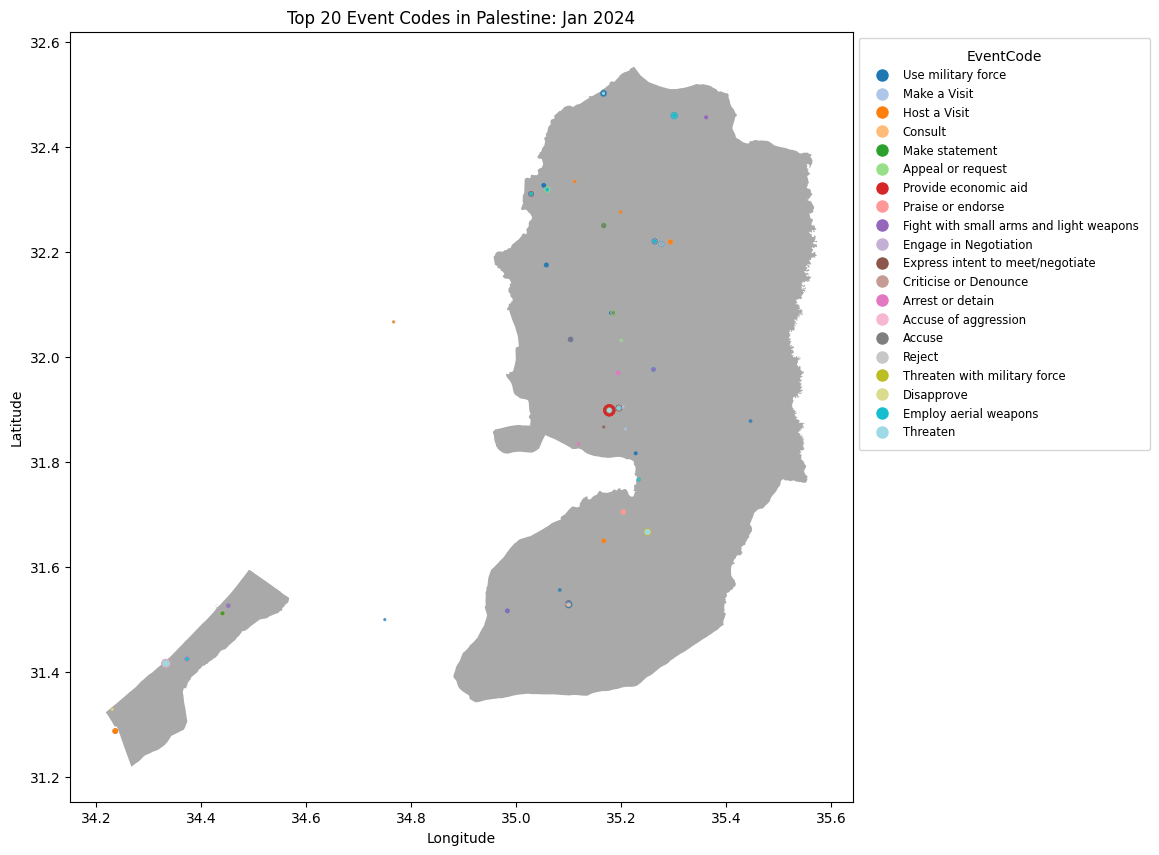

In [0]:
# Convert latitude and longitude to float
df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)

# Create a new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df5['ActionGeo_Long'], df5['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df5, geometry=geometry)

# Read the shapefile for Palestine
ps = gpd.read_file("pse_shpfile.shp")

# latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Filter all events within the latitude and longitude ranges of Sri Lanka
ps_news = gdf[
    (gdf["ActionGeo_Lat"] >= min_lat) & (gdf["ActionGeo_Lat"] <= max_lat) &
    (gdf["ActionGeo_Long"] >= min_lon) & (gdf["ActionGeo_Long"] <= max_lon)
]

# Get the top 20 event codes
top_event_codes = ps_news['EventCode'].value_counts().head(20).index
top_events = ps_news[ps_news['EventCode'].isin(top_event_codes)]

# Use the raw importance scores for the dot sizes
scaling_factor = 2
sizes = top_events['ImportanceScore'] * scaling_factor # make baseline dot size bigger

# Define event descriptions
event_descriptions = {
    10: "Make statement",
    12: "Make pessimistic comment",
    20: "Appeal or request",
    36: "Express intent to meet/negotiate",
    40: "Consult",
    42: "Make a Visit",
    43: "Host a Visit",
    46: "Engage in Negotiation",
    51: "Praise or endorse",
    60: "Engage in material cooperation",
    70: "Provide aid",
    71: "Provide economic aid",
    80: "Yield",
    83: "Accede to requests/demands for political reform",
    84: "Return or Release",
    100: "Demand",
    110: "Disapprove",
    111: "Criticise or Denounce",
    112: "Accuse",
    120: "Reject",
    130: "Threaten",
    138: "Threaten with military force",
    141: "Demonstrate or rally",
    172: "Impose administrative sanctions",
    173: "Arrest or detain",
    180: "Use conventional violence",
    182: "Physically assault",
    190: "Use military force",
    192: "Occupy territory",
    193: "Fight with small arms and light weapons",
    195: "Employ aerial weapons",
    332: "Express intent to provide military aid",
    1123: "Accuse of aggression",
    1723: "Impose curfew"
}

# Assign colors to the top 20 event codes
unique_event_codes = top_event_codes
colors = plt.cm.get_cmap('tab20', len(unique_event_codes))

# Create a dictionary to map event codes to colors
color_mapping = {code: colors(i) for i, code in enumerate(unique_event_codes)}

# Add a color column to the GeoDataFrame
top_events['color'] = top_events['EventCode'].map(color_mapping)

# Visualize the top 20 event codes on the shapefile with variable dot sizes
fig, ax = plt.subplots(figsize=(15, 10))
ps.plot(ax=ax, color='darkgrey')

for code in unique_event_codes:
    subset = top_events[top_events['EventCode'] == code]
    subset_sizes = sizes[top_events['EventCode'] == code]
    subset.plot(ax=ax, markersize=subset_sizes, color=color_mapping[code], label=code, alpha=0.6)

# Add legend
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_mapping[code], markersize=10, label=event_descriptions[code]) for code in unique_event_codes]
ax.legend(handles=handles, title="EventCode", fontsize='small', loc='upper left', bbox_to_anchor=(1, 1), ncol=1, borderpad=1)

plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.title('Top 20 Event Codes in Palestine: Jan 2024')
plt.show()


Visualisation of Events based on GOLDSTEIN SCORE

/root/.ipykernel/1467/command-3199079478707811-4119152661:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
/root/.ipykernel/1467/command-3199079478707811-4119152661:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)


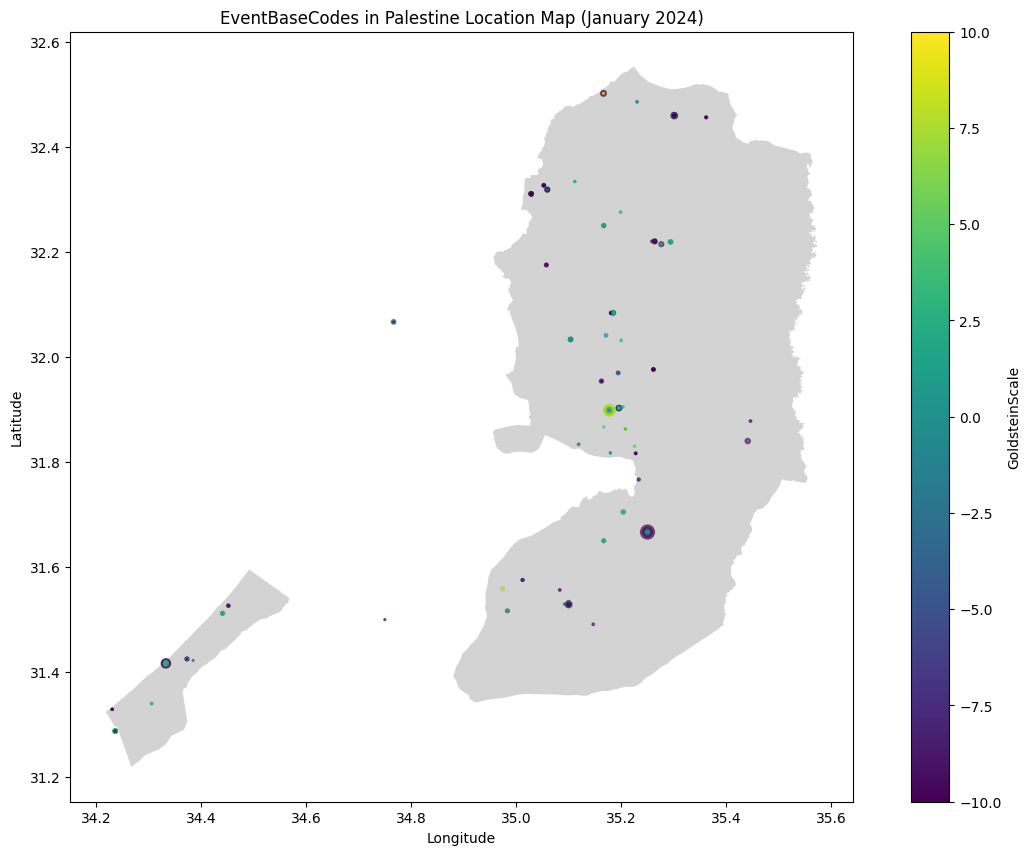

In [0]:
# plot ALL event base codes - color based on goldstein score.

# Convert latitude and longitude to float
df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)

# Create a new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df5['ActionGeo_Long'], df5['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df5, geometry=geometry)

# Read the shapefile for Sri Lanka
ps = gpd.read_file("pse_shpfile.shp")

# latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Filter all events within the latitude and longitude ranges of Sri Lanka
ps_news = gdf[
    (gdf["ActionGeo_Lat"] >= min_lat) & (gdf["ActionGeo_Lat"] <= max_lat) &
    (gdf["ActionGeo_Long"] >= min_lon) & (gdf["ActionGeo_Long"] <= max_lon)
]

# Use the raw importance scores for the dot sizes
scaling_factor = 2
sizes = ps_news['ImportanceScore'] * scaling_factor

# Assign colors based ps_news GoldsteinScore
norm = plt.Normalize(ps_news['GoldsteinScale'].min(), ps_news['GoldsteinScale'].max())
cmap = plt.cm.viridis  # You can choose any colormap you prefer
colors = cmap(norm(ps_news['GoldsteinScale']))

# Visualize all event codes on the shapefile with variable dot sizes and colors based on GoldsteinScore
fig, ax = plt.subplots(figsize=(15, 10))
ps.plot(ax=ax, color='lightgrey')

ps_news.plot(ax=ax, markersize=sizes, color=colors, alpha=0.6)

# Create a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Only needed for matplotlib < 3.1
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('GoldsteinScale')

plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.title('EventBaseCodes in Palestine Location Map (January 2024)')
plt.show()


/root/.ipykernel/1467/command-3199079478707812-2649571959:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['ActionGeo_Long'] = df4['ActionGeo_Long'].astype(float)
/root/.ipykernel/1467/command-3199079478707812-2649571959:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['ActionGeo_Lat'] = df4['ActionGeo_Lat'].astype(float)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is try

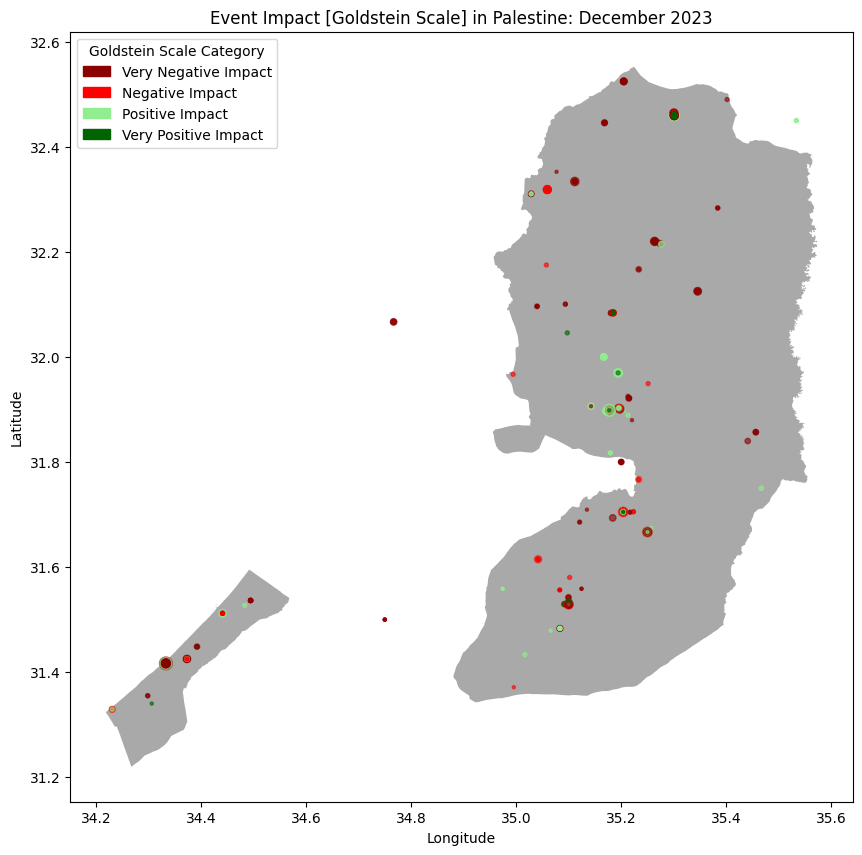

/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


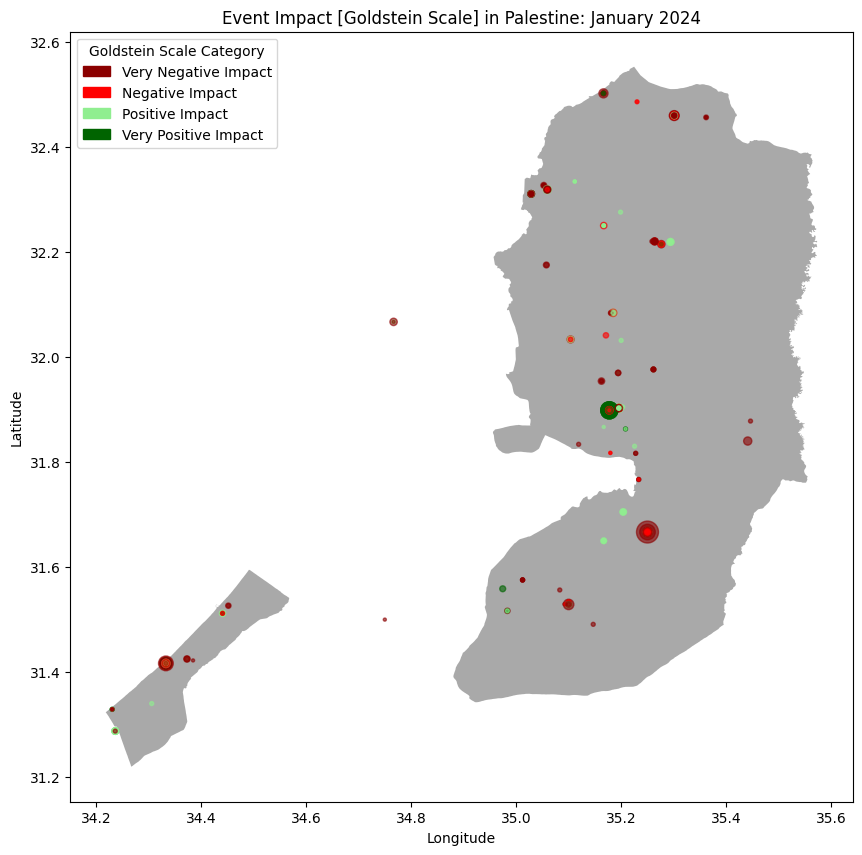

/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


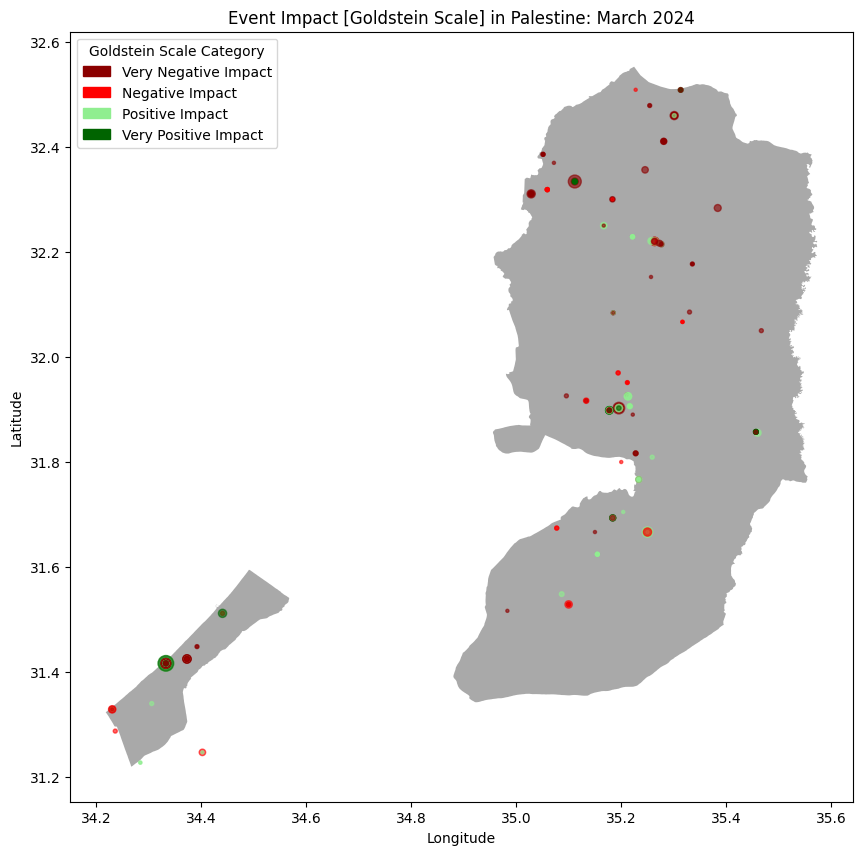

/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


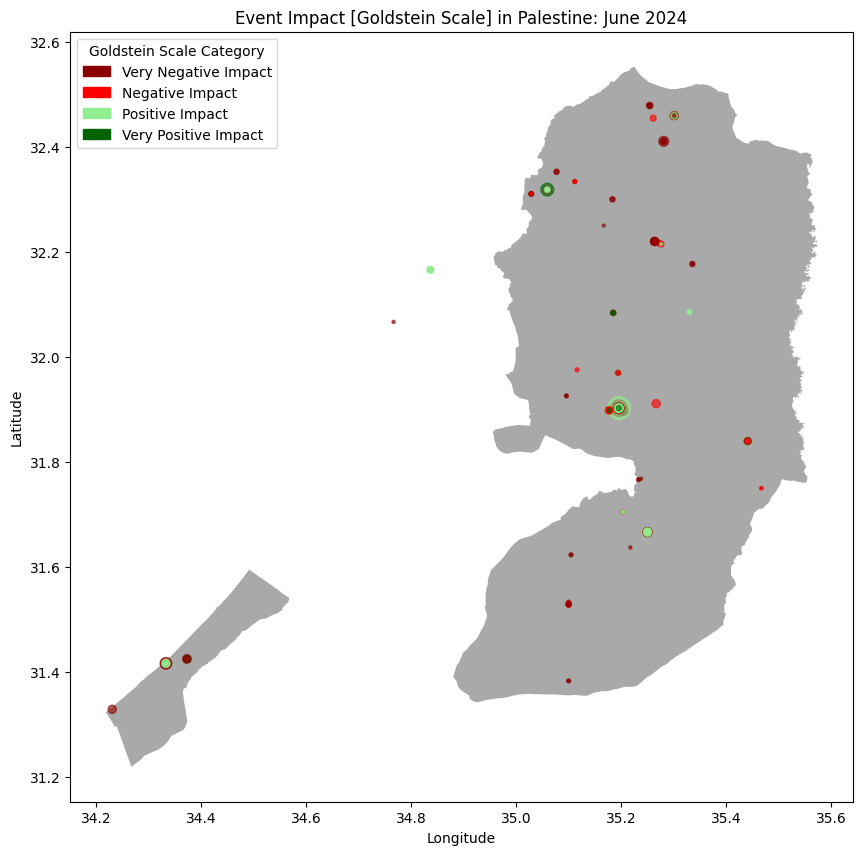

In [0]:
# Convert latitude and longitude to float
df4['ActionGeo_Long'] = df4['ActionGeo_Long'].astype(float)
df4['ActionGeo_Lat'] = df4['ActionGeo_Lat'].astype(float)

# Create a new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df4['ActionGeo_Long'], df4['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df4, geometry=geometry)

# Read the shapefile for Sri Lanka
ps = gpd.read_file("pse_shpfile.shp")

# Define the months you want to visualize
months = ['2023-12', '2024-01', '2024-03', '2024-06']

# Latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Scaling factor for dot sizes (define this according to your data)
scaling_factor = 5

# Loop through each month to create the visualizations
for month in months:
    # Extract year and month
    year, month_num = map(int, month.split('-'))
    
    # Get month name
    month_name = calendar.month_name[month_num]
    
    # Filter the data for the current month
    filtered_df = gdf[(gdf['SQLDATE'].dt.year == year) & (gdf['SQLDATE'].dt.month == month_num)]
    
    # Filter all events within the latitude and longitude ranges of Sri Lanka
    ps_news = filtered_df[
        (filtered_df["ActionGeo_Lat"] >= min_lat) & (filtered_df["ActionGeo_Lat"] <= max_lat) &
        (filtered_df["ActionGeo_Long"] >= min_lon) & (filtered_df["ActionGeo_Long"] <= max_lon)
    ]

    # Use the raw importance scores for the dot sizes
    sizes = ps_news['ImportanceScore'] * scaling_factor

    # Create bins for GoldsteinScale
    bins = [-float('inf'), -5, 0, 5, float('inf')]
    labels = ['Very Negative Impact', 'Negative Impact', 'Positive Impact', 'Very Positive Impact']
    ps_news['GoldsteinCategory'] = pd.cut(ps_news['GoldsteinScale'], bins=bins, labels=labels)

    # Map bins to colors
    colors_dict = {
        'Very Negative Impact': 'darkred',
        'Negative Impact': 'red',
        'Positive Impact': 'lightgreen',
        'Very Positive Impact': 'darkgreen'
    }
    ps_news['Color'] = ps_news['GoldsteinCategory'].map(colors_dict)

    # Visualize all event codes on the shapefile with variable dot sizes and colors based on GoldsteinScale
    fig, ax = plt.subplots(figsize=(15, 10))
    ps.plot(ax=ax, color='darkgrey')

    ps_news.plot(ax=ax, markersize=sizes, color=ps_news['Color'], alpha=0.6)

    # Create a legend manually
    patches = [mpatches.Patch(color=colors_dict[label], label=label) for label in labels]
    plt.legend(handles=patches, title='Goldstein Scale Category')

    plt.xlabel("Longitude")
    plt.ylabel('Latitude')
    plt.title(f'Event Impact [Goldstein Scale] in Palestine: {month_name} {year}')
    plt.show()


Visualisation of Events based on Average Tone

/root/.ipykernel/1467/command-3309788604878815-878977401:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['ActionGeo_Long'] = df4['ActionGeo_Long'].astype(float)
/root/.ipykernel/1467/command-3309788604878815-878977401:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['ActionGeo_Lat'] = df4['ActionGeo_Lat'].astype(float)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is tryin

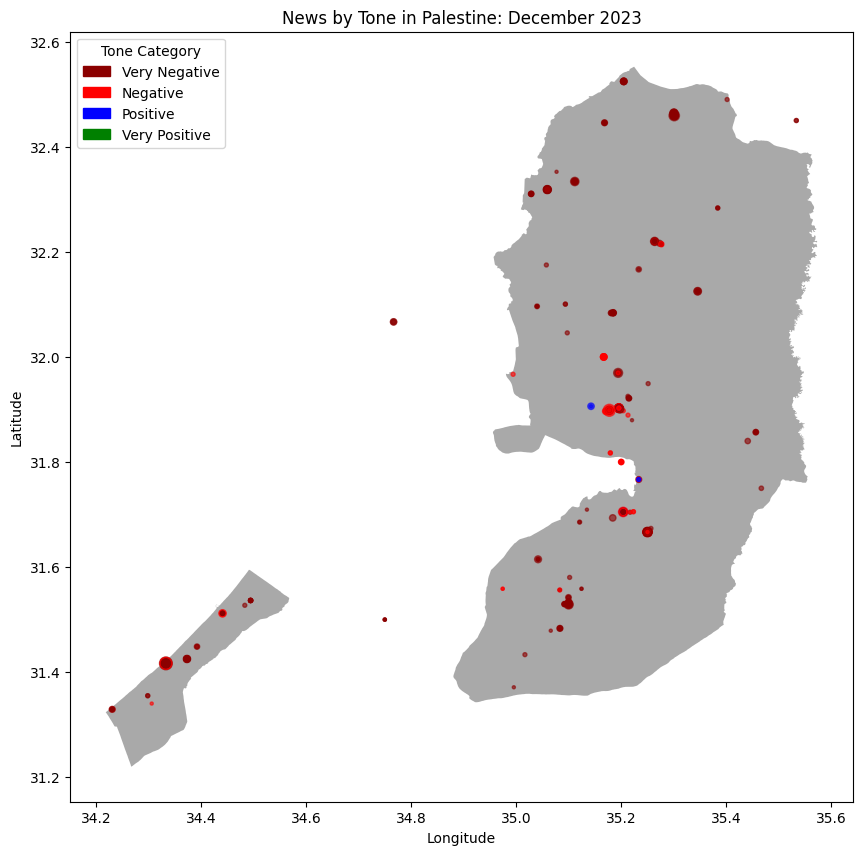

/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


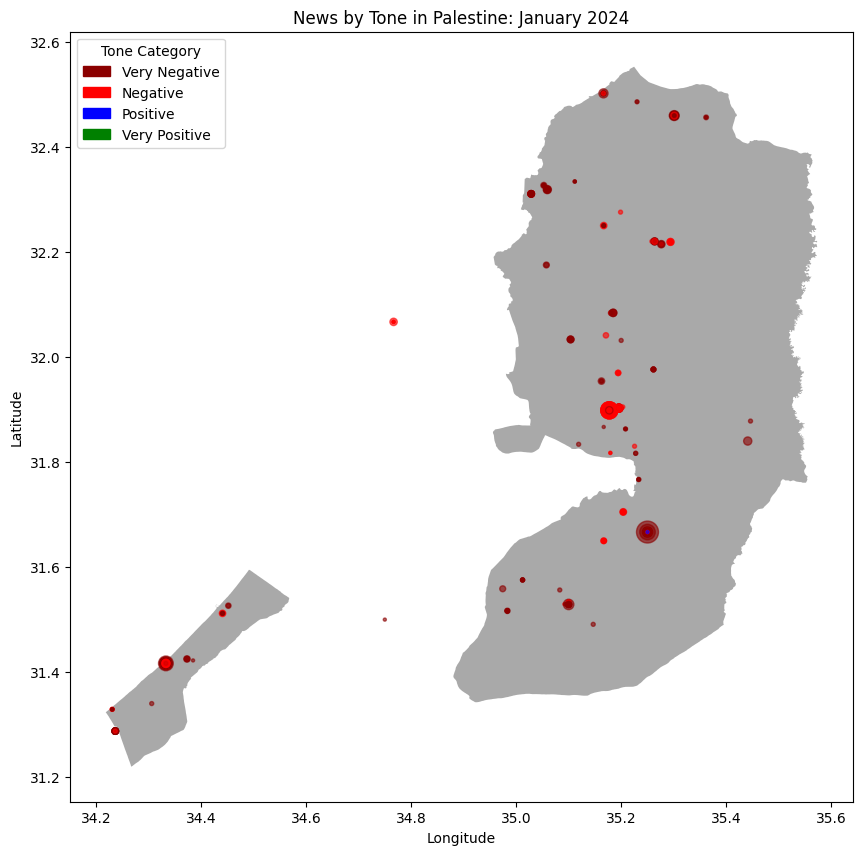

/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


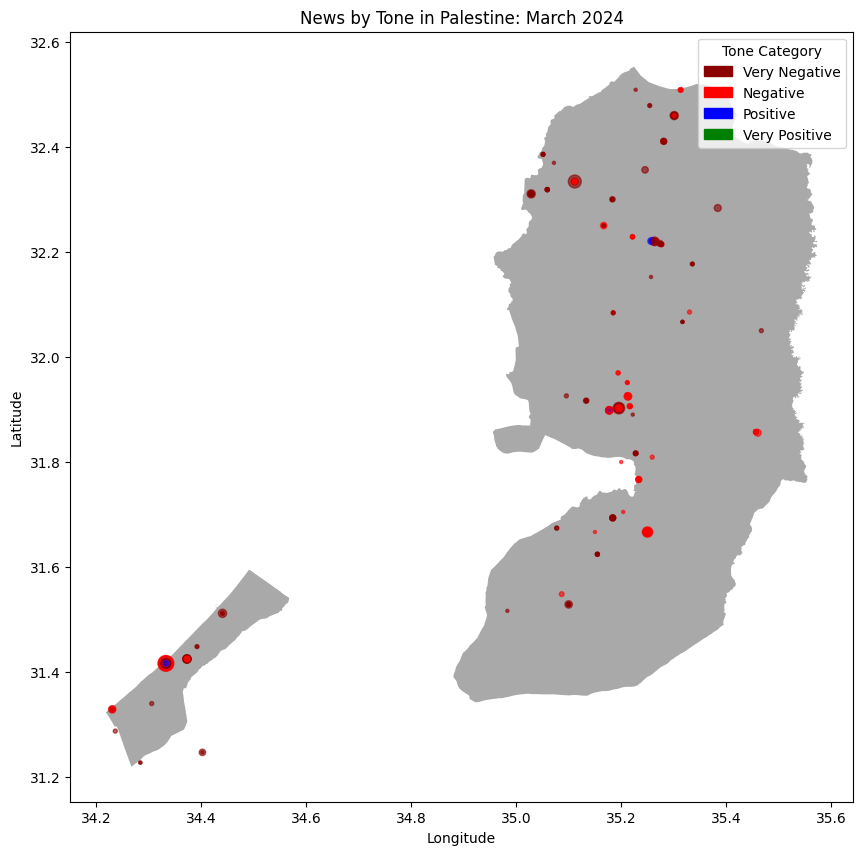

/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-50385446-df6e-4f79-bb96-ebd4e96a210e/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


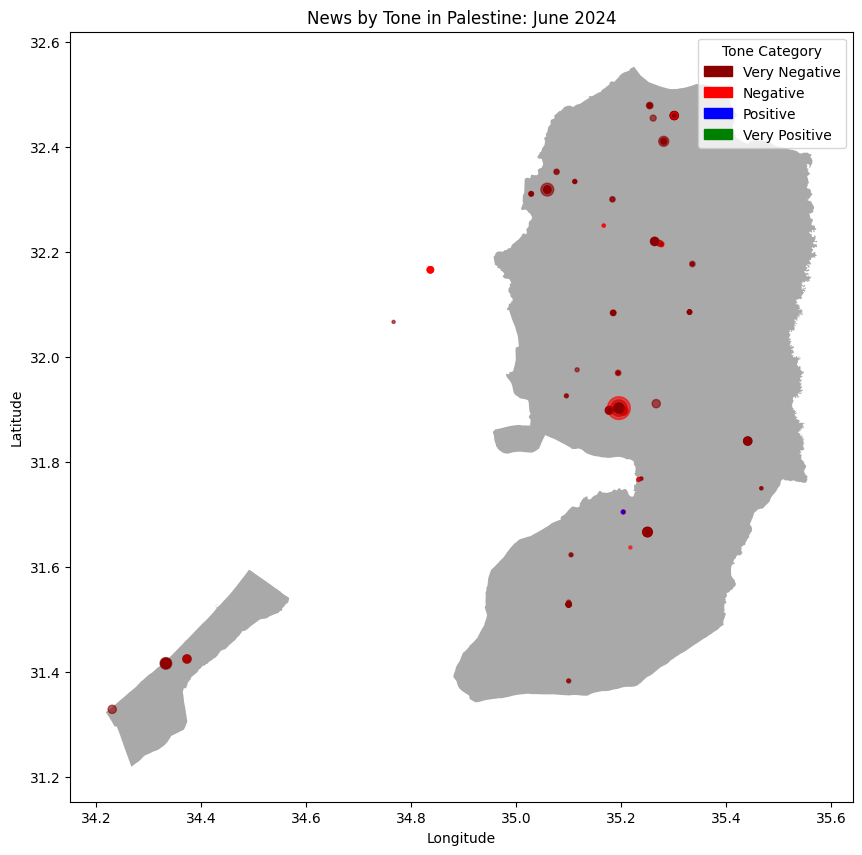

In [0]:
# Convert latitude and longitude to float
df4['ActionGeo_Long'] = df4['ActionGeo_Long'].astype(float)
df4['ActionGeo_Lat'] = df4['ActionGeo_Lat'].astype(float)

# Create a new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df4['ActionGeo_Long'], df4['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df4, geometry=geometry)

# Read the shapefile for Palestine
ps = gpd.read_file("pse_shpfile.shp")

# Define the months you want to visualize
months = ['2023-12', '2024-01', '2024-03', '2024-06']

# Latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Scaling factor for dot sizes
scaling_factor = 5

# Loop through each month to create the visualizations
for month in months:
    # Extract year and month
    year, month_num = map(int, month.split('-'))
    
    # Get month name
    month_name = calendar.month_name[month_num]
    
    # Filter the data for the current month
    filtered_df = gdf[(gdf['SQLDATE'].dt.year == year) & (gdf['SQLDATE'].dt.month == month_num)]
    
    # Filter all events within the latitude and longitude ranges of Palestine
    ps_news = filtered_df[
        (filtered_df["ActionGeo_Lat"] >= min_lat) & (filtered_df["ActionGeo_Lat"] <= max_lat) &
        (filtered_df["ActionGeo_Long"] >= min_lon) & (filtered_df["ActionGeo_Long"] <= max_lon)
    ]

    # Use the raw importance scores for the dot sizes
    sizes = ps_news['ImportanceScore'] * scaling_factor

    # Create bins for AvgTone
    bins = [-float('inf'), -5, 0, 5, float('inf')]
    labels = ['Very Negative', 'Negative', 'Positive', 'Very Positive']
    ps_news['ToneCategory'] = pd.cut(ps_news['AvgTone'], bins=bins, labels=labels)

    # Map bins to colors
    colors_dict = {
        'Very Negative': 'darkred',
        'Negative': 'red',
        'Positive': 'blue',
        'Very Positive': 'green'
    }
    ps_news['Color'] = ps_news['ToneCategory'].map(colors_dict)

    # Visualize all event codes on the shapefile with variable dot sizes and colors based on AvgTone
    fig, ax = plt.subplots(figsize=(15, 10))
    ps.plot(ax=ax, color='darkgrey')

    ps_news.plot(ax=ax, markersize=sizes, color=ps_news['Color'], alpha=0.6)

    # Create a colorbar manually
    patches = [mpatches.Patch(color=colors_dict[label], label=label) for label in labels]
    plt.legend(handles=patches, title='Tone Category')

    plt.xlabel("Longitude")
    plt.ylabel('Latitude')
    plt.title(f'News by Tone in Palestine: {month_name} {year}')
    plt.show()


/root/.ipykernel/1162/command-2714981194623001-4243221238:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
/root/.ipykernel/1162/command-2714981194623001-4243221238:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c0146f62-dc6b-4e71-aea0-2231a1cf623f/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is try

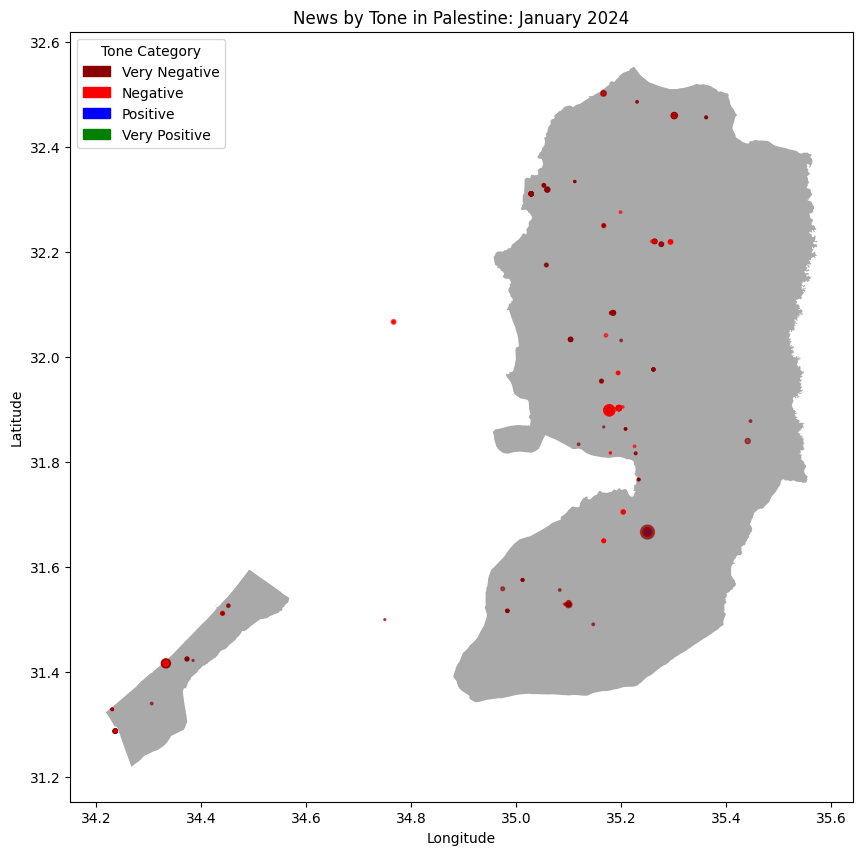

In [0]:
# Convert latitude and longitude to float
df5['ActionGeo_Long'] = df5['ActionGeo_Long'].astype(float)
df5['ActionGeo_Lat'] = df5['ActionGeo_Lat'].astype(float)

# Create a new column 'geometry' using Point with longitude and latitude
geometry = [Point(xy) for xy in zip(df5['ActionGeo_Long'], df5['ActionGeo_Lat'])]
gdf = gpd.GeoDataFrame(df5, geometry=geometry)

# Read the shapefile for Sri Lanka
ps = gpd.read_file("pse_shpfile.shp")

# latitude and longitude ranges for Palestine
min_lat = 31.136
max_lat = 32.527
min_lon = 34.216
max_lon = 35.727

# Filter all events within the latitude and longitude ranges of Sri Lanka
ps_news = gdf[
    (gdf["ActionGeo_Lat"] >= min_lat) & (gdf["ActionGeo_Lat"] <= max_lat) &
    (gdf["ActionGeo_Long"] >= min_lon) & (gdf["ActionGeo_Long"] <= max_lon)
]

# Use the raw importance scores for the dot sizes
scaling_factor = 2
sizes = ps_news['ImportanceScore'] * scaling_factor

# Create bins for AvgTone
bins = [-float('inf'), -5, 0, 5, float('inf')]
labels = ['Very Negative', 'Negative', 'Positive', 'Very Positive']
ps_news['ToneCategory'] = pd.cut(ps_news['AvgTone'], bins=bins, labels=labels)

# Map bins to colors
colors_dict = {
    'Very Negative': 'darkred',
    'Negative': 'red',
    'Positive': 'blue',
    'Very Positive': 'green'
}
ps_news['Color'] = ps_news['ToneCategory'].map(colors_dict)

# Visualize all event codes on the shapefile with variable dot sizes and colors based on AvgTone
fig, ax = plt.subplots(figsize=(15, 10))
ps.plot(ax=ax, color='darkgrey')

ps_news.plot(ax=ax, markersize=sizes, color=ps_news['Color'], alpha=0.6)

# Create a colorbar manually
import matplotlib.patches as mpatches

patches = [mpatches.Patch(color=colors_dict[label], label=label) for label in labels]
plt.legend(handles=patches, title='Tone Category')

plt.xlabel("Longitude")
plt.ylabel('Latitude')
plt.title('News by Tone in Palestine: January 2024')
plt.show()


/root/.ipykernel/1162/command-1848653201928492-2592409715:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


Combined Event Codes:
ADF Statistic: -2.887617
p-value: 0.046807
	1%: -3.526
	5%: -2.903
	10%: -2.589
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.59325D+00    |proj g|=  7.37070D-02

At iterate    5    f=  5.54481D+00    |proj g|=  7.25789D-03

At iterate   10    f=  5.54410D+00    |proj g|=  1.35045D-03

At iterate   15    f=  5.53249D+00    |proj g|=  3.07957D-02

At iterate   20    f=  5.50737D+00    |proj g|=  1.72687D-02

At iterate   25    f=  5.50379D+00    |proj g|=  5.21846D-03

At iterate   30    f=  5.50302D+00    |proj g|=  3.54695D-03

At iterate   35    f=  5.49830D+00    |proj g|=  2.79699D-02

At iterate   40    f=  5.48612D+00    |proj g|=  8.76254D-03

At iterate   45    f=  5.48597D+00    |proj g|=  2.48301D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = tota

/root/.ipykernel/1162/command-1848653201928492-2592409715:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])


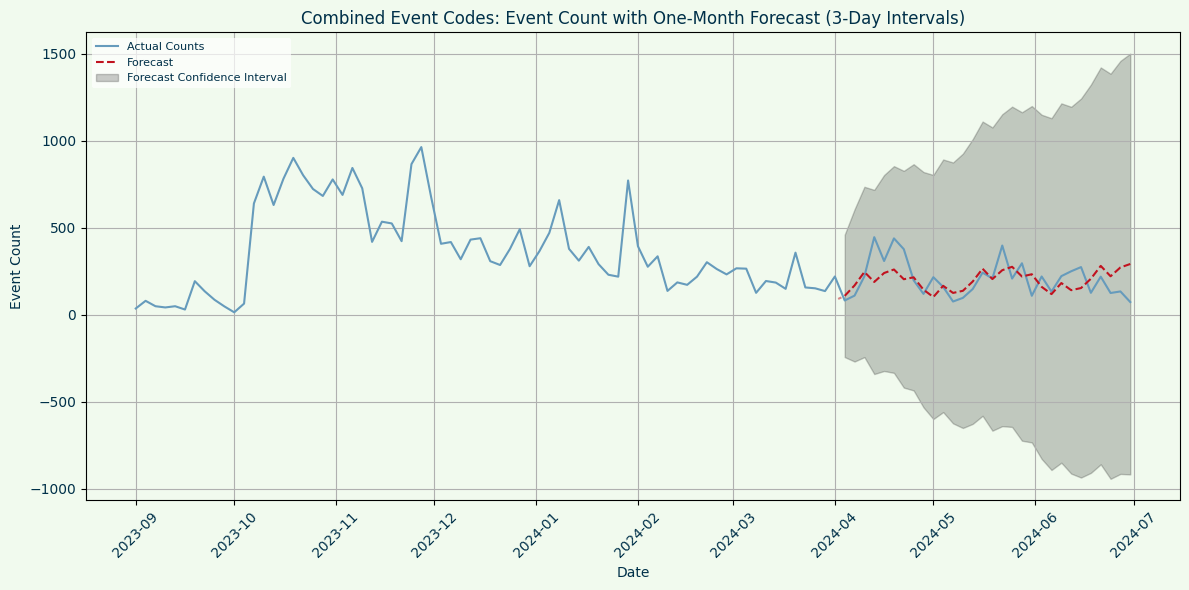

In [0]:
# Function to check stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

# Event codes, date range
event_codes = [42, 43, 51, 193, 190]
start_date = '2023-09-01'
end_date = '2024-04-01'

# Filter based on event codes and date range
filtered_data = df3[(df3['EventCode'].isin(event_codes)) &
                    (df3['SQLDATE'] >= start_date) &
                    (df3['SQLDATE'] <= end_date)]

filtered_data['SQLDATE'] = pd.to_datetime(filtered_data['SQLDATE'])

# Aggregate data by date
daily_counts = filtered_data.groupby('SQLDATE').size().reset_index(name='count')

if daily_counts.empty:
    print("No data for the specified event codes in the specified date range.")
else:
    # Aggregate counts in 3-day intervals
    daily_counts.set_index('SQLDATE', inplace=True)
    interval_counts = daily_counts['count'].resample('3D').sum().reset_index()

    # Check stationarity
    print("Combined Event Codes:")
    check_stationarity(interval_counts['count'])

    # Training data
    train = interval_counts.set_index('SQLDATE')

    # Fit SARIMAX model
    model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    results = model.fit()

    # Forecast
    future_steps = 30  # Projecting for 10 intervals into the future (each interval is 3 days)
    forecast = results.get_forecast(steps=future_steps)
    forecast_ci = forecast.conf_int()

    # Creating future dates for the forecast starting right after the last actual date
    future_dates = pd.date_range(start=train.index[-1] + timedelta(days=3), periods=future_steps, freq='3D')

    # Extract the forecasted mean
    forecast_mean = forecast.predicted_mean
    forecast_mean.index = future_dates

    # Interpolate to avoid the gap
    last_actual = train.iloc[-1]
    interpolated = pd.DataFrame({'count': np.linspace(last_actual['count'], forecast_mean.iloc[0], 4)[1:-1]}, 
                                index=pd.date_range(start=train.index[-1] + timedelta(days=1), periods=2, freq='1D'))

    # Combine actual data, interpolated points, and forecasted data
    combined_forecast = pd.concat([train, interpolated, forecast_mean], axis=0)

    # Actual data until 31 Dec 2023
    actual_data = df3[(df3['EventCode'].isin(event_codes)) & 
                      (df3['SQLDATE'] >= start_date) & 
                      (df3['SQLDATE'] <= '2024-06-30')]

    actual_data['SQLDATE'] = pd.to_datetime(actual_data['SQLDATE'])
    actual_daily_counts = actual_data.groupby('SQLDATE').size().reset_index(name='count')
    actual_daily_counts.set_index('SQLDATE', inplace=True)
    actual_interval_counts = actual_daily_counts['count'].resample('3D').sum().reset_index()

    # Plot the actual data until 31 Dec 2023
    plt.figure(figsize=(12, 6))
    plt.plot(actual_interval_counts['SQLDATE'], actual_interval_counts['count'], color='#669BBC', label='Actual Counts')
    plt.plot(forecast_mean.index, forecast_mean, linestyle='--', color='#C1121F', label='Forecast') # forecast
    plt.plot(interpolated.index, interpolated['count'], linestyle='--', color='#C1121F', alpha=0.5) # interpolation
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.2, label='Forecast Confidence Interval') # confidence interval

    plt.xlabel('Date', color='#003049')
    plt.ylabel('Event Count', color='#003049')
    plt.title('Combined Event Codes: Event Count with One-Month Forecast (3-Day Intervals)', color='#003049')
    plt.legend(facecolor='white', framealpha=0.7, edgecolor='none', fontsize=8, loc='upper left', labelcolor='#003049')
    plt.grid(True)
    plt.xticks(rotation=45, color='#003049')
    plt.yticks(color='#003049')
    plt.gca().set_facecolor('#F1FAEE') # background color
    plt.gcf().set_facecolor('#F1FAEE') # background color
    plt.tight_layout()

    # Display the plot
    plt.show()


In [0]:
top_5_actors = ['GOV', 'REB', 'MIL', 'IGO', 'CVL']
labels = ['Government', 'Rebel', 'Military', 'Intergovt Org', 'Civilian']

# filter df for top 5 actors
filtered_df = df5[df5['Actor1Type1Code'].isin(top_5_actors)]

# count each EventBaseCode for each Actor
event_counts = filtered_df.groupby(['Actor1Type1Code', 'EventBaseCode']).size().unstack(fill_value=0)

# Top 3 EventBaseCode for each actor
top_event_codes = event_counts.apply(lambda x: x.nlargest(3).index.tolist(), axis=1)

# identify top 5 eventbasecodes for each actor
top_event_codes_per_actor = {}
for actor in event_counts.index:
    # sort event counts for the actor in descending order
    top_event_codes = event_counts.loc[actor].sort_values(ascending=False).head(5)
    # store the top 5 EventBaseCodes and their counts for each actor
    top_event_codes_per_actor[actor] = top_event_codes

# Convert the dictionary to a df for better visualization
top_event_codes_df = pd.DataFrame(top_event_codes_per_actor)

data = []
for actor, codes in top_event_codes_per_actor.items():
    for event_code, count in codes.items():
        data.append({'Actor': actor, 'EventBaseCode': event_code, 'Count': count})

df = pd.DataFrame(data)

# Create a bar plot using seaborn
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Plotting
bar_plot = sns.barplot(x='Actor', y='Count', hue='EventBaseCode', data=df, palette='Set1')

# Customize the plot
plt.title('Top EventBaseCodes for Each Actor')
plt.xlabel('Actor')
plt.ylabel('Event Count')
plt.legend(title='EventBaseCode')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()
